In [1]:
COLORS = {
    'primary':   '#2E5C8A',   # أزرق هادي
    'secondary': '#5B6273',   # رمادي
    'good':      '#1F7A4D',   # أخضر
    'bad':       '#B23A48',   # أحمر
    'accent':    '#D4A574',   # كهرماني
    'neutral':   '#8B95A8',   # رمادي فاتح
}

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
import subprocess
import json

plt.savefig('lecico_currency_illusion.png', dpi=180, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Lecico Egypt — Financial Analysis Journey
### تحليل مالي شامل لشركة Multi-Geography

---

**الشركة:**  
Lecico Egypt S.A.E. (EGX: LCSW)

**القطاع:**  
السيراميك والأدوات الصحية

**الفترة المغطاة:**  
FY 2021 – FY 2025 + توقع Q2 2026

**التحدي التحليلي الرئيسي:**  
تعمل الشركة في ثلاث دول (UK, Egypt, Lebanon) بأسعار صرف مختلفة، إلى جانب وجود حالة Hyperinflation في لبنان.

---

## لماذا تستحق الشركة التحليل؟

ليسيكو ليست كياناً واحداً، بل **ثلاثة أنشطة في كيان واحد**. الإيرادات المُعلنة بالجنيه المصري تخلط بين:
- نشاط مصري حقيقي يتأثر بالتضخم المحلي
- نشاط لبناني في بيئة hyperinflation
- نشاط بريطاني بالاسترليني يتأثر بحركة سعر الصرف

السؤال الجوهري الذي يدور حوله هذا التحليل:

> **هل النمو المُعلن بنسبة +195% خلال خمس سنوات نمو تشغيلي حقيقي، أم مجرد انعكاس للتعويم والتضخم؟**

يستعرض هذا التقرير سبع مراحل تحليلية متتالية، تنتهي بنموذج تنبؤ بأرباح Q2 2026 وفق ثلاثة سيناريوهات.

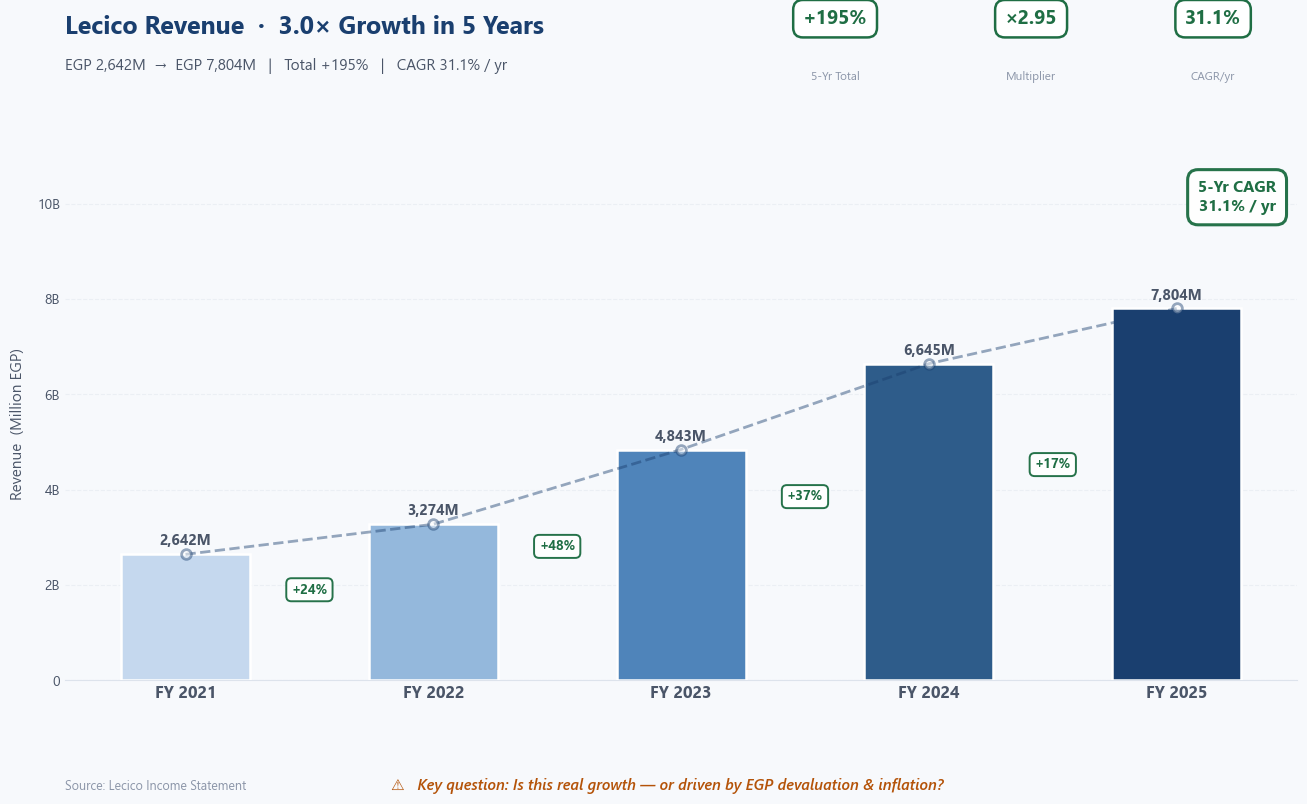


Revenue Summary:
  FY 2021:  2,642.2 M EGP
  FY 2022:  3,273.8 M EGP  YoY +23.9%
  FY 2023:  4,842.9 M EGP  YoY +47.9%
  FY 2024:  6,644.7 M EGP  YoY +37.2%
  FY 2025:  7,803.7 M EGP  YoY +17.4%

  Total Growth : +195.3%
  CAGR         :  31.1% / year
  Multiplier   :  ×2.95


In [3]:
# ── 1. DATA ───────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

df       = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
fy_cols  = [6, 11, 16, 21, 26]
years    = [2021, 2022, 2023, 2024, 2025]
revenues = [df.iloc[5, c] / 1_000_000 for c in fy_cols]   # million EGP

revenue_by_year = dict(zip(years, revenues))   # kept for downstream cells

yoy       = [None] + [(revenues[i]/revenues[i-1] - 1)*100 for i in range(1, 5)]
total_pct = (revenues[-1]/revenues[0] - 1) * 100
mult      = revenues[-1] / revenues[0]
cagr      = (mult ** (1/4) - 1) * 100

# ── 2. UNIFIED PALETTE (used by all cells below) ──────────────────────────────
COLORS = {
    'primary':   '#1A3F6F',
    'secondary': '#4A5568',
    'accent':    '#1F6E44',
    'good':      '#1F6E44',
    'bad':       '#B23A48',
    'neutral':   '#8B95A8',
    'amber':     '#B45309',
    'bg':        '#F7F9FC',
    'grid':      '#DDE3EC',
}
BAR_PALETTE = ['#C5D8EE', '#94B8DC', '#4F84BA', '#2E5C8A', '#1A3F6F']

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── 3. FIGURE ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9), facecolor=COLORS['bg'])
ax  = fig.add_axes([0.07, 0.20, 0.88, 0.57])
ax.set_facecolor(COLORS['bg'])

x, W = np.arange(len(years)), 0.52

# ── Bars ──────────────────────────────────────────────────────────────────────
bars = ax.bar(x, revenues, width=W, color=BAR_PALETTE,
              edgecolor='white', linewidth=1.8, zorder=3)

# ── Trend dotted line ─────────────────────────────────────────────────────────
ax.plot(x, revenues, color=COLORS['primary'], lw=2, alpha=0.45,
        linestyle='--', marker='o', markersize=7, zorder=4,
        markerfacecolor='white', markeredgecolor=COLORS['primary'], markeredgewidth=2)

# ── Value labels above each bar ───────────────────────────────────────────────
for bar, val in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + max(revenues) * 0.014,
            f'{val:,.0f}M',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color=COLORS['secondary'], zorder=5)

# ── YoY growth badges between bars ───────────────────────────────────────────
for i in range(1, 5):
    badge_y = max(revenues[i-1], revenues[i]) * 0.58
    ax.text((x[i-1] + x[i]) / 2, badge_y,
            f'+{yoy[i]:.0f}%',
            ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=COLORS['accent'],
            bbox=dict(boxstyle='round,pad=0.38', facecolor='white',
                      edgecolor=COLORS['accent'], linewidth=1.4, alpha=0.97),
            zorder=6)

# ── CAGR callout box ──────────────────────────────────────────────────────────
ax.text(0.983, 0.975,
        f'5-Yr CAGR\n{cagr:.1f}% / yr',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11.5, fontweight='bold', color=COLORS['accent'],
        bbox=dict(boxstyle='round,pad=0.65', facecolor='white',
                  edgecolor=COLORS['accent'], linewidth=2.2, alpha=0.97),
        zorder=7)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([f'FY {y}' for y in years],
                   fontsize=12, fontweight='bold', color=COLORS['secondary'])
ax.set_ylabel('Revenue  (Million EGP)', fontsize=11, color=COLORS['secondary'], labelpad=8)
ax.set_ylim(0, max(revenues) * 1.38)
ax.grid(axis='y', alpha=0.45, linestyle='--', color=COLORS['grid'], zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='both', length=0)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color(COLORS['grid'])
yticks = np.arange(0, max(revenues) * 1.4, 2000)
ax.set_yticks(yticks)
ax.set_yticklabels(
    [f'{int(v/1000)}B' if v >= 1000 else '0' for v in yticks],
    color=COLORS['secondary'], fontsize=10
)

# ── Title block ───────────────────────────────────────────────────────────────
fig.text(0.07, 0.940,
         f'Lecico Revenue  ·  {mult:.1f}× Growth in 5 Years',
         fontsize=18, fontweight='bold', color=COLORS['primary'], va='top')
fig.text(0.07, 0.892,
         f'EGP {revenues[0]:,.0f}M  →  EGP {revenues[-1]:,.0f}M'
         f'   |   Total +{total_pct:.0f}%   |   CAGR {cagr:.1f}% / yr',
         fontsize=11, color=COLORS['secondary'], va='top')

# ── KPI chips top-right ───────────────────────────────────────────────────────
kpis = [(f'+{total_pct:.0f}%', '5-Yr Total'), (f'×{mult:.2f}', 'Multiplier'), (f'{cagr:.1f}%', 'CAGR/yr')]
for (val_txt, lbl), kx in zip(kpis, [0.62, 0.76, 0.89]):
    fig.text(kx, 0.945, val_txt, ha='center', va='top',
             fontsize=14, fontweight='bold', color=COLORS['accent'],
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                       edgecolor=COLORS['accent'], linewidth=1.8))
    fig.text(kx, 0.877, lbl, ha='center', va='top',
             fontsize=8.5, color=COLORS['neutral'])

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.078,
         '⚠   Key question: Is this real growth — or driven by EGP devaluation & inflation?',
         ha='center', fontsize=11, style='italic',
         color=COLORS['amber'], fontweight='semibold')
fig.text(0.07, 0.078, 'Source: Lecico Income Statement',
         ha='left', fontsize=9, color=COLORS['neutral'])

plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print("\nRevenue Summary:")
for y, r, g in zip(years, revenues, yoy):
    g_str = f'  YoY +{g:.1f}%' if g else ''
    print(f"  FY {y}:  {r:7,.1f} M EGP{g_str}")
print(f"\n  Total Growth : +{total_pct:.1f}%")
print(f"  CAGR         :  {cagr:.1f}% / year")
print(f"  Multiplier   :  ×{mult:.2f}")

In [4]:
possible_paths = [
    'C:/LCSW/Lecico_Dashboard_v3.xlsx',
    'C:/Users/dawod/Downloads/Lecico_Dashboard_v3.xlsx',
    'Lecico_Dashboard_v3.xlsx',  # نفس فولدر النوتبوك
]

FILE_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        FILE_PATH = path
        break

if FILE_PATH is None:
    raise FileNotFoundError("الفايل مش موجود في أي مكان من الأماكن المتوقعة")

print(f"✓ تم العثور على الفايل في: {FILE_PATH}")

# نقرا كل الشيتات
income_stmt = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
balance_sheet = pd.read_excel(FILE_PATH, sheet_name='Balance Sheet', header=None)
cash_flow = pd.read_excel(FILE_PATH, sheet_name='Cash Flow', header=None)
ratios = pd.read_excel(FILE_PATH, sheet_name='Ratio Analysis', header=None)
events = pd.read_excel(FILE_PATH, sheet_name='Events Log', header=None)

print(f"✓ تم تحميل البيانات من: {FILE_PATH}")
print(f"  • Income Statement: {income_stmt.shape}")
print(f"  • Balance Sheet:    {balance_sheet.shape}")
print(f"  • Cash Flow:        {cash_flow.shape}")
print(f"  • Ratios:           {ratios.shape}")
print(f"  • Events Log:       {events.shape}")

✓ تم العثور على الفايل في: C:/LCSW/Lecico_Dashboard_v3.xlsx
✓ تم تحميل البيانات من: C:/LCSW/Lecico_Dashboard_v3.xlsx
  • Income Statement: (29, 28)
  • Balance Sheet:    (47, 22)
  • Cash Flow:        (61, 28)
  • Ratios:           (135, 28)
  • Events Log:       (11, 8)


In [5]:
# 1. تحميل الإكسيل
FILE_PATH = 'C:/LCSW/Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

income_stmt   = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
balance_sheet = pd.read_excel(FILE_PATH, sheet_name='Balance Sheet',    header=None)

# 2. مواقع أعمدة الـ FY (مختلفة بين الـ sheets!)
FY_COLS_IS = [6, 11, 16, 21, 26]   # Income Statement
FY_COLS_BS = [5, 9, 13, 17, 21]    # Balance Sheet
YEARS      = [2021, 2022, 2023, 2024, 2025]

# 3. أرقام الصفوف اللي محتاجينها (مأخوذة بعد فحص الإكسيل)
IS_ROWS = {
    'Revenue':      5,    # Net Revenue / Sales
    'COGS':         6,    # Cost of Sales
    'Gross_Profit': 7,    # GROSS PROFIT
    'EBIT':         15,   # EBIT (Operating Profit)
    'Net_Profit':   23,   # NET PROFIT FOR THE PERIOD
}
BS_ROWS = {
    'Total_Assets': 18,   # TOTAL ASSETS
    'Total_Equity': 28,   # TOTAL EQUITY
    'Total_Debt':   44,   # TOTAL LIABILITIES
}

# 4. دالة بسيطة: تقرأ صف على أعمدة السنوات وتحوّل لمليون
def read_row(df, row_idx, fy_cols):
    return [round(float(df.iloc[row_idx, c]) / 1_000_000, 1) for c in fy_cols]

# 5. بناء الجدول
data = {'Year': YEARS}
for name, row in IS_ROWS.items():
    data[name] = read_row(income_stmt, row, FY_COLS_IS)
for name, row in BS_ROWS.items():
    data[name] = read_row(balance_sheet, row, FY_COLS_BS)

annual = pd.DataFrame(data).set_index('Year')
print("✅ تم بناء الجدول!")
annual

✅ تم بناء الجدول!


,Revenue,COGS,Gross_Profit,EBIT,Net_Profit,Total_Assets,Total_Equity,Total_Debt
Year,,,,,,,,
2021,2642.2,-2158.9,483.3,49.9,-23.3,3424.9,1543.1,1881.9
2022,3273.8,-2675.2,598.6,-31.3,12.7,4695.5,1900.4,2795.1
2023,4842.9,-3208.8,1634.1,941.1,472.9,5455.4,2261.8,3193.6
2024,6644.7,-4769.5,1875.2,1151.0,919.4,7747.4,3856.6,3890.8
2025,7803.7,-6018.8,1784.9,742.6,259.3,8537.0,4105.8,4431.2


---

# المرحلة 1: فهم الـ Business

## نقطة البداية

قبل تحليل أي رقم، من الضروري الإجابة عن السؤال الأساسي: **ما طبيعة نشاط هذه الشركة؟**

تشخيص الشركة دون فهم نموذج عملها أشبه بقياس الضغط والسكر لمريض قبل معرفة تاريخه المرضي. الأرقام معزولة عن السياق تفقد معناها التحليلي.

تجيب هذه المرحلة عن أربعة أسئلة أساسية:

1. ماذا تُنتج الشركة وتبيع؟
2. مَن يشتري منتجاتها؟
3. كيف تُحقق إيراداتها (الـ Business Model)؟
4. ما الأصول الأساسية التي تمتلكها؟

## السؤال 1: ما الذي تُنتجه ليسيكو وتبيعه؟

وفقاً للتقارير السنوية للشركة، تُنتج ليسيكو **ثلاثة خطوط منتجات أساسية**:

| # | المنتج | باللغة العربية | الوصف |
|---|---|---|---|
| 1 | **Sanitary Ware** | الأدوات الصحية | كراسي حمام، أحواض، بيديهات |
| 2 | **Tiles** | السيراميك (بلاط) | سيراميك أرضيات وحوائط |
| 3 | **Brassware** | الحنفيات والمخلطات | حنفيات نحاسية ومخلطات |

يتميّز كل خط منتجات بـ:
- مصنع منفصل
- هامش ربح مختلف
- سوق مستهدف محدد

In [6]:

SOURCES = {
    'Consolidated P&L (2021-2025)': {
        'source': 'Lecico_Dashboard_v3.xlsx (الفايل اللي شغالين عليه)',
        'origin': 'مأخوذ من القوائم المالية المنشورة في EGX و موقع الشركة',
        'available': 'كل الـ quarters + الـ FYs'
    },
    'Product Mix (Sanitary / Tiles / Brassware)': {
        'source': 'تقرير الشركة المالي السنوي - Note 5 (Segment Reporting)',
        'origin': 'https://www.lecicoegypt.com/en/support/financial-statements',
        'available': 'FY 2024 و FY 2025 بس (الأقدم بطريقة عرض مختلفة)'
    },
    'Geographic Segments (Egypt/Lebanon/Others)': {
        'source': 'تقرير الشركة السنوي - Note 4',
        'origin': 'Annual Reports 2023, 2024',
        'available': 'FY 2023 و FY 2024 بس'
    },
    'Volumes & Prices (per product)': {
        'source': 'Annual Report - Sanitary ware analysis tables',
        'origin': 'تقارير 2022 و 2024 السنوية',
        'available': 'FY 2020 إلى FY 2024 (2025 لسه ماطلعش)'
    },
}

# طباعة جدول المصادر
print("=" * 70)
print("مصادر البيانات في التحليل")
print("=" * 70)
for data_type, info in SOURCES.items():
    print(f"\n📄 {data_type}")
    for key, val in info.items():
        print(f"   {key}: {val}")

مصادر البيانات في التحليل

📄 Consolidated P&L (2021-2025)
   source: Lecico_Dashboard_v3.xlsx (الفايل اللي شغالين عليه)
   origin: مأخوذ من القوائم المالية المنشورة في EGX و موقع الشركة
   available: كل الـ quarters + الـ FYs

📄 Product Mix (Sanitary / Tiles / Brassware)
   source: تقرير الشركة المالي السنوي - Note 5 (Segment Reporting)
   origin: https://www.lecicoegypt.com/en/support/financial-statements
   available: FY 2024 و FY 2025 بس (الأقدم بطريقة عرض مختلفة)

📄 Geographic Segments (Egypt/Lebanon/Others)
   source: تقرير الشركة السنوي - Note 4
   origin: Annual Reports 2023, 2024
   available: FY 2023 و FY 2024 بس

📄 Volumes & Prices (per product)
   source: Annual Report - Sanitary ware analysis tables
   origin: تقارير 2022 و 2024 السنوية
   available: FY 2020 إلى FY 2024 (2025 لسه ماطلعش)


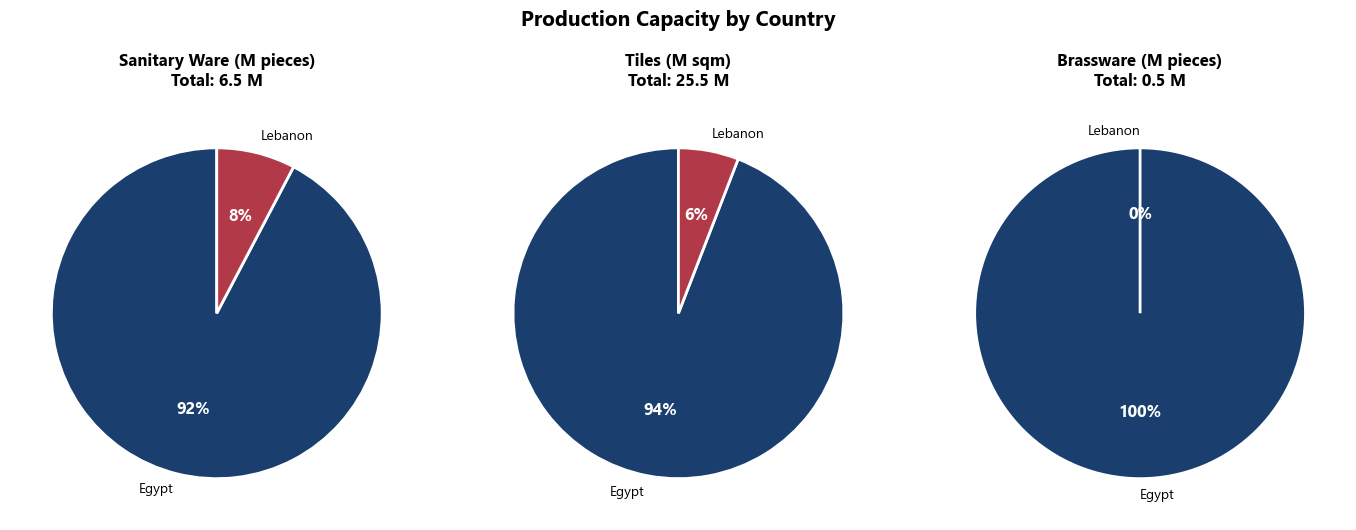


📊 الخلاصة:
   • مصر = 92%+ من كل الطاقة الإنتاجية
   • لبنان = هامش صغير (8% Sanitary, 6% Tiles)
   • Brassware في مصر فقط

   ⚠️  معنى ده: التكاليف الإنتاجية بالـ EGP أساساً
       لكن الإيرادات بعملات متعددة → margin sensitivity to FX


In [7]:
# بيانات الطاقة الإنتاجية (نطبّعها كميا للنسبة)
facilities = {
    'Sanitary Ware (M pieces)': {
        'Egypt - Khorshid': 6.0,
        'Lebanon - Khaldé': 0.5,
    },
    'Tiles (M sqm)': {
        'Egypt - Alexandria': 24.0,
        'Lebanon - Mount Lebanon': 1.5,
    },
    'Brassware (M pieces)': {
        'Egypt - Cairo': 0.5,
    },
}

# نحسب نسبة مصر vs لبنان لكل منتج
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (product, locs) in zip(axes, facilities.items()):
    countries = ['Egypt', 'Lebanon']
    values = [
        sum(v for k, v in locs.items() if 'Egypt' in k),
        sum(v for k, v in locs.items() if 'Lebanon' in k)
    ]
    colors = [COLORS['primary'], COLORS['bad']]
    
    wedges, texts, autotexts = ax.pie(
        values, labels=countries, autopct='%1.0f%%',
        colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    total = sum(values)
    ax.set_title(f'{product}\nTotal: {total} M', 
                 fontsize=12, fontweight='bold', pad=15)

plt.suptitle('Production Capacity by Country', 
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n📊 الخلاصة:")
print("   • مصر = 92%+ من كل الطاقة الإنتاجية")
print("   • لبنان = هامش صغير (8% Sanitary, 6% Tiles)")
print("   • Brassware في مصر فقط")
print("\n   ⚠️  معنى ده: التكاليف الإنتاجية بالـ EGP أساساً")
print("       لكن الإيرادات بعملات متعددة → margin sensitivity to FX")

**يستعرض القسم التالي وزن كل منتج في إجمالي إيرادات الشركة.**

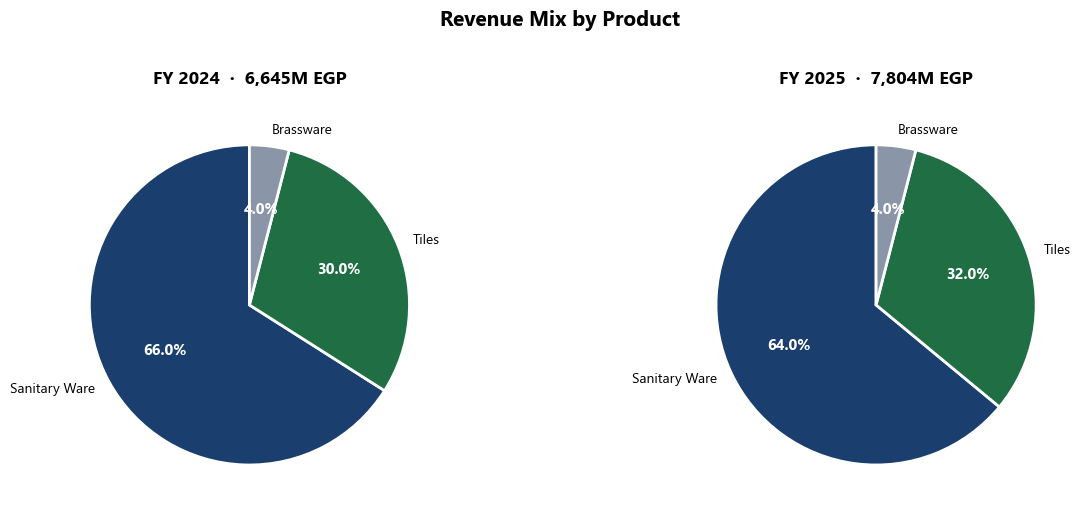

In [8]:
# Product mix data — from Annual Report segmental notes
product_mix = pd.DataFrame({
    'Product': ['Sanitary Ware', 'Tiles', 'Brassware'],
    'FY 2024 (M EGP)': [4_385.5, 1_993.4, 265.8],   # ~66%, 30%, 4%
    'FY 2025 (M EGP)': [4_994.4, 2_497.2, 312.1],   # ~64%, 32%, 4%
})

# === رسمة: مساهمة كل منتج في الإيرادات ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_products = [COLORS['primary'], COLORS['accent'], COLORS['neutral']]
years = ['FY 2024', 'FY 2025']
data_cols = ['FY 2024 (M EGP)', 'FY 2025 (M EGP)']

for ax, year, col in zip(axes, years, data_cols):
    values = product_mix[col].values
    labels = product_mix['Product'].values
    
    wedges, texts, autotexts = ax.pie(
        values, labels=labels, autopct='%1.1f%%',
        colors=colors_products, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    
    ax.set_title(f'{year}  ·  {values.sum():,.0f}M EGP',
                 fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Revenue Mix by Product', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### الملاحظات الرئيسية على التوزيع

تكشف الرسمة عن النقاط التالية:
- **Sanitary Ware = ~64% من الإيرادات** — يُمثّل المنتج الرئيسي للشركة، وأي تحليل لليسيكو يدور حوله بصورة جوهرية.
- **Tiles = ~32%** — منتج ثانوي مهم، شهد نمواً في الوزن النسبي (من 30% في 2024 إلى 32% في 2025).
- **Brassware = ~4%** — الأصغر حجماً لكنه يُحقق أعلى هامش ربح.

**الخلاصة:** التركيز التحليلي على Sanitary Ware يُغطي ثلثي النشاط، وهي نقطة جوهرية تُحدد محور تحليل الإيرادات في المراحل التالية.

## السؤال 2: مَن يشتري من ليسيكو؟

ينقسم العملاء إلى نوعين:
1. **عملاء جغرافياً** (وفقاً للدولة)
2. **عملاء نوعياً** (تجار، شركات، حكومات، أفراد)

### العملاء الجغرافيون

وفقاً لـ Business Split الوارد في التقارير السنوية، تتوزع الإيرادات كالتالي:

| الدولة/المنطقة | FY 2024 (%) |
|---|---|
| مصر (السوق المحلي) | 38.8% |
| المملكة المتحدة | 22.4% |
| باقي أوروبا | 11.2% |
| OEM (Private Label) | 15.9% |
| الشرق الأوسط وشمال أفريقيا | 3.9% |
| ألمانيا | 1.9% |
| لبنان | 1.6% |
| أخرى | 4.4% |

**الملاحظة الجوهرية:** ~60% من الإيرادات تأتي من خارج مصر، ما يعني تعرّض الشركة لمخاطر سعر الصرف بشكل مرتفع.

### التوزيع الجغرافي للعملاء

يُحدد التوزيع الجغرافي للإيرادات حجم التعرض الفعلي للعملات الأجنبية (FX Exposure).

**نقطة جوهرية:** عندما تُمثّل المملكة المتحدة 22% من المبيعات، فإن 22% من الإيرادات تُحقَّق بالاسترليني وتُترجم إلى الجنيه المصري في القوائم المالية. أي تحرّك في GBP/EGP ينعكس مباشرة على الإيراد المُعلن.

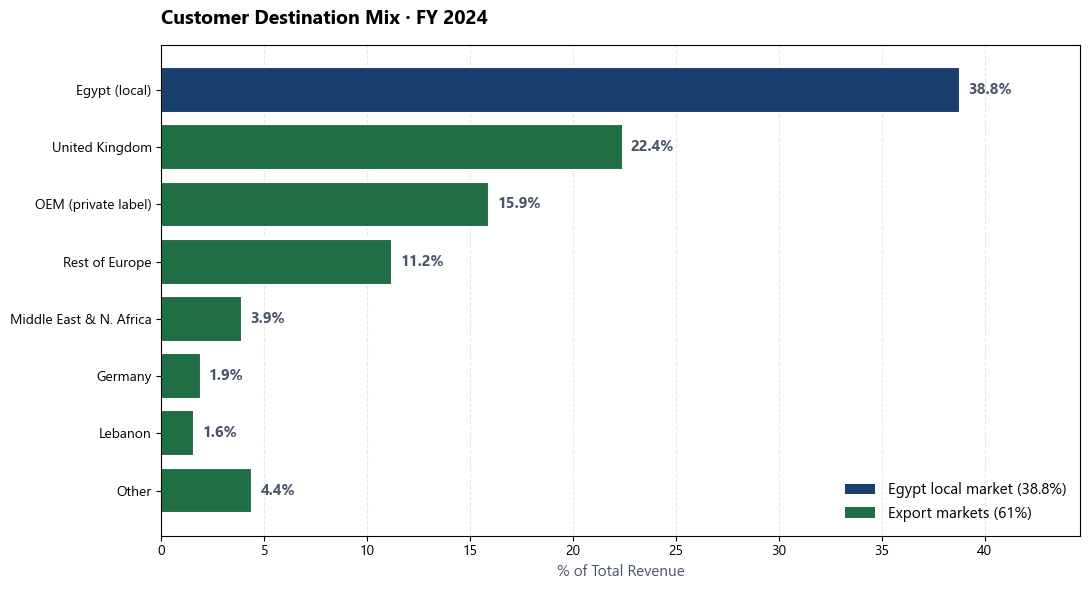


📊 التوزيع:
   • مبيعات محلية في مصر:  38.8%
   • مبيعات تصدير:          61%

⚠️  الـ Mismatch الحرج:
   • 92% من التكاليف بالـ EGP
   • 60%+ من الإيرادات بعملات أجنبية (GBP, EUR, USD)

💡 معنى ده:
   • أي تعويم للجنيه = الإيرادات بالـ EGP تقفز تلقائياً
   • لكن التكاليف بالـ EGP تطلع برضه (تضخم محلي)
   • الـ net margin = صراع بين الاتنين


In [9]:
# بيانات Customer Destination من FY 2024 (من شيت 08)
customer_destinations = {
    'Egypt (local)':            38.8,
    'United Kingdom':           22.4,
    'OEM (private label)':      15.9,
    'Rest of Europe':           11.2,
    'Middle East & N. Africa':   3.9,
    'Germany':                   1.9,
    'Lebanon':                   1.6,
    'Other':                     4.4,
}

# تصنيف: محلي vs تصدير
local_share = customer_destinations['Egypt (local)']
export_share = 100 - local_share

# رسمة horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 6))

countries = list(customer_destinations.keys())
shares = list(customer_destinations.values())

# لون مختلف لمصر vs باقي الدول
colors_list = [COLORS['primary'] if c == 'Egypt (local)' else COLORS['accent'] 
               for c in countries]

bars = ax.barh(countries, shares, color=colors_list, 
               edgecolor='white', linewidth=1.5)

# نضيف النسبة على كل بار
for bar, val in zip(bars, shares):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', ha='left',
            fontsize=11, fontweight='bold', color=COLORS['secondary'])

ax.set_xlabel('% of Total Revenue', fontsize=11, color=COLORS['secondary'])
ax.set_title('Customer Destination Mix · FY 2024',
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.invert_yaxis()  # الأكبر فوق
ax.set_xlim(0, max(shares) * 1.15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=COLORS['primary'], label=f'Egypt local market ({local_share}%)'),
    Patch(facecolor=COLORS['accent'], label=f'Export markets ({export_share:.0f}%)'),
], loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

# الخلاصة
print(f"\n📊 التوزيع:")
print(f"   • مبيعات محلية في مصر:  {local_share}%")
print(f"   • مبيعات تصدير:          {export_share:.0f}%")
print(f"\n⚠️  الـ Mismatch الحرج:")
print(f"   • 92% من التكاليف بالـ EGP")
print(f"   • 60%+ من الإيرادات بعملات أجنبية (GBP, EUR, USD)")
print(f"\n💡 معنى ده:")
print(f"   • أي تعويم للجنيه = الإيرادات بالـ EGP تقفز تلقائياً")
print(f"   • لكن التكاليف بالـ EGP تطلع برضه (تضخم محلي)")
print(f"   • الـ net margin = صراع بين الاتنين")

## النوع الثاني من العملاء: العملاء النوعيون

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


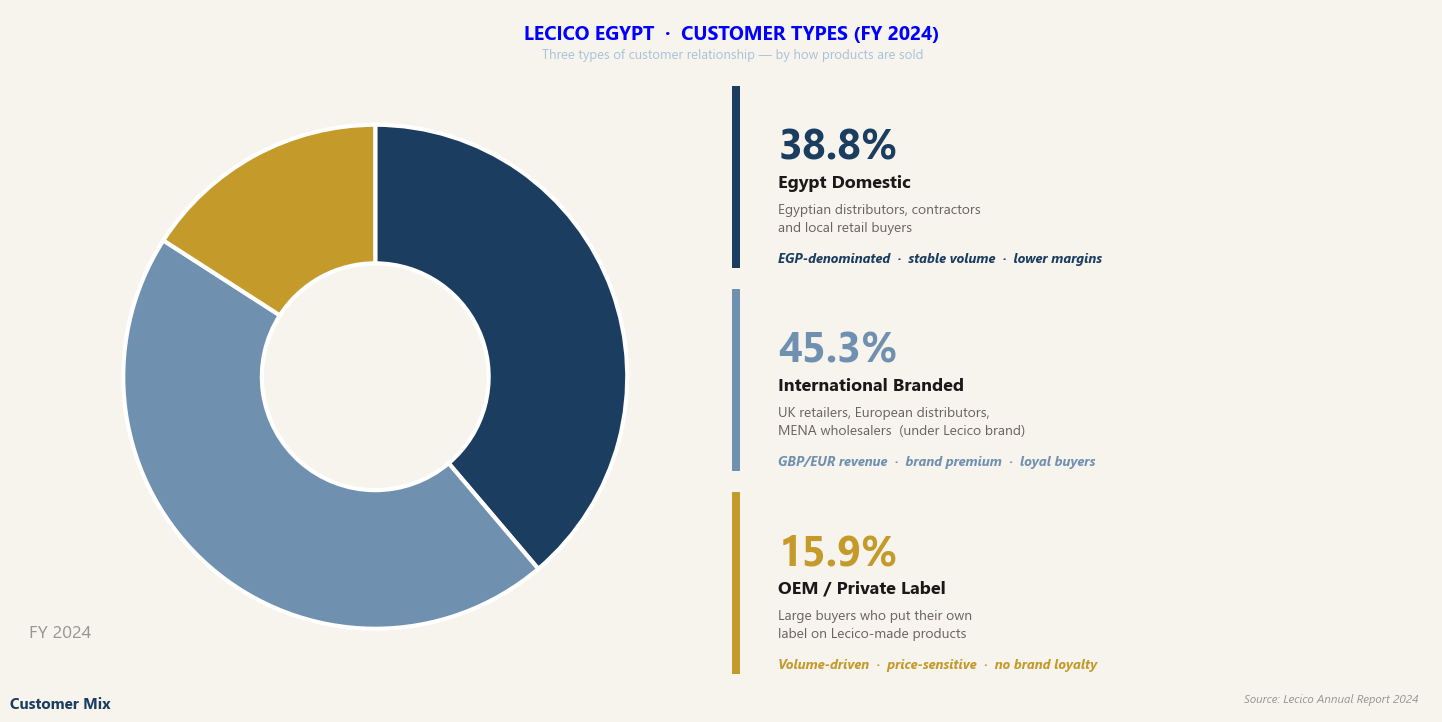

In [10]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK  = '#1A1818'
SOFT = '#686260'
MUTED= '#9A9590'
BG   = '#F7F4EE'
CARD = '#FDFAF5'
NAVY = '#1B3D5F'
GOLD = '#C49A2A'
SKY  = '#7090B0'
RULE = '#E2DDD4'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── DATA ──────────────────────────────────────────────────────────────────────
# OEM = 15.9%  |  Egypt Domestic = 38.8%
# International Branded = UK+Europe+MENA+Others = 45.3%
sizes  = [38.8, 45.3, 15.9]
colors = [NAVY, SKY, GOLD]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7), facecolor=BG)

# Header
ax_hdr = fig.add_axes([0, 0.92, 1, 0.08])
ax_hdr.set_facecolor(NAVY); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.55, 'LECICO EGYPT  ·  CUSTOMER TYPES (FY 2024)',
            ha='center', va='center', fontsize=14, color='blue',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18, 'Three types of customer relationship — by how products are sold',
            ha='center', va='center', fontsize=9.5, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# ── DONUT CHART ───────────────────────────────────────────────────────────────
ax_d = fig.add_axes([0.02, 0.05, 0.45, 0.85])
ax_d.set_facecolor(BG); ax_d.axis('equal')

wedges, _ = ax_d.pie(
    sizes, colors=colors, startangle=90, counterclock=False,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 3}
)

# Center label
ax_d.text(0, 0.07, 'FY 2024', ha='center', va='center',
          fontsize=13, color=MUTED, transform=ax_d.transAxes)
ax_d.text(0, -0.05, 'Customer Mix', ha='center', va='center',
          fontsize=11, color=NAVY, fontweight='bold', transform=ax_d.transAxes)

# ── 3 CARDS ───────────────────────────────────────────────────────────────────
type_data = [
    {
        'pct': '38.8%', 'type': 'Egypt Domestic',
        'color': NAVY,
        'detail': 'Egyptian distributors, contractors\nand local retail buyers',
        'key': 'EGP-denominated  ·  stable volume  ·  lower margins',
    },
    {
        'pct': '45.3%', 'type': 'International Branded',
        'color': SKY,
        'detail': 'UK retailers, European distributors,\nMENA wholesalers  (under Lecico brand)',
        'key': 'GBP/EUR revenue  ·  brand premium  ·  loyal buyers',
    },
    {
        'pct': '15.9%', 'type': 'OEM / Private Label',
        'color': GOLD,
        'detail': 'Large buyers who put their own\nlabel on Lecico-made products',
        'key': 'Volume-driven  ·  price-sensitive  ·  no brand loyalty',
    },
]

y_positions = [0.63, 0.34, 0.05]

for j, td in enumerate(type_data):
    ax = fig.add_axes([0.50, y_positions[j], 0.47, 0.26])
    ax.set_facecolor(CARD); ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # Left color strip
    ax.add_patch(patches.Rectangle(
        (0, 0), 0.012, 1,
        facecolor=td['color'], edgecolor='none'))

    # Percentage
    ax.text(0.07, 0.78, td['pct'],
            fontsize=30, fontweight='bold', color=td['color'],
            va='top', transform=ax.transAxes)

    # Type name
    ax.text(0.07, 0.47, td['type'],
            fontsize=13, fontweight='bold', color=INK,
            va='center', transform=ax.transAxes)

    # Detail
    ax.text(0.07, 0.27, td['detail'],
            fontsize=10, color=SOFT, va='center',
            transform=ax.transAxes, linespacing=1.5)

    # Key insight
    ax.add_patch(patches.Rectangle(
        (0.05, 0.10), 0.90, 0.002,
        facecolor=RULE, edgecolor='none'))
    ax.text(0.07, 0.05, td['key'],
            fontsize=9.5, color=td['color'], fontweight='bold',
            va='center', transform=ax.transAxes, style='italic')

# Source
fig.text(0.99, 0.01, 'Source: Lecico Annual Report 2024',
         ha='right', fontsize=8.5, color=MUTED, style='italic')

plt.savefig('lecico_customer_types.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()

## السؤال 3 و 4: نموذج العمل والأصول الأساسية

لإنتاج وبيع منتجات السيراميك، تحتاج الشركة إلى مجموعة من الأصول الأساسية: مصانع، أراضٍ لمصادر المواد الخام، أفران تعمل بالغاز، مخازن، وشبكة موزّعين.

يستعرض القسم التالي طبيعة الأصول الفعلية التي تمتلكها ليسيكو.

---

## المرحلة 2: Geographic & Operational Context

أوضحت المرحلة السابقة أن أكثر من **60% من الإيرادات تأتي من خارج مصر**. يطرح ذلك سؤالاً مكمّلاً:

> هل تُصدِّر الشركة منتجاتها من مصر، أم تمتلك مصانع في كل دولة من دول المبيعات؟

تحدد الإجابة طبيعة التعرّض للعملات الأجنبية:
- **مصانع في مصر + مبيعات في UK = Natural FX Hedge** (تكاليف بالجنيه، إيرادات بالاسترليني)
- **مصنع منفصل في كل دولة = تعرّض FX محدود**

تُغيّر هذه الإجابة فهم كامل التحليل التالي.

### الموقع الإنتاجي للمصانع

وفقاً لجدول الطاقة الإنتاجية في التقرير السنوي، تمتلك الشركة **خمسة مصانع** موزّعة كالتالي:

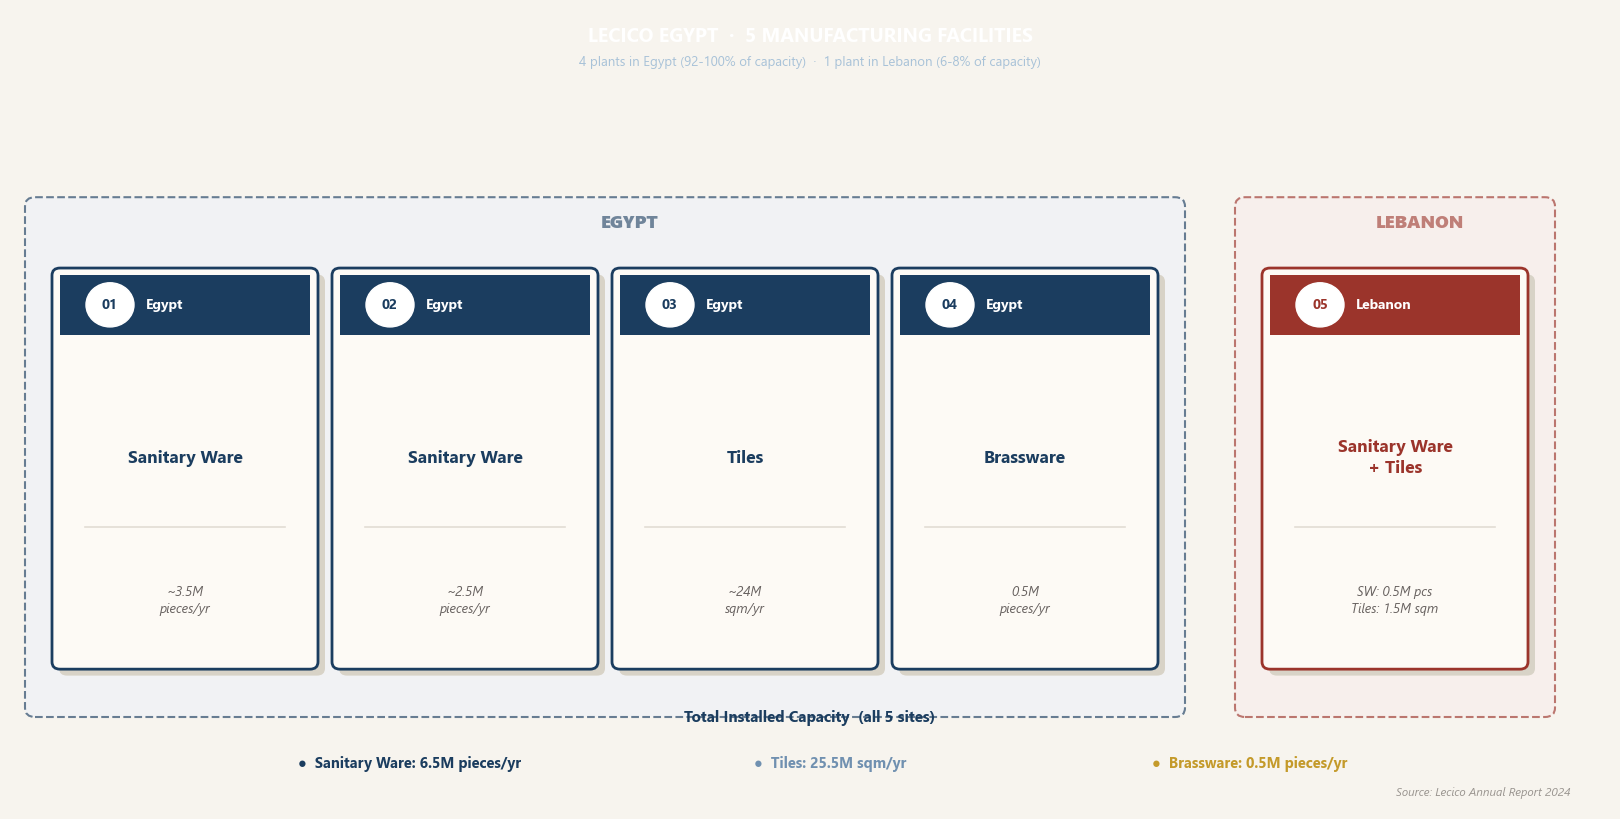

In [11]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK   = '#1A1818'
SOFT  = '#686260'
MUTED = '#9A9590'
BG    = '#F7F4EE'
CARD  = '#FDFAF5'
NAVY  = '#1B3D5F'
GOLD  = '#C49A2A'
RULE  = '#E2DDD4'
RED   = '#9B342B'
SKY   = '#7090B0'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── DATA ──────────────────────────────────────────────────────────────────────
egypt_factories = [
    {'num': '01', 'product': 'Sanitary Ware',  'note': 'Plant A', 'cap': '~3.5M\npieces/yr'},
    {'num': '02', 'product': 'Sanitary Ware',  'note': 'Plant B', 'cap': '~2.5M\npieces/yr'},
    {'num': '03', 'product': 'Tiles',           'note': 'Plant',   'cap': '~24M\nsqm/yr'},
    {'num': '04', 'product': 'Brassware',       'note': 'Plant',   'cap': '0.5M\npieces/yr'},
]
leb_factory = {
    'num': '05', 'product': 'Sanitary Ware\n+ Tiles', 'cap': 'SW: 0.5M pcs\nTiles: 1.5M sqm'
}

CARD_W = 2.5
CARD_H = 4.2
GAP    = 0.30
START_X = 0.50
CARD_Y  = 1.60

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8), facecolor=BG)

# Header strip
ax_hdr = fig.add_axes([0, 0.92, 1, 0.08])
ax_hdr.set_facecolor(NAVY); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.58, 'LECICO EGYPT  ·  5 MANUFACTURING FACILITIES',
            ha='center', va='center', fontsize=14, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18,
            '4 plants in Egypt (92-100% of capacity)  ·  1 plant in Lebanon (6-8% of capacity)',
            ha='center', va='center', fontsize=9.5, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# Main canvas
ax = fig.add_axes([0, 0, 1, 0.92])
ax.set_facecolor(BG); ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 8)

# ── HELPER: draw one factory card ─────────────────────────────────────────────
def factory_card(ax, cx, cy, w, h, num, product, cap, stripe_color):
    # Card shadow
    ax.add_patch(patches.FancyBboxPatch(
        (cx+0.07, cy-0.07), w, h, boxstyle="round,pad=0.08",
        facecolor='#D8D3C7', edgecolor='none', zorder=1))
    # Card body
    ax.add_patch(patches.FancyBboxPatch(
        (cx, cy), w, h, boxstyle="round,pad=0.08",
        facecolor=CARD, edgecolor=stripe_color, linewidth=2, zorder=2))
    # Top colour strip
    ax.add_patch(patches.Rectangle(
        (cx, cy+h-0.65), w, 0.65,
        facecolor=stripe_color, edgecolor='none', zorder=3))
    # Number circle
    circ = plt.Circle((cx+0.50, cy+h-0.32), 0.24, color='white', zorder=5)
    ax.add_patch(circ)
    ax.text(cx+0.50, cy+h-0.32, num,
            ha='center', va='center', fontsize=10, fontweight='bold',
            color=stripe_color, zorder=6)
    # Country in strip
    country = 'Egypt' if stripe_color == NAVY else 'Lebanon'
    ax.text(cx+0.86, cy+h-0.32, country,
            ha='left', va='center', fontsize=10, color='white',
            fontweight='bold', zorder=4)
    # Product name
    ax.text(cx+w/2, cy+h*0.53, product,
            ha='center', va='center', fontsize=12.5, fontweight='bold',
            color=stripe_color, zorder=4, linespacing=1.3)
    # Divider
    ax.plot([cx+0.25, cx+w-0.25], [cy+h*0.35, cy+h*0.35],
            color=RULE, lw=1.2, zorder=4)
    # Capacity
    ax.text(cx+w/2, cy+h*0.16, cap,
            ha='center', va='center', fontsize=9.5, color=SOFT,
            style='italic', zorder=4, linespacing=1.4)

# ── EGYPT SECTION ─────────────────────────────────────────────────────────────
egypt_bg_w = 4*CARD_W + 3*GAP + 0.50
ax.add_patch(patches.FancyBboxPatch(
    (START_X-0.25, CARD_Y-0.50), egypt_bg_w, CARD_H+1.25,
    boxstyle="round,pad=0.10",
    facecolor='#EEF2F8', edgecolor=NAVY, linewidth=1.5,
    linestyle='--', alpha=0.65, zorder=0))
ax.text(START_X + egypt_bg_w/2, CARD_Y+CARD_H+0.58,
        'EGYPT',
        ha='center', va='center', fontsize=13, fontweight='black',
        color=NAVY, alpha=0.6)

for i, fac in enumerate(egypt_factories):
    cx = START_X + i*(CARD_W+GAP)
    factory_card(ax, cx, CARD_Y, CARD_W, CARD_H,
                 fac['num'], fac['product'], fac['cap'], NAVY)

# ── LEBANON SECTION ───────────────────────────────────────────────────────────
leb_x    = START_X + egypt_bg_w + 0.70
leb_bg_w = CARD_W + 0.50
ax.add_patch(patches.FancyBboxPatch(
    (leb_x-0.25, CARD_Y-0.50), leb_bg_w, CARD_H+1.25,
    boxstyle="round,pad=0.10",
    facecolor='#F8EDEC', edgecolor=RED, linewidth=1.5,
    linestyle='--', alpha=0.65, zorder=0))
ax.text(leb_x + leb_bg_w/2, CARD_Y+CARD_H+0.58,
        'LEBANON',
        ha='center', va='center', fontsize=13, fontweight='black',
        color=RED, alpha=0.6)

factory_card(ax, leb_x, CARD_Y, CARD_W, CARD_H,
             leb_factory['num'], leb_factory['product'], leb_factory['cap'], RED)

# ── BOTTOM TOTALS ─────────────────────────────────────────────────────────────
ax.text(8, 1.00, 'Total Installed Capacity  (all 5 sites)',
        ha='center', va='center', fontsize=11, color=NAVY, fontweight='bold')

totals = [
    ('Sanitary Ware', '6.5M pieces/yr', NAVY),
    ('Tiles',         '25.5M sqm/yr',   SKY),
    ('Brassware',     '0.5M pieces/yr', GOLD),
]
for j, (name, val, col) in enumerate(totals):
    xp = 4.0 + j*4.2
    ax.text(xp, 0.50, f'●  {name}: {val}',
            ha='center', va='center', fontsize=10.5,
            color=col, fontweight='bold')

ax.text(15.6, 0.12, 'Source: Lecico Annual Report 2024',
        ha='right', va='bottom', fontsize=8.5, color=MUTED, style='italic')

plt.savefig('lecico_factories.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()

يُبرز التوزيع السابق دور مصر المحوري في الهيكل الإنتاجي. ويترتب على ذلك حساسية مرتفعة للتكاليف عند أي تعويم للجنيه، نظراً لاعتماد الشركة على استيراد المواد الخام اللازمة للإنتاج من الخارج.

**يستعرض القسم التالي نظرة سريعة على الأرباح وهوامش الربحية قبل البدء في التحليل التفصيلي.**

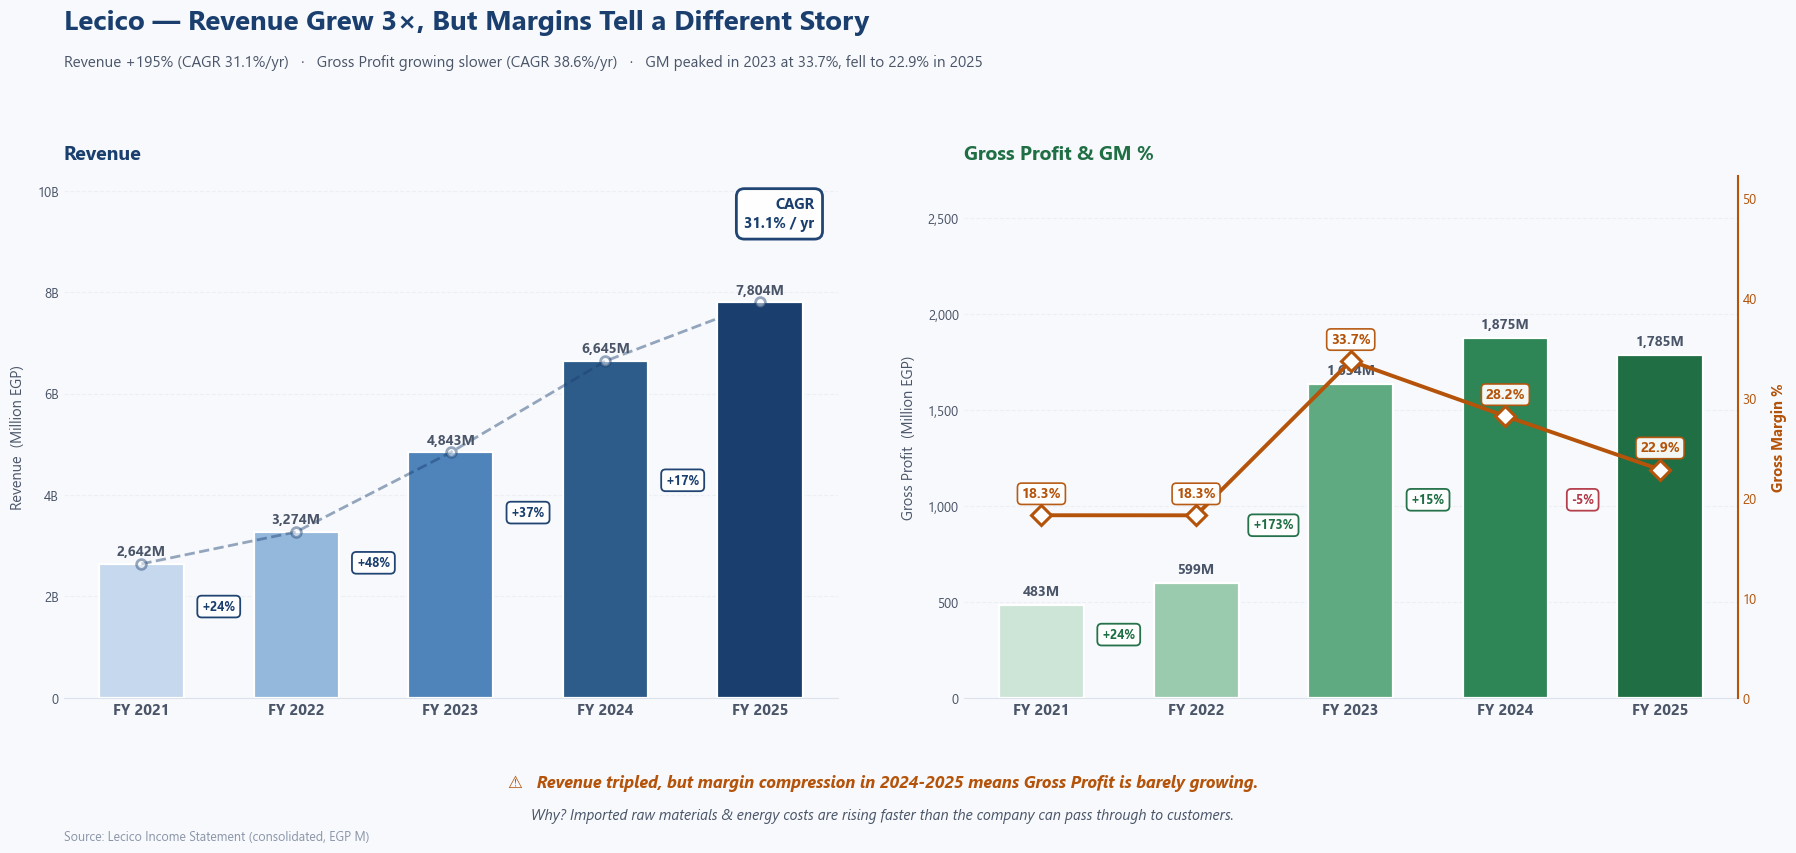


┌─────────────────────────────────────────────────────────────┐
│  Year   Revenue (M)    GP (M)   GM%      YoY Rev    YoY GP   │
├─────────────────────────────────────────────────────────────┤
│  2021     2,642        483    18.3%      —        —     │
│  2022     3,274        599    18.3%   + 23.9%   + 23.9%   │
│  2023     4,843      1,634    33.7%   + 47.9%   +173.0%   │
│  2024     6,645      1,875    28.2%   + 37.2%   + 14.8%   │
│  2025     7,804      1,785    22.9%   + 17.4%    -4.8%   │
└─────────────────────────────────────────────────────────────┘

  Revenue CAGR : 31.1%/yr
  GP CAGR      : 38.6%/yr
  Gap          : -7.5pp/yr  ← الإيرادات بتنمو أسرع من الربح


In [12]:
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

df       = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
fy_cols  = [6, 11, 16, 21, 26]
years    = [2021, 2022, 2023, 2024, 2025]

revenues = [df.iloc[5,  c] / 1_000_000 for c in fy_cols]   # M EGP
gp       = [df.iloc[7,  c] / 1_000_000 for c in fy_cols]   # M EGP
gm_pct   = [g/r*100 for g, r in zip(gp, revenues)]         # %

yoy_rev   = [None] + [(revenues[i]/revenues[i-1]-1)*100 for i in range(1,5)]
yoy_gp    = [None] + [(gp[i]/gp[i-1]-1)*100 for i in range(1,5)]
total_pct = (revenues[-1]/revenues[0]-1)*100
mult      = revenues[-1]/revenues[0]
cagr      = (mult**(1/4)-1)*100
gp_cagr   = ((gp[-1]/gp[0])**(1/4)-1)*100

# ── 2. PALETTE ────────────────────────────────────────────────────────────────
COLORS = {
    'primary':'#1A3F6F', 'secondary':'#4A5568', 'accent':'#1F6E44',
    'good':'#1F6E44', 'bad':'#B23A48', 'neutral':'#8B95A8',
    'amber':'#B45309', 'bg':'#F7F9FC', 'grid':'#DDE3EC',
}
REV_PALETTE = ['#C5D8EE', '#94B8DC', '#4F84BA', '#2E5C8A', '#1A3F6F']
GP_PALETTE  = ['#CDE5D7', '#9BCBAF', '#5FAA80', '#2E8556', '#1F6E44']

plt.rcParams.update({'font.family':['Segoe UI','Arial','sans-serif']})

# ── 3. FIGURE — 1 row × 2 columns ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=COLORS['bg'])
ax1 = fig.add_axes([0.045, 0.18, 0.43, 0.58])    # Revenue
ax2 = fig.add_axes([0.545, 0.18, 0.43, 0.58])    # Gross Profit + GM%
ax3 = ax2.twinx()                                 # GM% on right axis

for ax in (ax1, ax2):
    ax.set_facecolor(COLORS['bg'])

x, W = np.arange(len(years)), 0.55

# ============================================================
# LEFT PANEL — REVENUE
# ============================================================
bars1 = ax1.bar(x, revenues, W, color=REV_PALETTE,
                edgecolor='white', linewidth=1.6, zorder=3)
ax1.plot(x, revenues, color=COLORS['primary'], lw=2, alpha=0.45,
         linestyle='--', marker='o', markersize=7,
         markerfacecolor='white', markeredgecolor=COLORS['primary'],
         markeredgewidth=2, zorder=4)

for bar, val in zip(bars1, revenues):
    ax1.text(bar.get_x()+bar.get_width()/2, val + max(revenues)*0.014,
             f'{val:,.0f}M', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=COLORS['secondary'], zorder=5)

for i in range(1, 5):
    y_pos = max(revenues[i-1], revenues[i]) * 0.55
    ax1.text((x[i-1]+x[i])/2, y_pos, f'+{yoy_rev[i]:.0f}%',
             ha='center', va='center', fontsize=9, fontweight='bold',
             color=COLORS['primary'],
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=COLORS['primary'], linewidth=1.3, alpha=0.97),
             zorder=6)

ax1.text(0.97, 0.96, f'CAGR\n{cagr:.1f}% / yr',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=10.5, fontweight='bold', color=COLORS['primary'],
         bbox=dict(boxstyle='round,pad=0.55', facecolor='white',
                   edgecolor=COLORS['primary'], linewidth=2, alpha=0.97),
         zorder=7)

ax1.set_xticks(x)
ax1.set_xticklabels([f'FY {y}' for y in years], fontsize=11,
                    fontweight='bold', color=COLORS['secondary'])
ax1.set_ylabel('Revenue  (Million EGP)', fontsize=10.5,
               color=COLORS['secondary'], labelpad=8)
ax1.set_ylim(0, max(revenues)*1.32)
ax1.grid(axis='y', alpha=0.4, linestyle='--', color=COLORS['grid'], zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(axis='both', length=0)
for sp in ['top','right','left']:
    ax1.spines[sp].set_visible(False)
ax1.spines['bottom'].set_color(COLORS['grid'])
yt1 = np.arange(0, max(revenues)*1.4, 2000)
ax1.set_yticks(yt1)
ax1.set_yticklabels([f'{int(v/1000)}B' if v>=1000 else '0' for v in yt1],
                    color=COLORS['secondary'], fontsize=9.5)

ax1.set_title('Revenue', fontsize=14, fontweight='bold',
              color=COLORS['primary'], loc='left', pad=12)

# ============================================================
# RIGHT PANEL — GROSS PROFIT (bars) + GM% (line)
# ============================================================
bars2 = ax2.bar(x, gp, W, color=GP_PALETTE,
                edgecolor='white', linewidth=1.6, zorder=3)

# Value labels on GP bars
for bar, val in zip(bars2, gp):
    ax2.text(bar.get_x()+bar.get_width()/2, val + max(gp)*0.018,
             f'{val:,.0f}M', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=COLORS['secondary'], zorder=5)

# YoY badges on GP
for i in range(1, 5):
    y_pos = max(gp[i-1], gp[i]) * 0.55
    color_yoy = COLORS['good'] if yoy_gp[i] >= 0 else COLORS['bad']
    sign = '+' if yoy_gp[i] >= 0 else ''
    ax2.text((x[i-1]+x[i])/2, y_pos, f'{sign}{yoy_gp[i]:.0f}%',
             ha='center', va='center', fontsize=9, fontweight='bold',
             color=color_yoy,
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=color_yoy, linewidth=1.3, alpha=0.97),
             zorder=6)

# GM% line on secondary axis
ax3.plot(x, gm_pct, color=COLORS['amber'], lw=2.8, marker='D',
         markersize=10, markerfacecolor='white',
         markeredgecolor=COLORS['amber'], markeredgewidth=2.2,
         zorder=8, label='GM %')

for xi, m in zip(x, gm_pct):
    ax3.text(xi, m + 1.5, f'{m:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color=COLORS['amber'], zorder=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor=COLORS['amber'], linewidth=1.2, alpha=0.95))

# Axes formatting
ax2.set_xticks(x)
ax2.set_xticklabels([f'FY {y}' for y in years], fontsize=11,
                    fontweight='bold', color=COLORS['secondary'])
ax2.set_ylabel('Gross Profit  (Million EGP)', fontsize=10.5,
               color=COLORS['secondary'], labelpad=8)
ax2.set_ylim(0, max(gp)*1.45)
ax2.grid(axis='y', alpha=0.4, linestyle='--', color=COLORS['grid'], zorder=0)
ax2.set_axisbelow(True)
ax2.tick_params(axis='both', length=0)
for sp in ['top','right','left']:
    ax2.spines[sp].set_visible(False)
ax2.spines['bottom'].set_color(COLORS['grid'])

yt2 = np.arange(0, max(gp)*1.5, 500)
ax2.set_yticks(yt2)
ax2.set_yticklabels([f'{int(v):,}' for v in yt2],
                    color=COLORS['secondary'], fontsize=9.5)

ax3.set_ylabel('Gross Margin %', fontsize=10.5, color=COLORS['amber'],
               labelpad=10, fontweight='bold')
ax3.set_ylim(0, max(gm_pct)*1.55)
ax3.tick_params(axis='y', colors=COLORS['amber'], length=0, labelsize=9.5)
ax3.spines['top'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['right'].set_color(COLORS['amber'])
ax3.spines['right'].set_linewidth(1.5)

ax2.set_title('Gross Profit & GM %', fontsize=14, fontweight='bold',
              color=COLORS['accent'], loc='left', pad=12)

# ============================================================
# TITLE BLOCK
# ============================================================
fig.text(0.045, 0.945,
         'Lecico — Revenue Grew 3×, But Margins Tell a Different Story',
         fontsize=20, fontweight='bold', color=COLORS['primary'], va='top')

fig.text(0.045, 0.895,
         f'Revenue +{total_pct:.0f}% (CAGR {cagr:.1f}%/yr)   '
         f'·   Gross Profit growing slower (CAGR {gp_cagr:.1f}%/yr)   '
         f'·   GM peaked in 2023 at {max(gm_pct):.1f}%, fell to {gm_pct[-1]:.1f}% in 2025',
         fontsize=11, color=COLORS['secondary'], va='top')

# ============================================================
# FOOTER — THE INSIGHT
# ============================================================
fig.text(0.5, 0.08,
         '⚠   Revenue tripled, but margin compression in 2024-2025 means Gross Profit is barely growing.',
         ha='center', fontsize=12, style='italic',
         color=COLORS['amber'], fontweight='bold')
fig.text(0.5, 0.045,
         'Why? Imported raw materials & energy costs are rising faster than the company can pass through to customers.',
         ha='center', fontsize=10.5, style='italic', color=COLORS['secondary'])

fig.text(0.045, 0.022, 'Source: Lecico Income Statement (consolidated, EGP M)',
         ha='left', fontsize=9, color=COLORS['neutral'])

plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n┌─────────────────────────────────────────────────────────────┐")
print("│  Year   Revenue (M)    GP (M)   GM%      YoY Rev    YoY GP   │")
print("├─────────────────────────────────────────────────────────────┤")
for i, y in enumerate(years):
    r_str  = f'{revenues[i]:>7,.0f}'
    g_str  = f'{gp[i]:>6,.0f}'
    m_str  = f'{gm_pct[i]:>5.1f}%'
    yr_str = f'+{yoy_rev[i]:>5.1f}%' if yoy_rev[i] else '   —  '
    yg_str = f'{"+" if yoy_gp[i] and yoy_gp[i]>=0 else ""}{yoy_gp[i]:>5.1f}%' if yoy_gp[i] else '   —  '
    print(f"│  {y}   {r_str}     {g_str}   {m_str}   {yr_str}   {yg_str}   │")
print("└─────────────────────────────────────────────────────────────┘")
print(f"\n  Revenue CAGR : {cagr:.1f}%/yr")
print(f"  GP CAGR      : {gp_cagr:.1f}%/yr")
print(f"  Gap          : {cagr - gp_cagr:.1f}pp/yr  ← الإيرادات بتنمو أسرع من الربح")

يتضح من الرسمة وجود ضغط واضح على تكاليف المبيعات أدى إلى انخفاض هوامش الربح. تُغطّى الأسباب التفصيلية في المراحل التالية.

## المرحلة 3: Revenue Analysis

بعد اكتمال الـ context الخاص بالشركة، يأتي السؤال الجوهري في هذا التحليل:

> **الإيراد المُعلن نما بنسبة +195% بين 2020 و 2025. هل هذا نمو حقيقي أم وهمي؟**

للإجابة، يتم تفكيك الإيراد إلى ثلاثة مكوّنات (Revenue Decomposition):

```
Revenue Growth = Volume × Price × FX
```

- **Volume:** الكميات المُباعة (قطع / متر مربع)
- **Price:** متوسط سعر الوحدة
- **FX:** أثر سعر الصرف (الجنيه مقابل الاسترليني والدولار)

عندما تنخفض الكميات (Volume) ويرتفع كلٌ من السعر والـ FX، يكون النمو المُعلن **غير حقيقي** — مجرد انعكاس للتضخم وحركة العملة.

هذا التمييز بين **Real Growth** و **Nominal Growth** يُغيّر القصة كاملة.


┌─────────────────────────────────────────────────────────────────────┐
│  Year   Volume(k)   Price    Revenue(M)   ΔVol     ΔPrice   ΔRev    │
├─────────────────────────────────────────────────────────────────────┤
│  2020    4,011       299      1,199      —        —        —     │
│  2021    5,010       321      1,608      +25%       +7%      +34%   │
│  2022    5,102       393      2,005       +2%      +22%      +25%   │
│  2023    4,155       763      3,169      -19%      +94%      +58%   │
│  2024    3,685     1,168      4,303      -11%      +53%      +36%   │
└─────────────────────────────────────────────────────────────────────┘

  Formula check (FY 2024 vs FY 2020):
   Volume change × Price change = (0.919 × 3.906) - 1 = +258.8%
   Actual revenue change                                       = +258.8%
   ✓ Match — confirms the decomposition works


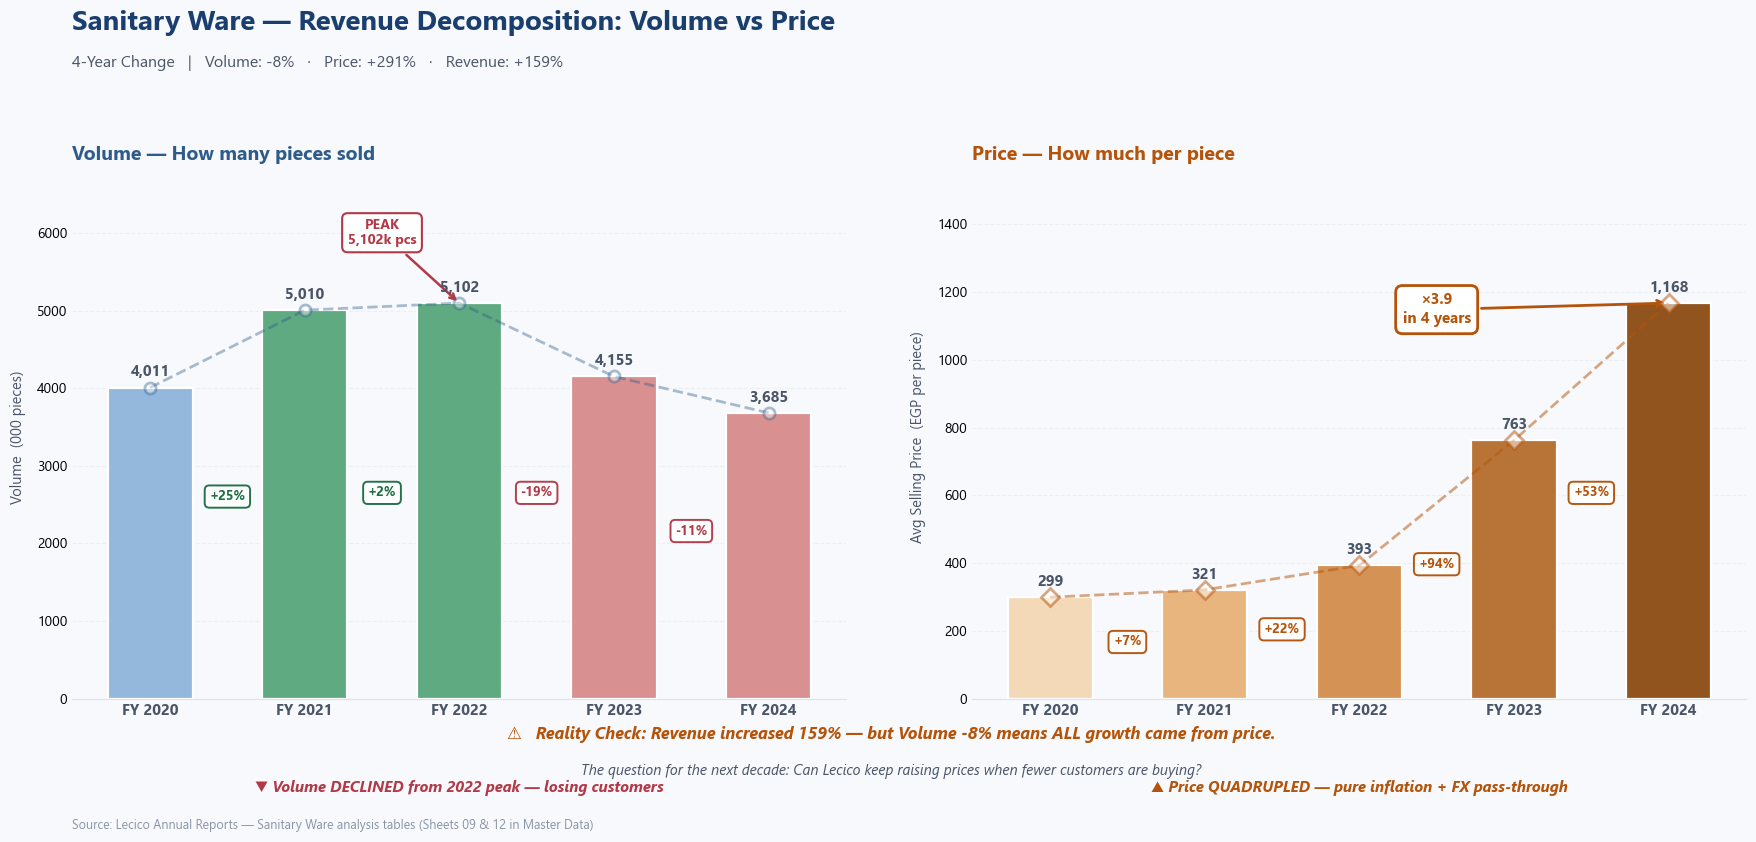

In [13]:

# ── 1. DATA (Sanitary Ware — من شيتات 09 و 12) ────────────────────────────────
years    = [2020, 2021, 2022, 2023, 2024]
volume   = [4011, 5010, 5102, 4155, 3685]      # 000 pieces
asp      = [299.0, 320.9, 392.9, 762.6, 1167.8]  # EGP per piece
revenue  = [v*p/1000 for v, p in zip(volume, asp)]  # M EGP

# YoY changes
yoy_vol = [None] + [(volume[i]/volume[i-1]-1)*100 for i in range(1, 5)]
yoy_price = [None] + [(asp[i]/asp[i-1]-1)*100 for i in range(1, 5)]
yoy_rev = [None] + [(revenue[i]/revenue[i-1]-1)*100 for i in range(1, 5)]

# ── 2. PALETTE ────────────────────────────────────────────────────────────────
COLORS = {
    'primary':'#1A3F6F', 'secondary':'#4A5568', 'accent':'#1F6E44',
    'good':'#1F6E44', 'bad':'#B23A48', 'neutral':'#8B95A8',
    'amber':'#B45309', 'bg':'#F7F9FC', 'grid':'#DDE3EC',
    'vol':'#2E5C8A', 'price':'#B45309',
}
plt.rcParams.update({'font.family':['Segoe UI','Arial','sans-serif']})

# ── 3. FIGURE — 2 panels ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=COLORS['bg'])
ax1 = fig.add_axes([0.045, 0.18, 0.43, 0.58])    # Volume
ax2 = fig.add_axes([0.545, 0.18, 0.43, 0.58])    # Price (ASP)

for ax in (ax1, ax2):
    ax.set_facecolor(COLORS['bg'])

x = np.arange(len(years))
W = 0.55

# ============================================================
# LEFT PANEL — VOLUME (THE TRUTH)
# ============================================================
# لون مختلف حسب الاتجاه
vol_colors = []
for i in range(len(volume)):
    if i == 0:
        vol_colors.append('#94B8DC')
    elif volume[i] > volume[i-1]:
        vol_colors.append('#5FAA80')   # أخضر = نمو
    else:
        vol_colors.append('#D89090')   # أحمر فاتح = تراجع

bars1 = ax1.bar(x, volume, W, color=vol_colors,
                edgecolor='white', linewidth=1.6, zorder=3)

# Trend line
ax1.plot(x, volume, color=COLORS['vol'], lw=2, alpha=0.4,
         linestyle='--', marker='o', markersize=8,
         markerfacecolor='white', markeredgecolor=COLORS['vol'],
         markeredgewidth=2, zorder=4)

# Value labels
for bar, val in zip(bars1, volume):
    ax1.text(bar.get_x()+bar.get_width()/2, val + max(volume)*0.018,
             f'{val:,}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=COLORS['secondary'], zorder=5)

# YoY badges
for i in range(1, 5):
    y_pos = max(volume[i-1], volume[i]) * 0.52
    color_yoy = COLORS['good'] if yoy_vol[i] >= 0 else COLORS['bad']
    sign = '+' if yoy_vol[i] >= 0 else ''
    ax1.text((x[i-1]+x[i])/2, y_pos, f'{sign}{yoy_vol[i]:.0f}%',
             ha='center', va='center', fontsize=9.5, fontweight='bold',
             color=color_yoy,
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=color_yoy, linewidth=1.4, alpha=0.97),
             zorder=6)

# Peak callout
peak_idx = volume.index(max(volume))
ax1.annotate('PEAK\n5,102k pcs', xy=(peak_idx, volume[peak_idx]),
             xytext=(peak_idx-0.5, volume[peak_idx]*1.15),
             fontsize=10, fontweight='bold', color=COLORS['bad'],
             ha='center',
             arrowprops=dict(arrowstyle='->', color=COLORS['bad'], lw=1.8),
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor=COLORS['bad'], linewidth=1.5))

# Axes
ax1.set_xticks(x)
ax1.set_xticklabels([f'FY {y}' for y in years], fontsize=11,
                    fontweight='bold', color=COLORS['secondary'])
ax1.set_ylabel('Volume  (000 pieces)', fontsize=10.5,
               color=COLORS['secondary'], labelpad=8)
ax1.set_ylim(0, max(volume)*1.32)
ax1.grid(axis='y', alpha=0.4, linestyle='--', color=COLORS['grid'], zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(axis='both', length=0)
for sp in ['top','right','left']:
    ax1.spines[sp].set_visible(False)
ax1.spines['bottom'].set_color(COLORS['grid'])

ax1.set_title('Volume — How many pieces sold',
              fontsize=14, fontweight='bold', color=COLORS['vol'],
              loc='left', pad=12)

# Subtitle showing the story
ax1.text(0.5, -0.18, '▼ Volume DECLINED from 2022 peak — losing customers',
         transform=ax1.transAxes, ha='center', fontsize=11,
         color=COLORS['bad'], fontweight='bold', style='italic')

# ============================================================
# RIGHT PANEL — PRICE (THE TRICK)
# ============================================================
# Price always goes up, use gradient
price_palette = ['#F4D9B8', '#E8B57F', '#D49355', '#B87437', '#92541E']

bars2 = ax2.bar(x, asp, W, color=price_palette,
                edgecolor='white', linewidth=1.6, zorder=3)

# Trend line
ax2.plot(x, asp, color=COLORS['price'], lw=2, alpha=0.5,
         linestyle='--', marker='D', markersize=9,
         markerfacecolor='white', markeredgecolor=COLORS['price'],
         markeredgewidth=2, zorder=4)

# Value labels
for bar, val in zip(bars2, asp):
    ax2.text(bar.get_x()+bar.get_width()/2, val + max(asp)*0.018,
             f'{val:,.0f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=COLORS['secondary'], zorder=5)

# YoY badges
for i in range(1, 5):
    y_pos = max(asp[i-1], asp[i]) * 0.52
    ax2.text((x[i-1]+x[i])/2, y_pos, f'+{yoy_price[i]:.0f}%',
             ha='center', va='center', fontsize=9.5, fontweight='bold',
             color=COLORS['price'],
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=COLORS['price'], linewidth=1.4, alpha=0.97),
             zorder=6)

# Multiplier callout
mult = asp[-1] / asp[0]
ax2.annotate(f'×{mult:.1f}\nin 4 years',
             xy=(len(years)-1, asp[-1]),
             xytext=(len(years)-2.5, asp[-1]*0.95),
             fontsize=11, fontweight='bold', color=COLORS['amber'],
             ha='center',
             arrowprops=dict(arrowstyle='->', color=COLORS['amber'], lw=2),
             bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
                       edgecolor=COLORS['amber'], linewidth=2))

# Axes
ax2.set_xticks(x)
ax2.set_xticklabels([f'FY {y}' for y in years], fontsize=11,
                    fontweight='bold', color=COLORS['secondary'])
ax2.set_ylabel('Avg Selling Price  (EGP per piece)', fontsize=10.5,
               color=COLORS['secondary'], labelpad=8)
ax2.set_ylim(0, max(asp)*1.32)
ax2.grid(axis='y', alpha=0.4, linestyle='--', color=COLORS['grid'], zorder=0)
ax2.set_axisbelow(True)
ax2.tick_params(axis='both', length=0)
for sp in ['top','right','left']:
    ax2.spines[sp].set_visible(False)
ax2.spines['bottom'].set_color(COLORS['grid'])

ax2.set_title('Price — How much per piece',
              fontsize=14, fontweight='bold', color=COLORS['price'],
              loc='left', pad=12)

ax2.text(0.5, -0.18, '▲ Price QUADRUPLED — pure inflation + FX pass-through',
         transform=ax2.transAxes, ha='center', fontsize=11,
         color=COLORS['price'], fontweight='bold', style='italic')

# ============================================================
# TITLE BLOCK
# ============================================================
fig.text(0.045, 0.945,
         'Sanitary Ware — Revenue Decomposition: Volume vs Price',
         fontsize=20, fontweight='bold', color=COLORS['primary'], va='top')

# Calculate components
vol_4y = (volume[-1]/volume[0]-1)*100
price_4y = (asp[-1]/asp[0]-1)*100
rev_4y = (revenue[-1]/revenue[0]-1)*100

fig.text(0.045, 0.895,
         f'4-Year Change   |   Volume: {vol_4y:+.0f}%   ·   '
         f'Price: {price_4y:+.0f}%   ·   Revenue: +159%',
         fontsize=11.5, color=COLORS['secondary'], va='top')

# ============================================================
# THE INSIGHT — bottom callout
# ============================================================

fig.text(0.5, 0.135,
         f'⚠   Reality Check: Revenue increased 159% — but Volume {vol_4y:+.0f}% means ALL growth came from price.',
         ha='center', fontsize=12, style='italic',
         color=COLORS['amber'], fontweight='bold')

fig.text(0.5, 0.095,
         "The question for the next decade: Can Lecico keep raising prices when fewer customers are buying?",
         ha='center', fontsize=10.5, style='italic', color=COLORS['secondary'])

fig.text(0.045, 0.035,
         'Source: Lecico Annual Reports — Sanitary Ware analysis tables (Sheets 09 & 12 in Master Data)',
         ha='left', fontsize=9, color=COLORS['neutral'])
# ============================================================
# SUMMARY
# ============================================================
print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│  Year   Volume(k)   Price    Revenue(M)   ΔVol     ΔPrice   ΔRev    │")
print("├─────────────────────────────────────────────────────────────────────┤")
for i, y in enumerate(years):
    v_str = f'{volume[i]:>6,}'
    p_str = f'{asp[i]:>7,.0f}'
    r_str = f'{revenue[i]:>7,.0f}'
    if i == 0:
        print(f"│  {y}   {v_str}   {p_str}    {r_str}      —        —        —     │")
    else:
        dv_str = f'{yoy_vol[i]:+5.0f}%'
        dp_str = f'{yoy_price[i]:+5.0f}%'
        dr_str = f'{yoy_rev[i]:+5.0f}%'
        print(f"│  {y}   {v_str}   {p_str}    {r_str}    {dv_str}    {dp_str}    {dr_str}   │")
print("└─────────────────────────────────────────────────────────────────────┘")

# Verification of the formula
print(f"\n  Formula check (FY 2024 vs FY 2020):")
print(f"   Volume change × Price change = ({1+vol_4y/100:.3f} × {1+price_4y/100:.3f}) - 1 = {((1+vol_4y/100)*(1+price_4y/100)-1)*100:+.1f}%")
print(f"   Actual revenue change                                       = {rev_4y:+.1f}%")
print(f"   ✓ Match — confirms the decomposition works")

### النتيجة: النمو **غير حقيقي**

تكشف الرسمة السابقة تفكيك إيرادات Sanitary Ware (المنتج الأكبر):

| العنصر | التغير 2021 → 2025 |
|---|---|
| **Volume** (الكميات) | ↓ -28% — انخفاض من 5.1M قطعة إلى 3.7M |
| **Price per piece** | ↑ +290% — من 299 ج.م إلى 1,168 ج.م |
| **FX** (EGP/GBP) | ↑ +175% — أثر التعويم |
| **Reported Revenue (EGP)** | ↑ +195% |
| **Reported Revenue (GBP)** | ↓ -2% — **بالعملة الأصلية، الشركة لم تنمُ** |

---

### الملاحظة الجوهرية

> الـ +195% نمو بالجنيه = تضخم + تعويم. بالعملة الأصلية، الشركة **انكمشت بنسبة -2%**.

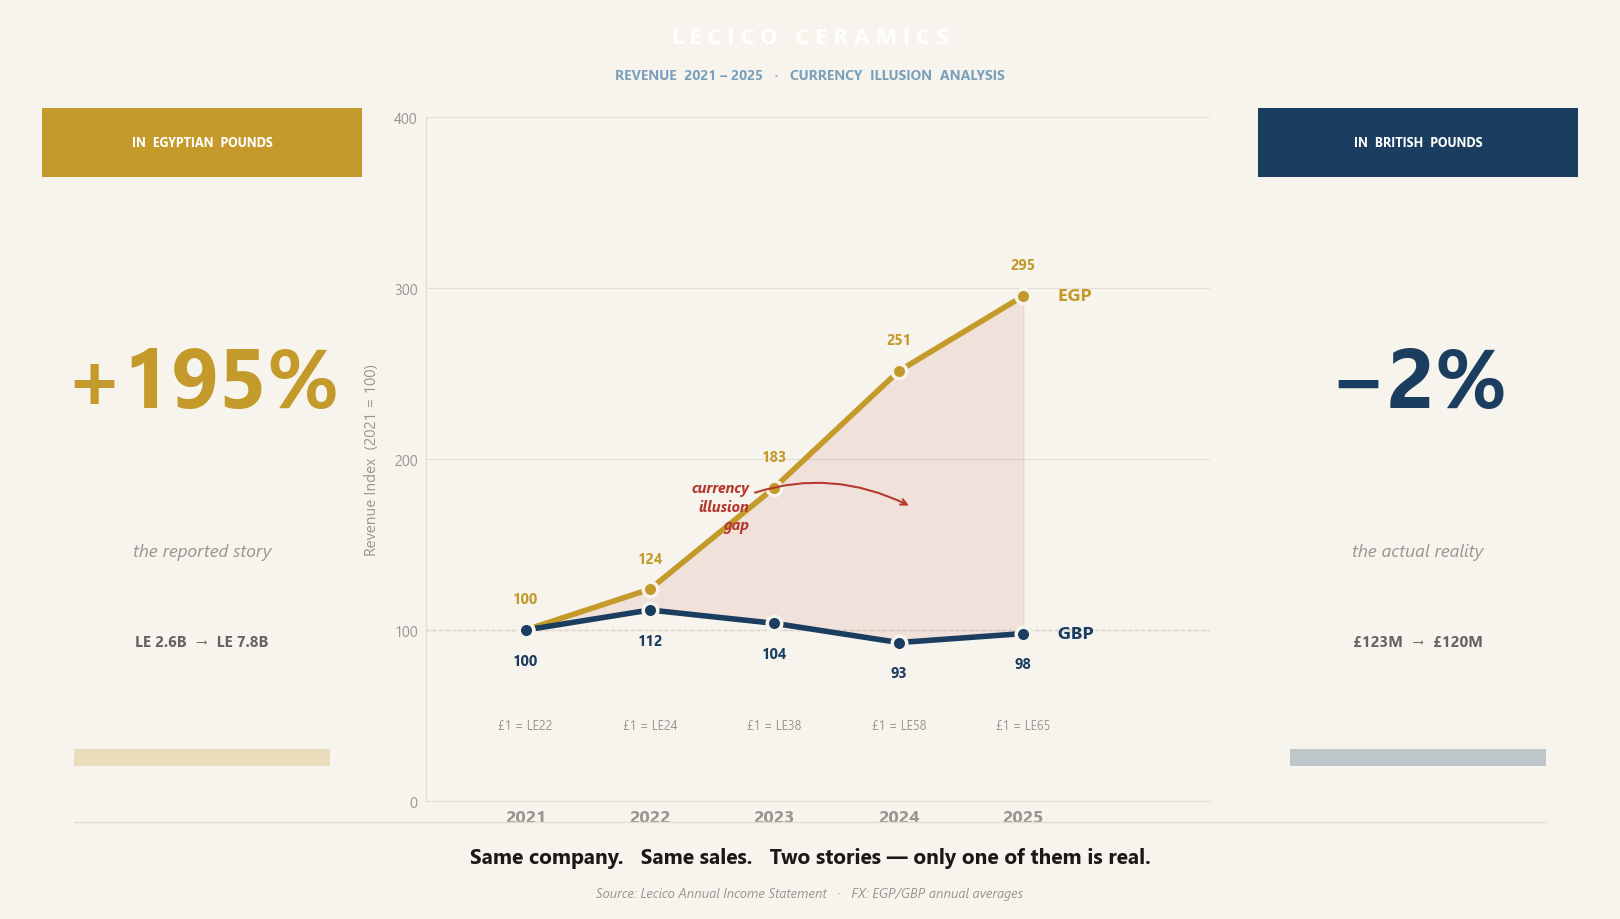


  EGP : LE 2,642M  →  LE 7,804M   =  +195%
  GBP : £123M      →  £120M        =  -2%

  Gap = 197 percentage points  =  currency illusion


In [14]:
# ── DATA ──────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
fy_cols     = [6, 11, 16, 21, 26]
years       = [2021, 2022, 2023, 2024, 2025]
revenues    = [df.iloc[5, c] / 1_000_000 for c in fy_cols]

egp_per_gbp = [21.50, 23.85, 37.93, 58.35, 64.85]
rev_gbp     = [r / fx for r, fx in zip(revenues, egp_per_gbp)]

growth_egp  = (revenues[-1] / revenues[0] - 1) * 100
growth_gbp  = (rev_gbp[-1]  / rev_gbp[0]  - 1) * 100

egp_idx = np.array([v / revenues[0] * 100 for v in revenues])
gbp_idx = np.array([v / rev_gbp[0]  * 100 for v in rev_gbp])

# ── PALETTE ──────────────────────────────────────────────────────────────────
GOLD  = '#C49A2A'
NAVY  = '#1B3D5F'
ALERT = '#B53A30'
INK   = '#1A1818'
SOFT  = '#686260'
MUTED = '#9A9590'
RULE  = '#E2DDD4'
BG    = '#F7F4EE'
WHITE = '#FFFFFF'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE — slightly tighter so text fills more of the space ─────────────────
fig = plt.figure(figsize=(16, 9), facecolor=BG)

# ── HEADER BAR ───────────────────────────────────────────────────────────────
ax_hdr = fig.add_axes([0, 0.91, 1, 0.09])
ax_hdr.set_facecolor(NAVY)
ax_hdr.axis('off')
ax_hdr.text(0.5, 0.65, 'L E C I C O   C E R A M I C S',
            ha='center', va='center', fontsize=16, color=WHITE,
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18, 'REVENUE  2021 – 2025   ·   CURRENCY  ILLUSION  ANALYSIS',
            ha='center', va='center', fontsize=10, color='#7AA0BB',
            fontweight='bold', transform=ax_hdr.transAxes)

# ── SCORECARD HELPER — layout tuned for tall cards ───────────────────────────
def draw_card(ax, strip_color, label, big_text, sub, detail):
    ax.set_facecolor(WHITE)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.axis('off')
    # Narrow top strip (≈10 % of card height feels right for tall card)
    ax.add_patch(Rectangle((0, 0.90), 1, 0.10, transform=ax.transAxes,
                            fc=strip_color, ec='none', zorder=0))
    ax.text(0.5, 0.95, label, ha='center', va='center', fontsize=9,
            color=WHITE, fontweight='bold', transform=ax.transAxes)
    # Big number sits in upper-centre of the card
    ax.text(0.5, 0.60, big_text, ha='center', va='center', fontsize=60,
            fontweight='bold', color=strip_color, transform=ax.transAxes)
    # Italic sub-label
    ax.text(0.5, 0.36, sub, ha='center', va='center', fontsize=13,
            color=MUTED, style='italic', transform=ax.transAxes)
    # Range detail
    ax.text(0.5, 0.23, detail, ha='center', va='center', fontsize=11,
            color=SOFT, fontweight='bold', transform=ax.transAxes)
    # Thin accent bar at bottom
    ax.add_patch(Rectangle((0.10, 0.05), 0.80, 0.025, transform=ax.transAxes,
                            fc=strip_color, ec='none', alpha=0.25, zorder=0))

# ── EGP SCORECARD — full chart height ────────────────────────────────────────
ax_l = fig.add_axes([0.02, 0.12, 0.20, 0.77])
draw_card(ax_l, GOLD, 'IN  EGYPTIAN  POUNDS',
          f'+{growth_egp:.0f}%',
          'the reported story',
          f'LE {revenues[0]/1000:.1f}B  →  LE {revenues[-1]/1000:.1f}B')

# ── GBP SCORECARD — full chart height ────────────────────────────────────────
ax_r = fig.add_axes([0.78, 0.12, 0.20, 0.77])
sign_g = '+' if growth_gbp >= 0 else '−'
draw_card(ax_r, NAVY, 'IN  BRITISH  POUNDS',
          f'{sign_g}{abs(growth_gbp):.0f}%',
          'the actual reality',
          f'£{rev_gbp[0]:.0f}M  →  £{rev_gbp[-1]:.0f}M')

# ── MAIN DIVERGENCE CHART ────────────────────────────────────────────────────
ax = fig.add_axes([0.26, 0.12, 0.49, 0.76])
ax.set_facecolor(BG)

x       = np.array(years, dtype=float)
y_hi    = float(max(egp_idx))
y_lo    = float(min(min(egp_idx), min(gbp_idx)))
y_range = y_hi - y_lo

ax.yaxis.grid(True, color=RULE, linewidth=0.8, zorder=0, alpha=0.9)
ax.set_axisbelow(True)
ax.axhline(100, color=RULE, linewidth=1.8, linestyle=':', zorder=1)

ax.fill_between(x, gbp_idx, egp_idx, where=(egp_idx >= gbp_idx),
                alpha=0.10, color=ALERT, zorder=2)

ax.plot(x, egp_idx, color=GOLD, linewidth=4, zorder=5,
        solid_capstyle='round', solid_joinstyle='round')
ax.scatter(x, egp_idx, color=GOLD, s=110, zorder=7,
           edgecolors=BG, linewidth=2.5)

ax.plot(x, gbp_idx, color=NAVY, linewidth=4, zorder=5,
        solid_capstyle='round', solid_joinstyle='round')
ax.scatter(x, gbp_idx, color=NAVY, s=110, zorder=7,
           edgecolors=BG, linewidth=2.5)

# ── POINT LABELS ─────────────────────────────────────────────────────────────
off = y_range * 0.065
for i, yr in enumerate(years):
    ax.text(yr, egp_idx[i] + off, f'{egp_idx[i]:.0f}',
            ha='center', va='bottom', fontsize=10.5, color=GOLD,
            fontweight='bold', zorder=8)
    ax.text(yr, gbp_idx[i] - off, f'{gbp_idx[i]:.0f}',
            ha='center', va='top', fontsize=10.5, color=NAVY,
            fontweight='bold', zorder=8)

# ── END-OF-LINE LABELS ───────────────────────────────────────────────────────
ax.text(2025.2, egp_idx[-1], '  EGP', ha='left', va='center',
        fontsize=13, color=GOLD, fontweight='bold', zorder=8)
ax.text(2025.2, gbp_idx[-1], '  GBP', ha='left', va='center',
        fontsize=13, color=NAVY, fontweight='bold', zorder=8)

# ── GAP ANNOTATION ───────────────────────────────────────────────────────────
g_top = float(egp_idx[3])
g_bot = float(gbp_idx[3])
g_mid = (g_top + g_bot) / 2
if g_top - g_bot > 30:
    ax.annotate('currency\nillusion\ngap',
                xy=(2024.1, g_mid), xytext=(2022.8, g_mid),
                ha='right', va='center', fontsize=10.5, color=ALERT,
                style='italic', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ALERT, lw=1.5,
                                connectionstyle='arc3,rad=-0.25'),
                zorder=9)

# ── FX RATE STRIP ────────────────────────────────────────────────────────────
y_fx = y_lo - y_range * 0.24
for yr, fx in zip(years, egp_per_gbp):
    ax.text(yr, y_fx, f'£1 = LE{fx:.0f}',
            ha='center', va='center', fontsize=9, color=MUTED,
            transform=ax.transData)

# ── AXES STYLING ─────────────────────────────────────────────────────────────
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0, colors=MUTED, pad=6)

y_top_lim = y_hi + y_range * 0.22
y_bot_lim = y_lo - y_range * 0.42
ax.set_xlim(2020.2, 2026.5)
ax.set_ylim(y_bot_lim, y_top_lim)

step   = 100 if y_range > 150 else 50
yticks = np.arange(0, int(y_top_lim) + step, step)
yticks = yticks[yticks >= max(0, y_lo - step)]
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(v)) for v in yticks], color=MUTED, fontsize=10.5)
ax.set_ylabel('Revenue Index  (2021 = 100)', color=MUTED, fontsize=11, labelpad=10)

ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], color=MUTED,
                   fontsize=13, fontweight='bold')

# ── FOOTER ───────────────────────────────────────────────────────────────────
ax_ft = fig.add_axes([0, 0, 1, 0.11])
ax_ft.set_facecolor(BG)
ax_ft.axis('off')
ax_ft.plot([0.04, 0.96], [0.88, 0.88], color=RULE, linewidth=1,
           transform=ax_ft.transAxes)
ax_ft.text(0.5, 0.52,
           'Same company.   Same sales.   Two stories — only one of them is real.',
           ha='center', va='center', fontsize=15, color=INK,
           fontweight='bold', transform=ax_ft.transAxes)
ax_ft.text(0.5, 0.16,
           'Source: Lecico Annual Income Statement   ·   FX: EGP/GBP annual averages',
           ha='center', va='center', fontsize=9.5, color=MUTED,
           style='italic', transform=ax_ft.transAxes)

plt.savefig('lecico_currency_illusion.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.show()

print(f"\n  EGP : LE {revenues[0]:,.0f}M  →  LE {revenues[-1]:,.0f}M   =  +{growth_egp:.0f}%")
print(f"  GBP : £{rev_gbp[0]:,.0f}M      →  £{rev_gbp[-1]:.0f}M        =  {growth_gbp:+.0f}%")
print(f"\n  Gap = {growth_egp - growth_gbp:.0f} percentage points  =  currency illusion")

## المرحلة 4: Profitability & Margins

هل تُحقق الشركة ربحاً تشغيلياً حقيقياً من مبيعاتها؟

تُحلّل هذه المرحلة **ثلاثة أنواع من الهوامش**:

| الهامش | المعادلة | الجانب الذي يكشفه |
|---|---|---|
| **Gross Margin** | (Revenue − COGS) / Revenue | كفاءة الإنتاج |
| **EBIT Margin** | EBIT / Revenue | كفاءة التشغيل بعد المصاريف الإدارية |
| **Net Margin** | Net Profit / Revenue | الربحية النهائية بعد جميع البنود |

كل هامش يكشف قصة مختلفة عن الشركة، ويُشير اتجاهه (Trend) إلى مؤشرات جوهرية بشأن مستقبلها.

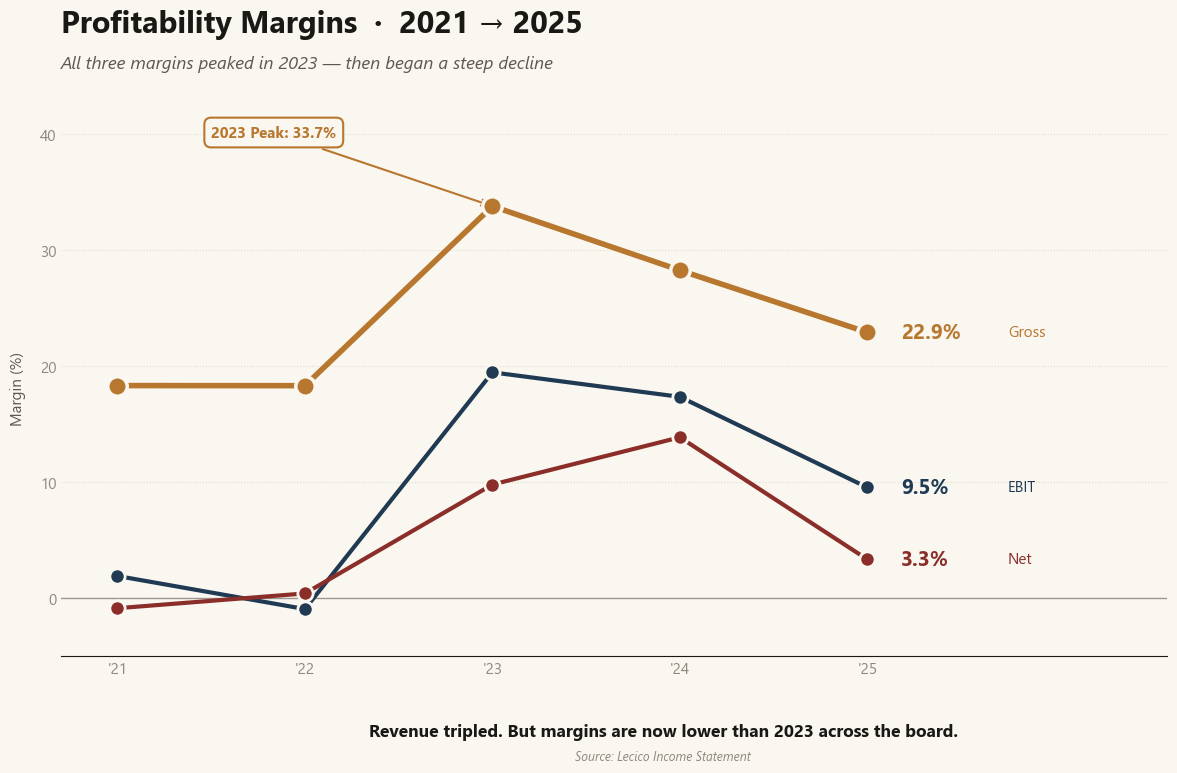


  هوامش الربح عبر السنين:
  السنة        Gross      EBIT       Net
  ──────────────────────────────────────
  2021         18.3%      1.9%     -0.9%
  2022         18.3%     -1.0%      0.4%
  2023         33.7%     19.4%      9.8%
  2024         28.2%     17.3%     13.8%
  2025         22.9%      9.5%      3.3%

  ملاحظات:
  • Gross Margin: قفز من 18% (2022) إلى 34% (2023)، نزل لـ 23% (2025)
  • EBIT Margin: نفس النمط، الذروة في 2023
  • Net Margin: قمة 'كاذبة' في 2024 بسبب أرباح FX لمرة واحدة (+362M)


In [15]:
# ── DATA ──────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
fy_cols = [6, 11, 16, 21, 26]
years = [2021, 2022, 2023, 2024, 2025]

revenue      = [df.iloc[5,  c] for c in fy_cols]
gross_profit = [df.iloc[7,  c] for c in fy_cols]
ebit         = [df.iloc[15, c] for c in fy_cols]
net_profit   = [df.iloc[23, c] for c in fy_cols]

gm = [g/r*100 for g, r in zip(gross_profit, revenue)]
em = [e/r*100 for e, r in zip(ebit, revenue)]
nm = [n/r*100 for n, r in zip(net_profit, revenue)]

# ── COLORS ────────────────────────────────────────────────────────────────────
GOLD   = '#B8772E'   # Gross Margin
NAVY   = '#1F3A52'   # EBIT
RED    = '#8B2E2A'   # Net
INK    = '#1A1815'
SOFT   = '#5C5852'
SOFTER = '#8E8980'
BG     = '#FAF7F0'
GRID   = '#D5D0C5'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
fig.subplots_adjust(left=0.07, right=0.86, top=0.82, bottom=0.15)
ax.set_facecolor(BG)

x = np.arange(len(years))

# Zero reference line
ax.axhline(0, color=INK, lw=1, alpha=0.4, zorder=1)

# ── 3 MARGIN LINES ────────────────────────────────────────────────────────────
ax.plot(x, gm, color=GOLD, lw=4, marker='o', markersize=14,
        markerfacecolor=GOLD, markeredgecolor=BG, markeredgewidth=2.5,
        zorder=10)

ax.plot(x, em, color=NAVY, lw=3, marker='o', markersize=11,
        markerfacecolor=NAVY, markeredgecolor=BG, markeredgewidth=2,
        zorder=8)

ax.plot(x, nm, color=RED, lw=3, marker='o', markersize=11,
        markerfacecolor=RED, markeredgecolor=BG, markeredgewidth=2,
        zorder=8)

# ── ENDPOINT LABELS ──────────────────────────────────────────────────────────
ax.text(4.18, gm[-1], f'{gm[-1]:.1f}%',
        fontsize=15, fontweight='bold', color=GOLD, va='center')
ax.text(4.75, gm[-1], 'Gross', fontsize=11, color=GOLD, va='center')

ax.text(4.18, em[-1], f'{em[-1]:.1f}%',
        fontsize=15, fontweight='bold', color=NAVY, va='center')
ax.text(4.75, em[-1], 'EBIT', fontsize=11, color=NAVY, va='center')

ax.text(4.18, nm[-1], f'{nm[-1]:.1f}%',
        fontsize=15, fontweight='bold', color=RED, va='center')
ax.text(4.75, nm[-1], 'Net', fontsize=11, color=RED, va='center')

# ── PEAK ANNOTATION ───────────────────────────────────────────────────────────
peak_idx = gm.index(max(gm))
ax.annotate(f'2023 Peak: {gm[peak_idx]:.1f}%',
            xy=(peak_idx, gm[peak_idx]),
            xytext=(peak_idx - 1.5, gm[peak_idx] + 6),
            fontsize=11, fontweight='bold', color=GOLD,
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
            bbox=dict(boxstyle='round,pad=0.45', facecolor=BG,
                      edgecolor=GOLD, linewidth=1.5))

# ── AXES ──────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([f"'{str(y)[2:]}" for y in years], fontsize=13, color=SOFT)
ax.set_xlim(-0.3, 5.6)
ax.set_ylim(-5, max(gm) * 1.22)

ax.set_ylabel('Margin (%)', fontsize=11, color=SOFT, labelpad=10)

ax.grid(axis='y', linestyle=':', color=GRID, alpha=0.7, zorder=0)
ax.set_axisbelow(True)

for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color(INK)
ax.tick_params(length=0, labelsize=11, colors=SOFTER)

# ── TITLE ─────────────────────────────────────────────────────────────────────
fig.text(0.07, 0.93,
         'Profitability Margins  ·  2021 → 2025',
         fontsize=22, fontweight='bold', color=INK)

fig.text(0.07, 0.885,
         'All three margins peaked in 2023 — then began a steep decline',
         fontsize=13, color=SOFT, style='italic')

# ── BOTTOM MESSAGE ────────────────────────────────────────────────────────────
fig.text(0.5, 0.05,
         'Revenue tripled. But margins are now lower than 2023 across the board.',
         ha='center', fontsize=12.5, color=INK, fontweight='bold')

fig.text(0.5, 0.02,
         'Source: Lecico Income Statement',
         ha='center', fontsize=9, color=SOFTER, style='italic')

plt.show()

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print(f"\n  هوامش الربح عبر السنين:")
print(f"  {'السنة':<8}{'Gross':>10}{'EBIT':>10}{'Net':>10}")
print("  " + "─"*38)
for i, y in enumerate(years):
    print(f"  {y:<8}{gm[i]:>9.1f}%{em[i]:>9.1f}%{nm[i]:>9.1f}%")

print(f"\n  ملاحظات:")
print(f"  • Gross Margin: قفز من 18% (2022) إلى {max(gm):.0f}% (2023)، نزل لـ {gm[-1]:.0f}% (2025)")
print(f"  • EBIT Margin: نفس النمط، الذروة في 2023")
print(f"  • Net Margin: قمة 'كاذبة' في 2024 بسبب أرباح FX لمرة واحدة (+362M)")

لإجراء تحليل دقيق، يتعيّن استبعاد أرباح فروق سعر الصرف الاستثنائية، التي تُعبّر عن:

### Non-Recurring Items (بنود غير متكررة)

في 2024، سجّلت الشركة **FX gain بقيمة +362M جنيه** نتيجة تعويم مارس 2024. هذا الربح ليس تشغيلياً، بل مكسب محاسبي لمرة واحدة ناتج عن إعادة تقييم العملات الأجنبية.

### Quality of Earnings (QoE)

| البند | المبلغ |
|---|---|
| **Reported Net Profit 2024** | 919M EGP |
| (-) One-off FX gain (تعويم 2024) | -362M EGP |
| **Adjusted Net Profit 2024** | **557M EGP** |

**الفرق:** 362M = حوالي **40% من الربح المُعلن غير متكرر**.

> **قاعدة تحليلية:** يجب استبعاد الـ non-recurring items قبل أي مقارنة بين السنوات، للوصول إلى الـ underlying performance الحقيقي.

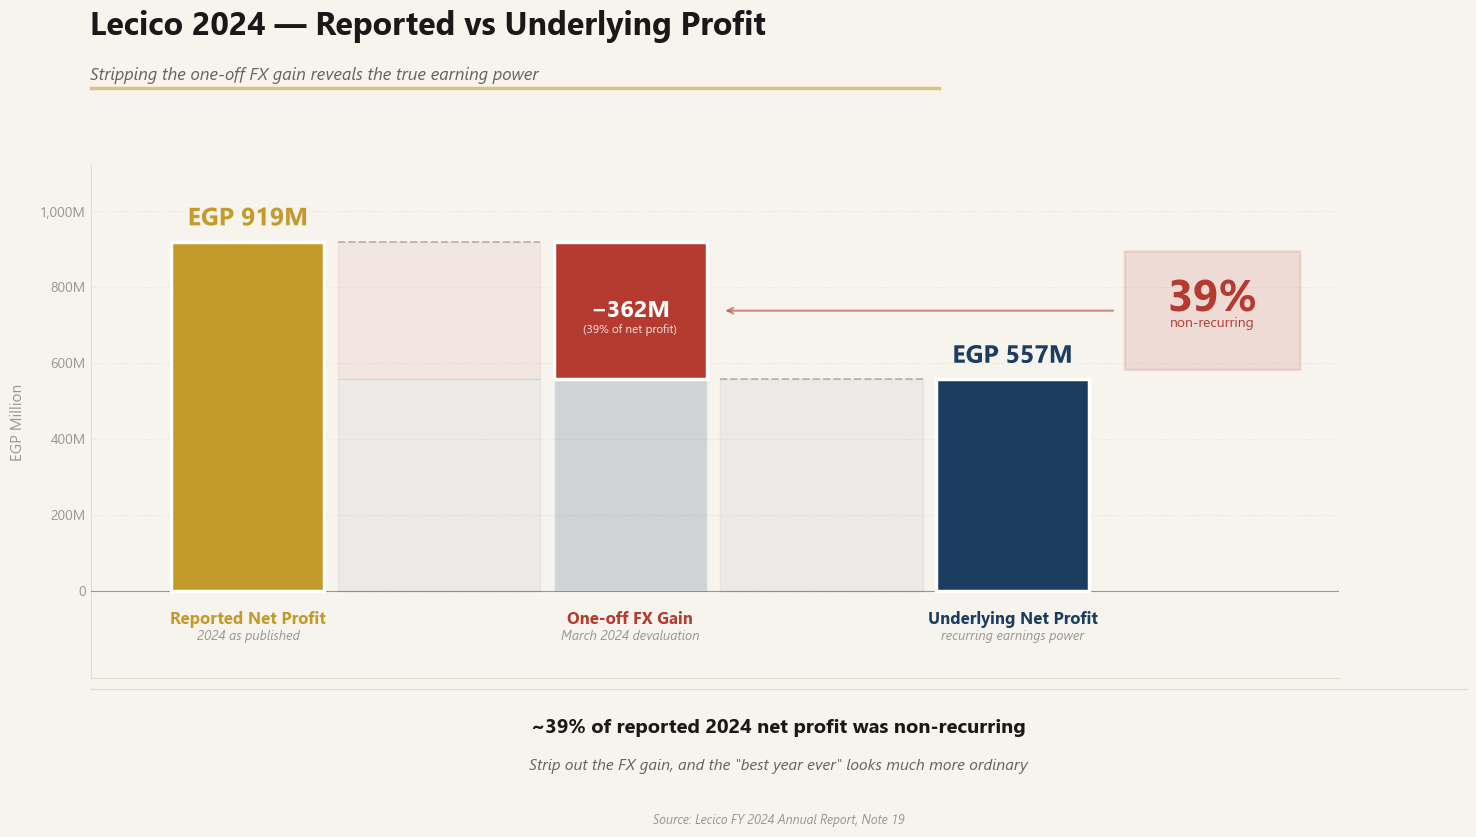

In [16]:
# ── DATA ──────────────────────────────────────────────────────────────────────
reported   = 919
fx_gain    = 362
underlying = 557
pct = round(fx_gain / reported * 100)   # 39%

# ── COLORS ────────────────────────────────────────────────────────────────────
GOLD  = '#C49A2A'
NAVY  = '#1B3D5F'
ALERT = '#B53A30'
INK   = '#1A1818'
SOFT  = '#686260'
MUTED = '#9A9590'
RULE  = '#E2DDD4'
BG    = '#F7F4EE'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9), facecolor=BG)
ax  = fig.add_axes([0.07, 0.22, 0.78, 0.57])
ax.set_facecolor(BG)

positions = [0, 1.7, 3.4]
W  = 0.68
G  = 0.06   # gap between bar edge and bridge fill

# ── BARS ──────────────────────────────────────────────────────────────────────
# Bar 1 — Reported (gold)
ax.bar(positions[0], reported, width=W, color=GOLD,
       edgecolor='white', linewidth=2.5, zorder=5)

# Bar 2 — Ghost underlying (shows what remains)
ax.bar(positions[1], underlying, width=W, color=NAVY,
       edgecolor='white', linewidth=2.5, zorder=4, alpha=0.18)
# Bar 2 — Floating FX gain on top
ax.bar(positions[1], fx_gain, bottom=underlying, width=W, color=ALERT,
       edgecolor='white', linewidth=2.5, zorder=5)

# Bar 3 — Underlying (navy)
ax.bar(positions[2], underlying, width=W, color=NAVY,
       edgecolor='white', linewidth=2.5, zorder=5)

# ── WATERFALL BRIDGE FILLS ────────────────────────────────────────────────────
def bridge(x0, x1, y_bot, y_top, color, alpha):
    ax.fill([x0+W/2+G, x1-W/2-G, x1-W/2-G, x0+W/2+G],
            [y_bot, y_bot, y_top, y_top],
            color=color, alpha=alpha, zorder=2)

bridge(positions[0], positions[1], underlying, reported, ALERT, 0.07)   # red zone
bridge(positions[0], positions[1], 0, underlying, NAVY,  0.05)          # blue zone
bridge(positions[1], positions[2], 0, underlying, NAVY,  0.05)          # blue zone

# ── CONNECTOR LINES ───────────────────────────────────────────────────────────
ax.plot([positions[0]+W/2+G, positions[1]-W/2-G], [reported, reported],
        '--', color=MUTED, lw=1.4, zorder=3, alpha=0.6)
ax.plot([positions[1]+W/2+G, positions[2]-W/2-G], [underlying, underlying],
        '--', color=MUTED, lw=1.4, zorder=3, alpha=0.6)

# ── VALUE LABELS ──────────────────────────────────────────────────────────────
stroke = [pe.withStroke(linewidth=4, foreground=BG)]

ax.text(positions[0], reported + 28, f'EGP {reported:,}M',
        ha='center', va='bottom', fontsize=18, fontweight='bold',
        color=GOLD, path_effects=stroke, zorder=7)

ax.text(positions[1], underlying + fx_gain/2, f'−{fx_gain}M',
        ha='center', va='center', fontsize=17, fontweight='bold',
        color='white', zorder=7)
ax.text(positions[1], underlying + fx_gain/2 - 50,
        f'({pct}% of net profit)',
        ha='center', va='center', fontsize=8.5,
        color='white', zorder=7, alpha=0.85)

ax.text(positions[2], underlying + 28, f'EGP {underlying:,}M',
        ha='center', va='bottom', fontsize=18, fontweight='bold',
        color=NAVY, path_effects=stroke, zorder=7)

# ── BAR LABELS BELOW ──────────────────────────────────────────────────────────
for pos, (bold_lbl, italic_lbl), col in zip(
    positions,
    [('Reported Net Profit',  '2024 as published'),
     ('One-off FX Gain',      'March 2024 devaluation'),
     ('Underlying Net Profit', 'recurring earnings power')],
    [GOLD, ALERT, NAVY]
):
    ax.text(pos, -52,  bold_lbl,   ha='center', va='top',
            fontsize=12, fontweight='bold', color=col)
    ax.text(pos, -102, italic_lbl, ha='center', va='top',
            fontsize=9.5, color=MUTED, style='italic')

# ── CALLOUT BADGE (rounded rect, right side) ──────────────────────────────────
bx, by = 3.92, underlying + 25
bw, bh = 0.74, fx_gain - 50
badge_cx = bx + bw / 2
badge_cy = by + bh / 2

badge = mpatches.FancyBboxPatch(
    (bx, by), bw, bh,
    boxstyle="round,pad=0.02",
    facecolor=ALERT, edgecolor=ALERT,
    alpha=0.13, linewidth=1.8, zorder=2
)
ax.add_patch(badge)

ax.text(badge_cx, badge_cy + 28, f'{pct}%',
        ha='center', va='center', fontsize=32,
        fontweight='bold', color=ALERT, zorder=8)
ax.text(badge_cx, badge_cy - 34, 'non-recurring',
        ha='center', va='center', fontsize=10,
        color=ALERT, zorder=8)

ax.annotate('',
    xy=(positions[1]+W/2+0.07, underlying + fx_gain/2),
    xytext=(bx - 0.06, underlying + fx_gain/2),
    arrowprops=dict(arrowstyle='->', color=ALERT, lw=1.6, alpha=0.55))

# ── AXIS STYLING ──────────────────────────────────────────────────────────────
ax.set_xlim(-0.7, 4.85)
ax.set_ylim(-230, reported * 1.22)
ax.set_xticks([])
ax.set_yticks([0, 200, 400, 600, 800, 1000])
ax.set_yticklabels(['0', '200M', '400M', '600M', '800M', '1,000M'],
                   color=MUTED, fontsize=10)
ax.set_ylabel('EGP Million', color=MUTED, fontsize=11, labelpad=10)

for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.axhline(0, color=INK, lw=0.8, alpha=0.4, zorder=4)

# ── TITLE ─────────────────────────────────────────────────────────────────────
fig.text(0.07, 0.935, "Lecico 2024 — Reported vs Underlying Profit",
         fontsize=23, fontweight='bold', color=INK)

# Gold accent line under title
fig.add_artist(plt.Line2D(
    [0.07, 0.60], [0.876, 0.876],
    transform=fig.transFigure, color=GOLD, linewidth=2.5, alpha=0.55
))
fig.text(0.07, 0.885,
         'Stripping the one-off FX gain reveals the true earning power',
         fontsize=12.5, color=SOFT, style='italic')

# ── FOOTER ────────────────────────────────────────────────────────────────────
fig.add_artist(plt.Line2D(
    [0.07, 0.93], [0.208, 0.208],
    transform=fig.transFigure, color=RULE, linewidth=1
))
fig.text(0.50, 0.160,
         f'~{pct}% of reported 2024 net profit was non-recurring',
         ha='center', fontsize=14.5, fontweight='bold', color=INK)
fig.text(0.50, 0.118,
         'Strip out the FX gain, and the "best year ever" looks much more ordinary',
         ha='center', fontsize=11.5, color=SOFT, style='italic')
fig.text(0.50, 0.058,
         'Source: Lecico FY 2024 Annual Report, Note 19',
         ha='center', fontsize=9, color=MUTED, style='italic')

plt.savefig('lecico_profit_chart.png', dpi=200,
            bbox_inches='tight', facecolor=BG)
plt.show()


### تحليل بنود التكاليف

لفهم الضغط على هوامش الربح، يُتتبَّع مسار الإيراد من اللحظة التي يدخل فيها كمبيعات وحتى تحوّله إلى صافي ربح.

**يمرّ كل 100 جنيه من الإيراد بخمس "بوّابات" قبل تحوّله إلى ربح صافٍ. تكشف الرسمة التالية حصة كل بوّابة من الإيراد:**

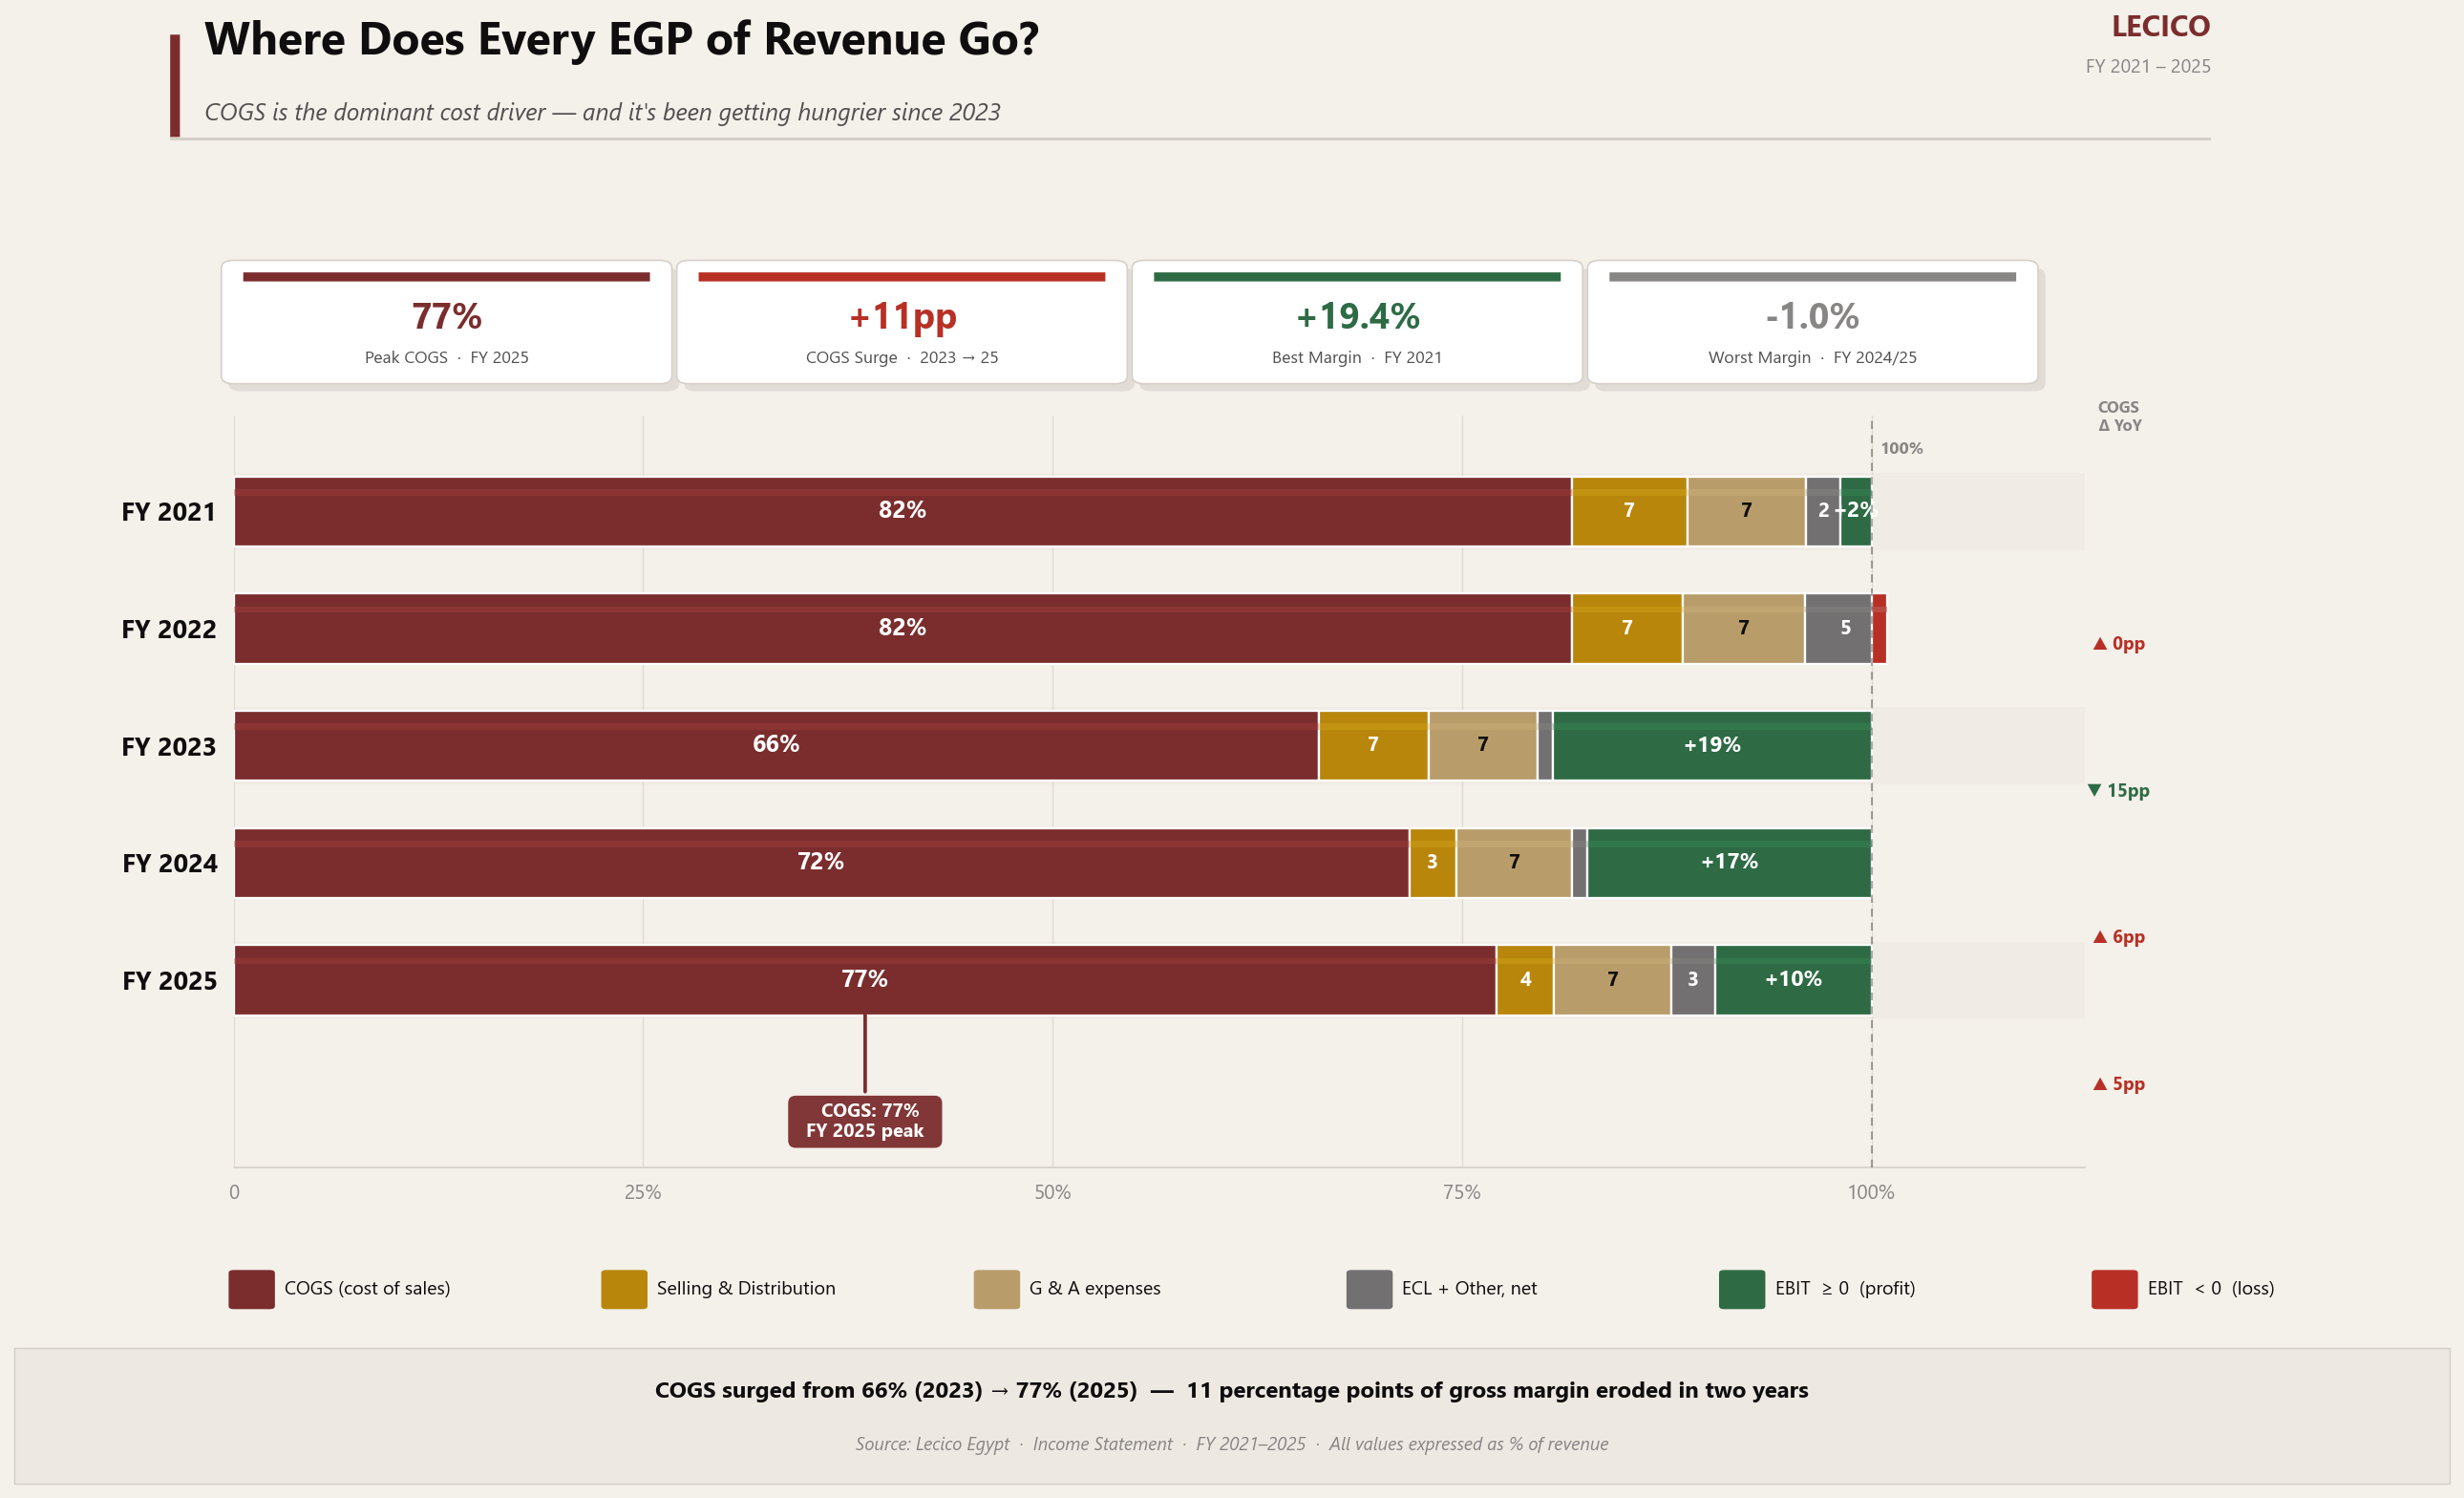


  Revenue cost breakdown (% of revenue)
  Year        COGS    Sell     G&A   Other     EBIT
  ────────────────────────────────────────────────────
  2021       81.7%    7.0%    7.2%    2.1%    +1.9%
  2022       81.7%    6.8%    7.5%    5.0%    -1.0%
  2023       66.3%    6.7%    6.7%    0.9%   +19.4%
  2024       71.8%    2.9%    7.0%    1.0%   +17.3%
  2025       77.1%    3.5%    7.1%    2.7%    +9.5%


In [17]:
# ── DATA ──────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

df      = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
fy_cols = [6, 11, 16, 21, 26]
years   = [2021, 2022, 2023, 2024, 2025]
n       = len(years)

revenue = np.array([df.iloc[5,  c] for c in fy_cols])
cogs    = np.array([abs(df.iloc[6,  c]) for c in fy_cols])
selling = np.array([abs(df.iloc[11, c]) for c in fy_cols])
ga      = np.array([abs(df.iloc[12, c]) for c in fy_cols])
ecl     = np.array([abs(df.iloc[13, c]) if pd.notna(df.iloc[13, c]) else 0 for c in fy_cols])
oth_exp = np.array([abs(df.iloc[14, c]) if pd.notna(df.iloc[14, c]) else 0 for c in fy_cols])
oth_inc = np.array([df.iloc[10, c]      if pd.notna(df.iloc[10, c]) else 0 for c in fy_cols])
ebit    = np.array([df.iloc[15, c] for c in fy_cols])

cogs_pct    = cogs    / revenue * 100
selling_pct = selling / revenue * 100
ga_pct      = ga      / revenue * 100
other_pct   = (ecl + oth_exp - oth_inc) / revenue * 100
ebit_pct    = ebit    / revenue * 100

# ── PALETTE ───────────────────────────────────────────────────────────────────
C = dict(
    cogs='#7B2D2D', cogs_hi='#A84040',
    sell='#B8860B', sell_hi='#D4A820',
    ga='#B89C6A',   ga_hi='#CEB47E',
    other='#727070',other_hi='#8E8A88',
    epos='#2E6B45', epos_hi='#3D8F5C',
    eneg='#B83025', eneg_hi='#D44035',
    ink='#0F0D0D',  soft='#525050',
    muted='#888585',rule='#D5D0C8',
    bg='#F4F0EA',   card='#EDE9E2',
    white='#FFFFFF',
)

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif'], 'figure.dpi': 150})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 10.5), facecolor=C['bg'])
ax  = fig.add_axes([0.09, 0.21, 0.76, 0.50])
ax.set_facecolor(C['bg'])

y_pos = np.arange(n)[::-1]
H = 0.60

# ── ROW BANDS ─────────────────────────────────────────────────────────────────
for k, yp in enumerate(y_pos):
    if k % 2 == 0:
        ax.axhspan(yp - H/2 - 0.03, yp + H/2 + 0.03,
                   color=C['card'], alpha=0.55, linewidth=0, zorder=0)

# ── BAR HELPER ────────────────────────────────────────────────────────────────
def bar_seg(ax, xs, w, yp, base, hi, label=None, fs=11, tc='white'):
    if w <= 0: return
    ax.barh(yp, w, height=H, left=xs, color=base, edgecolor=C['white'], linewidth=1.1, zorder=3)
    ax.barh(yp + H*0.27, w, height=H*0.09, left=xs, color=hi, alpha=0.38, zorder=4, edgecolor='none')
    if label and w > 1.8:
        ax.text(xs + w/2, yp, label, ha='center', va='center',
                fontsize=fs, color=tc, fontweight='bold', zorder=5)

left = np.zeros(n)

for i in range(n):
    bar_seg(ax, left[i], cogs_pct[i], y_pos[i], C['cogs'], C['cogs_hi'], f'{cogs_pct[i]:.0f}%', 12)
left += cogs_pct

for i in range(n):
    lbl = f'{selling_pct[i]:.0f}' if selling_pct[i] > 2 else None
    bar_seg(ax, left[i], selling_pct[i], y_pos[i], C['sell'], C['sell_hi'], lbl, 10)
left += selling_pct

for i in range(n):
    lbl = f'{ga_pct[i]:.0f}' if ga_pct[i] > 2 else None
    bar_seg(ax, left[i], ga_pct[i], y_pos[i], C['ga'], C['ga_hi'], lbl, 10, C['ink'])
left += ga_pct

for i in range(n):
    lbl = f'{other_pct[i]:.0f}' if other_pct[i] > 2 else None
    bar_seg(ax, left[i], other_pct[i], y_pos[i], C['other'], C['other_hi'], lbl, 10)
left += other_pct

for i, e in enumerate(ebit_pct):
    bc = C['epos'] if e >= 0 else C['eneg']
    hc = C['epos_hi'] if e >= 0 else C['eneg_hi']
    w  = abs(e)
    xs = left[i] if e >= 0 else left[i] - w
    bar_seg(ax, xs, w, y_pos[i], bc, hc, f'{e:+.0f}%', 11)

# ── 100% LINE ─────────────────────────────────────────────────────────────────
ax.axvline(100, color=C['ink'], lw=1.0, linestyle=(0,(4,3)), alpha=0.35, zorder=10)
ax.text(100.5, n-0.40, '100%', ha='left', va='top', fontsize=8.5, color=C['muted'], fontweight='bold')

# ── CALLOUT ───────────────────────────────────────────────────────────────────
ax.annotate(
    f"  COGS: {cogs_pct[-1]:.0f}%\n  FY 2025 peak  ",
    xy=(cogs_pct[-1]*0.50, y_pos[-1]), xytext=(cogs_pct[-1]*0.50, y_pos[-1]-1.05),
    ha='center', va='top', fontsize=9.5, color=C['white'], fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=C['cogs'], lw=1.8),
    bbox=dict(boxstyle='round,pad=0.40', facecolor=C['cogs'], edgecolor='none', alpha=0.95),
    clip_on=False, zorder=20,
)

# ── YoY COGS Δ ────────────────────────────────────────────────────────────────
dx = 0.864
fig.text(dx, 0.697, 'COGS\n Δ YoY', ha='center', va='bottom', fontsize=8, color=C['muted'], fontweight='bold')
for i in range(n):
    pt = ax.transData.transform([0, y_pos[i]])
    fy = fig.transFigure.inverted().transform(pt)[1]
    if i == 0: continue
    delta = cogs_pct[i] - cogs_pct[i-1]
    sym   = '▲' if delta > 0 else '▼'
    clr   = C['eneg'] if delta > 0 else C['epos']
    fig.text(dx, fy, f'{sym} {abs(delta):.0f}pp', ha='center', va='center', fontsize=9, color=clr, fontweight='bold')

# ── AXES ──────────────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels([f'FY {y}' for y in years], fontsize=13, fontweight='bold', color=C['ink'])
ax.set_xlim(0, 113)
ax.set_ylim(-1.6, n-0.18)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25%', '50%', '75%', '100%'], color=C['muted'], fontsize=10)
ax.tick_params(length=0, pad=8)
for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color(C['rule'])
ax.grid(axis='x', color=C['rule'], lw=0.6, alpha=0.70, zorder=1)

# ── KPI CARDS ─────────────────────────────────────────────────────────────────
kpis = [
    ('Peak COGS',    f"{cogs_pct[-1]:.0f}%",                  'FY 2025',    C['cogs']),
    ('COGS Surge',   f"+{cogs_pct[-1]-cogs_pct[2]:.0f}pp",    '2023 → 25',  C['eneg']),
    ('Best Margin',  f"{max(ebit_pct):+.1f}%",                 'FY 2021',    C['epos']),
    ('Worst Margin', f"{min(ebit_pct):+.1f}%",                 'FY 2024/25', C['muted']),
]
CW, CH, GAP, CY = 0.175, 0.072, 0.012, 0.736
for idx, (title, val, note, col) in enumerate(kpis):
    cx = 0.09 + idx * (CW + GAP)
    fig.add_artist(FancyBboxPatch((cx+0.003, CY-0.005), CW, CH, boxstyle='round,pad=0.005',
        transform=fig.transFigure, facecolor='#B8B2AB', edgecolor='none', alpha=0.30, zorder=3))
    fig.add_artist(FancyBboxPatch((cx, CY), CW, CH, boxstyle='round,pad=0.005',
        transform=fig.transFigure, facecolor=C['white'], edgecolor=C['rule'], linewidth=0.8, zorder=4))
    fig.add_artist(FancyBboxPatch((cx+0.004, CY+CH-0.009), CW-0.008, 0.006, boxstyle='round,pad=0',
        transform=fig.transFigure, facecolor=col, edgecolor='none', zorder=5))
    fig.text(cx+CW/2, CY+CH*0.53, val, ha='center', va='center', fontsize=18,
             fontweight='bold', color=col, transform=fig.transFigure, zorder=6)
    fig.text(cx+CW/2, CY+CH*0.16, f'{title}  ·  {note}', ha='center', va='center',
             fontsize=8.5, color=C['soft'], transform=fig.transFigure, zorder=6)

# ── LEGEND ────────────────────────────────────────────────────────────────────
legend = [
    ('COGS (cost of sales)', C['cogs']), ('Selling & Distribution', C['sell']),
    ('G & A expenses', C['ga']),         ('ECL + Other, net', C['other']),
    ('EBIT  ≥ 0  (profit)', C['epos']),  ('EBIT  < 0  (loss)', C['eneg']),
]
for idx, (lbl, col) in enumerate(legend):
    lx = 0.09 + idx * 0.153
    fig.add_artist(FancyBboxPatch((lx, 0.118), 0.015, 0.022, boxstyle='round,pad=0.002',
        transform=fig.transFigure, facecolor=col, edgecolor='none', zorder=5))
    fig.text(lx+0.021, 0.129, lbl, fontsize=9.5, color=C['ink'], va='center',
             transform=fig.transFigure, zorder=6)

# ── TITLE ─────────────────────────────────────────────────────────────────────
fig.add_artist(FancyBboxPatch((0.064, 0.895), 0.004, 0.068, boxstyle='round,pad=0',
    transform=fig.transFigure, facecolor=C['cogs'], edgecolor='none', zorder=5))
fig.text(0.078, 0.950, 'Where Does Every EGP of Revenue Go?',
         fontsize=23, fontweight='bold', color=C['ink'], transform=fig.transFigure, zorder=6)
fig.text(0.078, 0.906, "COGS is the dominant cost driver — and it's been getting hungrier since 2023",
         fontsize=12, color=C['soft'], style='italic', transform=fig.transFigure, zorder=6)
fig.text(0.902, 0.962, 'LECICO', fontsize=15, fontweight='bold', color=C['cogs'],
         ha='right', transform=fig.transFigure, zorder=6)
fig.text(0.902, 0.938, 'FY 2021 – 2025', fontsize=9.5, color=C['muted'],
         ha='right', transform=fig.transFigure, zorder=6)
fig.add_artist(mpatches.FancyBboxPatch((0.064, 0.893), 0.838, 0.0015, boxstyle='square,pad=0',
    transform=fig.transFigure, facecolor=C['rule'], edgecolor='none', zorder=4))

# ── BOTTOM STRIP ──────────────────────────────────────────────────────────────
fig.add_artist(mpatches.FancyBboxPatch((0,0), 1, 0.090, boxstyle='square,pad=0',
    transform=fig.transFigure, facecolor=C['card'], edgecolor=C['rule'], linewidth=0.7, zorder=3))
fig.text(0.50, 0.057,
    f'COGS surged from {cogs_pct[2]:.0f}% (2023) → {cogs_pct[-1]:.0f}% (2025)'
    f'  —  {cogs_pct[-1]-cogs_pct[2]:.0f} percentage points of gross margin eroded in two years',
    ha='center', fontsize=11.5, fontweight='bold', color=C['ink'], transform=fig.transFigure, zorder=6)
fig.text(0.50, 0.022,
    'Source: Lecico Egypt  ·  Income Statement  ·  FY 2021–2025  ·  All values expressed as % of revenue',
    ha='center', fontsize=9, color=C['muted'], style='italic', transform=fig.transFigure, zorder=6)

plt.savefig('lecico_revenue_breakdown.png', dpi=180, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print(f"\n  Revenue cost breakdown (% of revenue)")
print(f"  {'Year':<8} {'COGS':>7} {'Sell':>7} {'G&A':>7} {'Other':>7} {'EBIT':>8}")
print("  " + "─" * 52)
for i, y in enumerate(years):
    print(f"  {y:<8} {cogs_pct[i]:>6.1f}% {selling_pct[i]:>6.1f}% {ga_pct[i]:>6.1f}%"
          f" {other_pct[i]:>6.1f}% {ebit_pct[i]:>+7.1f}%")


## المرحلة 5: Balance Sheet & Cash

في كثير من الشركات، لا يتحوّل الربح المُعلن إلى نقدية في البنك، بل يبقى محتجزاً في صورة مخزون أو ذمم مدينة. تنطبق هذه الحالة على ليسيكو.

تُعرف هذه الظاهرة بـ **Cash Conversion Problem** — الربح يظهر على القوائم المالية، إلا أنه لا يتحوّل إلى Cash Flow حقيقي. السبب الجوهري:

> **Working Capital Buildup:** السيولة محتجزة في المخزون والمدينين.

تستعرض الرسومات التالية:
- نمو المخزون والمدينين على مدار السنوات
- آلية تكوّن الـ Cash Trap
- كيفية تمويل الفجوة عبر التسهيلات الائتمانية (Credit Facilities)

يُركّز التحليل على المؤشر الأهم في هذا السياق: **Cash Conversion Cycle (CCC)**.

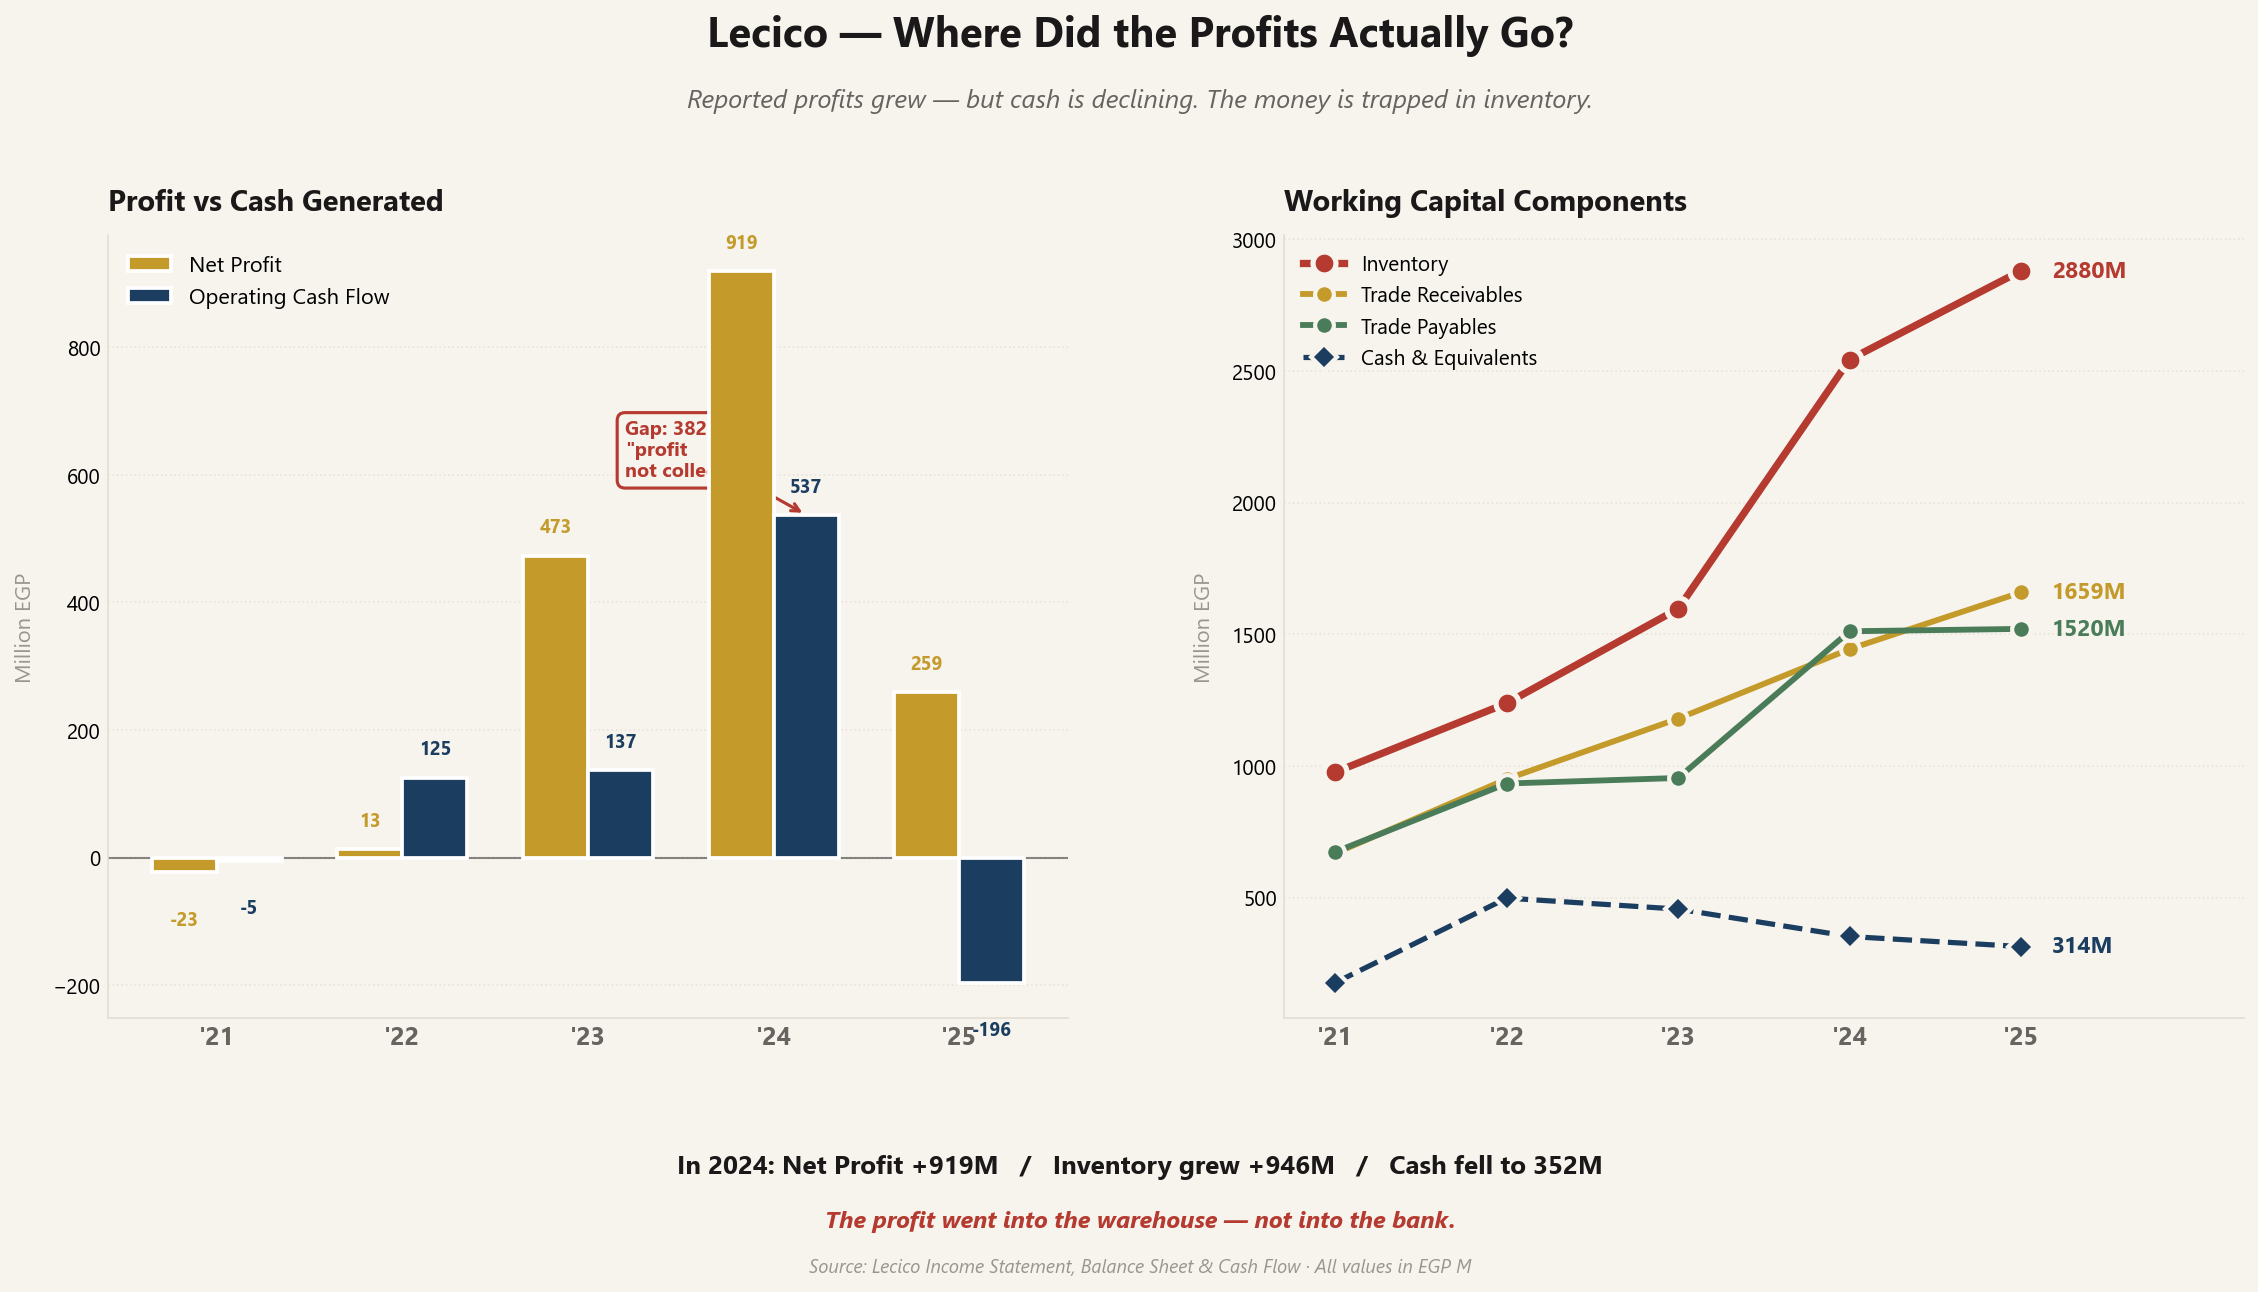


  Profit vs Cash:
  Year     Net Profit      Op. CF   Difference
  ────────────────────────────────────────────
  2021          -23M        -5M        -19M
  2022           13M       125M       -113M
  2023          473M       137M       +336M
  2024          919M       537M       +382M
  2025          259M      -196M       +455M

  Working Capital changes:
  Year      Inventory Δ   Receivables Δ   Payables Δ
  ────────────────────────────────────────────────────
  2021             +0M            +0M         +0M
  2022           +262M          +282M       +259M
  2023           +359M          +229M        +21M
  2024           +946M          +264M       +557M
  2025           +337M          +215M         +9M


In [18]:
# ── DATA ──────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH):
    FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

is_df = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
bs_df = pd.read_excel(FILE_PATH, sheet_name='Balance Sheet',    header=None)
cf_df = pd.read_excel(FILE_PATH, sheet_name='Cash Flow',        header=None)

FY_IS = [6, 11, 16, 21, 26]
FY_BS = [5,  9, 13, 17, 21]
FY_CF = [5, 10, 15, 20, 25]
years = [2021, 2022, 2023, 2024, 2025]
M = 1_000_000

net_profit = np.array([is_df.iloc[23, c] / M for c in FY_IS])
op_cf      = np.array([cf_df.iloc[38, c] / M for c in FY_CF])
inventory  = np.array([bs_df.iloc[13, c] / M for c in FY_BS])
receivable = np.array([bs_df.iloc[14, c] / M for c in FY_BS])
payables   = np.array([bs_df.iloc[41, c] / M for c in FY_BS])
cash       = np.array([bs_df.iloc[16, c] / M for c in FY_BS])

inv_change = np.diff(inventory, prepend=inventory[0])
rec_change = np.diff(receivable, prepend=receivable[0])
pay_change = np.diff(payables, prepend=payables[0])

# ── PALETTE ───────────────────────────────────────────────────────────────────
GOLD   = '#C49A2A'
NAVY   = '#1B3D5F'
ALERT  = '#B53A30'
GREEN  = '#4A7C59'
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
RULE   = '#E2DDD4'
BG     = '#F7F4EE'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

fig = plt.figure(figsize=(16, 9), facecolor=BG)

# ── PANEL 1: Profit vs Cash (left) ────────────────────────────────────────────
ax1 = fig.add_axes([0.07, 0.20, 0.40, 0.58])
ax1.set_facecolor(BG)

x = np.arange(len(years))
W = 0.35

b1 = ax1.bar(x - W/2, net_profit, W, color=GOLD,
             edgecolor='white', linewidth=1.8, label='Net Profit', zorder=5)
b2 = ax1.bar(x + W/2, op_cf, W, color=NAVY,
             edgecolor='white', linewidth=1.8, label='Operating Cash Flow', zorder=5)

for bar, v in zip(b1, net_profit):
    ax1.text(bar.get_x() + bar.get_width()/2,
             (v + 30) if v >= 0 else (v - 60),
             f'{v:.0f}', ha='center', va='bottom' if v >= 0 else 'top',
             fontsize=9, fontweight='bold', color=GOLD)

for bar, v in zip(b2, op_cf):
    ax1.text(bar.get_x() + bar.get_width()/2,
             (v + 30) if v >= 0 else (v - 60),
             f'{v:.0f}', ha='center', va='bottom' if v >= 0 else 'top',
             fontsize=9, fontweight='bold', color=NAVY)

ax1.axhline(0, color=INK, lw=1, alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f"'{str(y)[2:]}" for y in years],
                    fontsize=12, fontweight='bold', color=SOFT)
ax1.set_ylabel('Million EGP', fontsize=10.5, color=MUTED, labelpad=8)
ax1.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax1.set_axisbelow(True)
for sp in ['top', 'right']:
    ax1.spines[sp].set_visible(False)
ax1.spines['left'].set_color(RULE)
ax1.spines['bottom'].set_color(RULE)
ax1.tick_params(length=0)

ax1.legend(frameon=False, fontsize=10.5, loc='upper left')
ax1.set_title('Profit vs Cash Generated',
              fontsize=14, fontweight='bold', color=INK, loc='left', pad=12)

# Annotation: 2024 gap
gap = net_profit[3] - op_cf[3]
ax1.annotate(f'Gap: {gap:.0f}M\n"profit\nnot collected"',
             xy=(3 + W/2, op_cf[3]), xytext=(3 - 0.8, max(net_profit)*0.65),
             fontsize=9.5, color=ALERT, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=ALERT, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.4', facecolor=BG,
                       edgecolor=ALERT, linewidth=1.5))

# ── PANEL 2: Working Capital (right) ─────────────────────────────────────────
ax2 = fig.add_axes([0.56, 0.20, 0.40, 0.58])
ax2.set_facecolor(BG)

ax2.plot(x, inventory, color=ALERT, lw=3.5, marker='o', markersize=11,
         markerfacecolor=ALERT, markeredgecolor=BG, markeredgewidth=2.5,
         label='Inventory', zorder=10)

ax2.plot(x, receivable, color=GOLD, lw=2.8, marker='o', markersize=9,
         markerfacecolor=GOLD, markeredgecolor=BG, markeredgewidth=2,
         label='Trade Receivables', zorder=8)

ax2.plot(x, payables, color=GREEN, lw=2.8, marker='o', markersize=9,
         markerfacecolor=GREEN, markeredgecolor=BG, markeredgewidth=2,
         label='Trade Payables', zorder=8)

ax2.plot(x, cash, color=NAVY, lw=2.5, marker='D', markersize=9,
         markerfacecolor=NAVY, markeredgecolor=BG, markeredgewidth=2,
         linestyle='--', label='Cash & Equivalents', zorder=8)

# Endpoint labels
for series, color in [(inventory, ALERT), (receivable, GOLD),
                      (payables, GREEN), (cash, NAVY)]:
    ax2.text(4.18, series[-1], f'{series[-1]:.0f}M',
             fontsize=11, fontweight='bold', color=color, va='center')

ax2.set_xticks(x)
ax2.set_xticklabels([f"'{str(y)[2:]}" for y in years],
                    fontsize=12, fontweight='bold', color=SOFT)
ax2.set_ylabel('Million EGP', fontsize=10.5, color=MUTED, labelpad=8)
ax2.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax2.set_axisbelow(True)
ax2.set_xlim(-0.3, 5.3)
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color(RULE)
ax2.spines['bottom'].set_color(RULE)
ax2.tick_params(length=0)
ax2.legend(frameon=False, fontsize=10, loc='upper left')
ax2.set_title('Working Capital Components',
              fontsize=14, fontweight='bold', color=INK, loc='left', pad=12)

# ── TITLE ─────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.92, 'Lecico — Where Did the Profits Actually Go?',
         ha='center', fontsize=20, fontweight='bold', color=INK)

fig.text(0.5, 0.875,
         'Reported profits grew — but cash is declining. The money is trapped in inventory.',
         ha='center', fontsize=12.5, color=SOFT, style='italic')

# ── FOOTER ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.085,
         f'In 2024: Net Profit +{net_profit[3]:.0f}M   /   Inventory grew +{inv_change[3]:.0f}M   /   Cash fell to {cash[3]:.0f}M',
         ha='center', fontsize=12.5, fontweight='bold', color=INK)

fig.text(0.5, 0.045,
         'The profit went into the warehouse — not into the bank.',
         ha='center', fontsize=11.5, color=ALERT, style='italic', fontweight='bold')

fig.text(0.5, 0.012,
         'Source: Lecico Income Statement, Balance Sheet & Cash Flow · All values in EGP M',
         ha='center', fontsize=9, color=MUTED, style='italic')

plt.show()

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print(f"\n  Profit vs Cash:")
print(f"  {'Year':<7}{'Net Profit':>12}{'Op. CF':>12}{'Difference':>13}")
print("  " + "─"*44)
for i, y in enumerate(years):
    diff = net_profit[i] - op_cf[i]
    print(f"  {y:<7}{net_profit[i]:>10.0f}M{op_cf[i]:>10.0f}M{diff:>+11.0f}M")

print(f"\n  Working Capital changes:")
print(f"  {'Year':<7}{'Inventory Δ':>14}{'Receivables Δ':>16}{'Payables Δ':>13}")
print("  " + "─"*52)
for i, y in enumerate(years):
    print(f"  {y:<7}{inv_change[i]:>+12.0f}M{rec_change[i]:>+14.0f}M{pay_change[i]:>+11.0f}M")

### Cash Conversion Cycle (CCC)

يُمثّل الـ CCC مقياساً جوهرياً يُحدد **الفترة الزمنية التي تظل خلالها السيولة محتجزة قبل عودتها للشركة**:

```
CCC = DIO + DSO − DPO
```

| العنصر | المعنى |
|---|---|
| **DIO** (Days Inventory Outstanding) | عدد الأيام التي يبقى فيها المخزون قبل البيع |
| **DSO** (Days Sales Outstanding) | عدد الأيام بين البيع وتحصيل المبلغ من العميل |
| **DPO** (Days Payable Outstanding) | عدد الأيام التي تستغرقها الشركة في سداد مستحقات الموردين |

كلما ارتفع الـ CCC، زادت احتياجات الشركة من التمويل لـ working capital، ما يُترجَم إلى مزيد من الاقتراض.

## ملخص المراحل 1 إلى 5

تكوّنت صورة كاملة عن ليسيكو بعد خمس مراحل من التحليل. فيما يلي تلخيص للنتائج الجوهرية:

---

### الـ Business (المراحل 1-2)
- **المنتجات:** Sanitary Ware (64%) + Tiles (32%) + Brassware (4%)
- **الإنتاج:** 92% من المصانع داخل مصر
- **العملاء:** أكثر من 60% خارج مصر (UK 22%, OEM 16%, Europe 13%)
- **Natural FX Hedge:** تكاليف بالجنيه، إيرادات بالعملات الأجنبية

### الإيرادات (المرحلة 3)
- **نمو EGP:** +195% بين 2021-2025
- **نمو GBP:** -2% بالعملة الأصلية
- **الكميات:** ↓ -28% (انخفاض حقيقي في الـ Volume)
- **النتيجة:** النمو **وهمي** — أثر تعويم وتضخم وليس نمواً تشغيلياً

### الربحية (المرحلة 4)
- **Gross Margin:** بلغ ذروته 33.7% في 2023، ثم تراجع إلى 22.9% في 2025
- **EBIT Margin:** من ذروة 19.4% في 2023 إلى 9.5% في 2025
- **QoE Issue:** 40% من ربح 2024 كان FX gain غير متكرر

### التدفقات النقدية (المرحلة 5)
- **CCC:** ارتفع من 143 يوماً (2021) إلى 161 يوماً (2025)
- **Cash Trap:** المخزون ينمو بوتيرة أسرع من المبيعات
- **النقدية:** انخفضت من 498M (2022) إلى 314M (2025)

---

### الاستنتاج الرئيسي

> **تمتلك ليسيكو أصولاً حقيقية وفرنشايز قوياً في UK، إلا أن جودة النمو ضعيفة. الأرقام المُعلنة تُخفي تدهوراً تشغيلياً حقيقياً.**

تُشكّل هذه القاعدة الأساس الذي يُبنى عليه الـ Investment Thesis في المرحلة التالية.

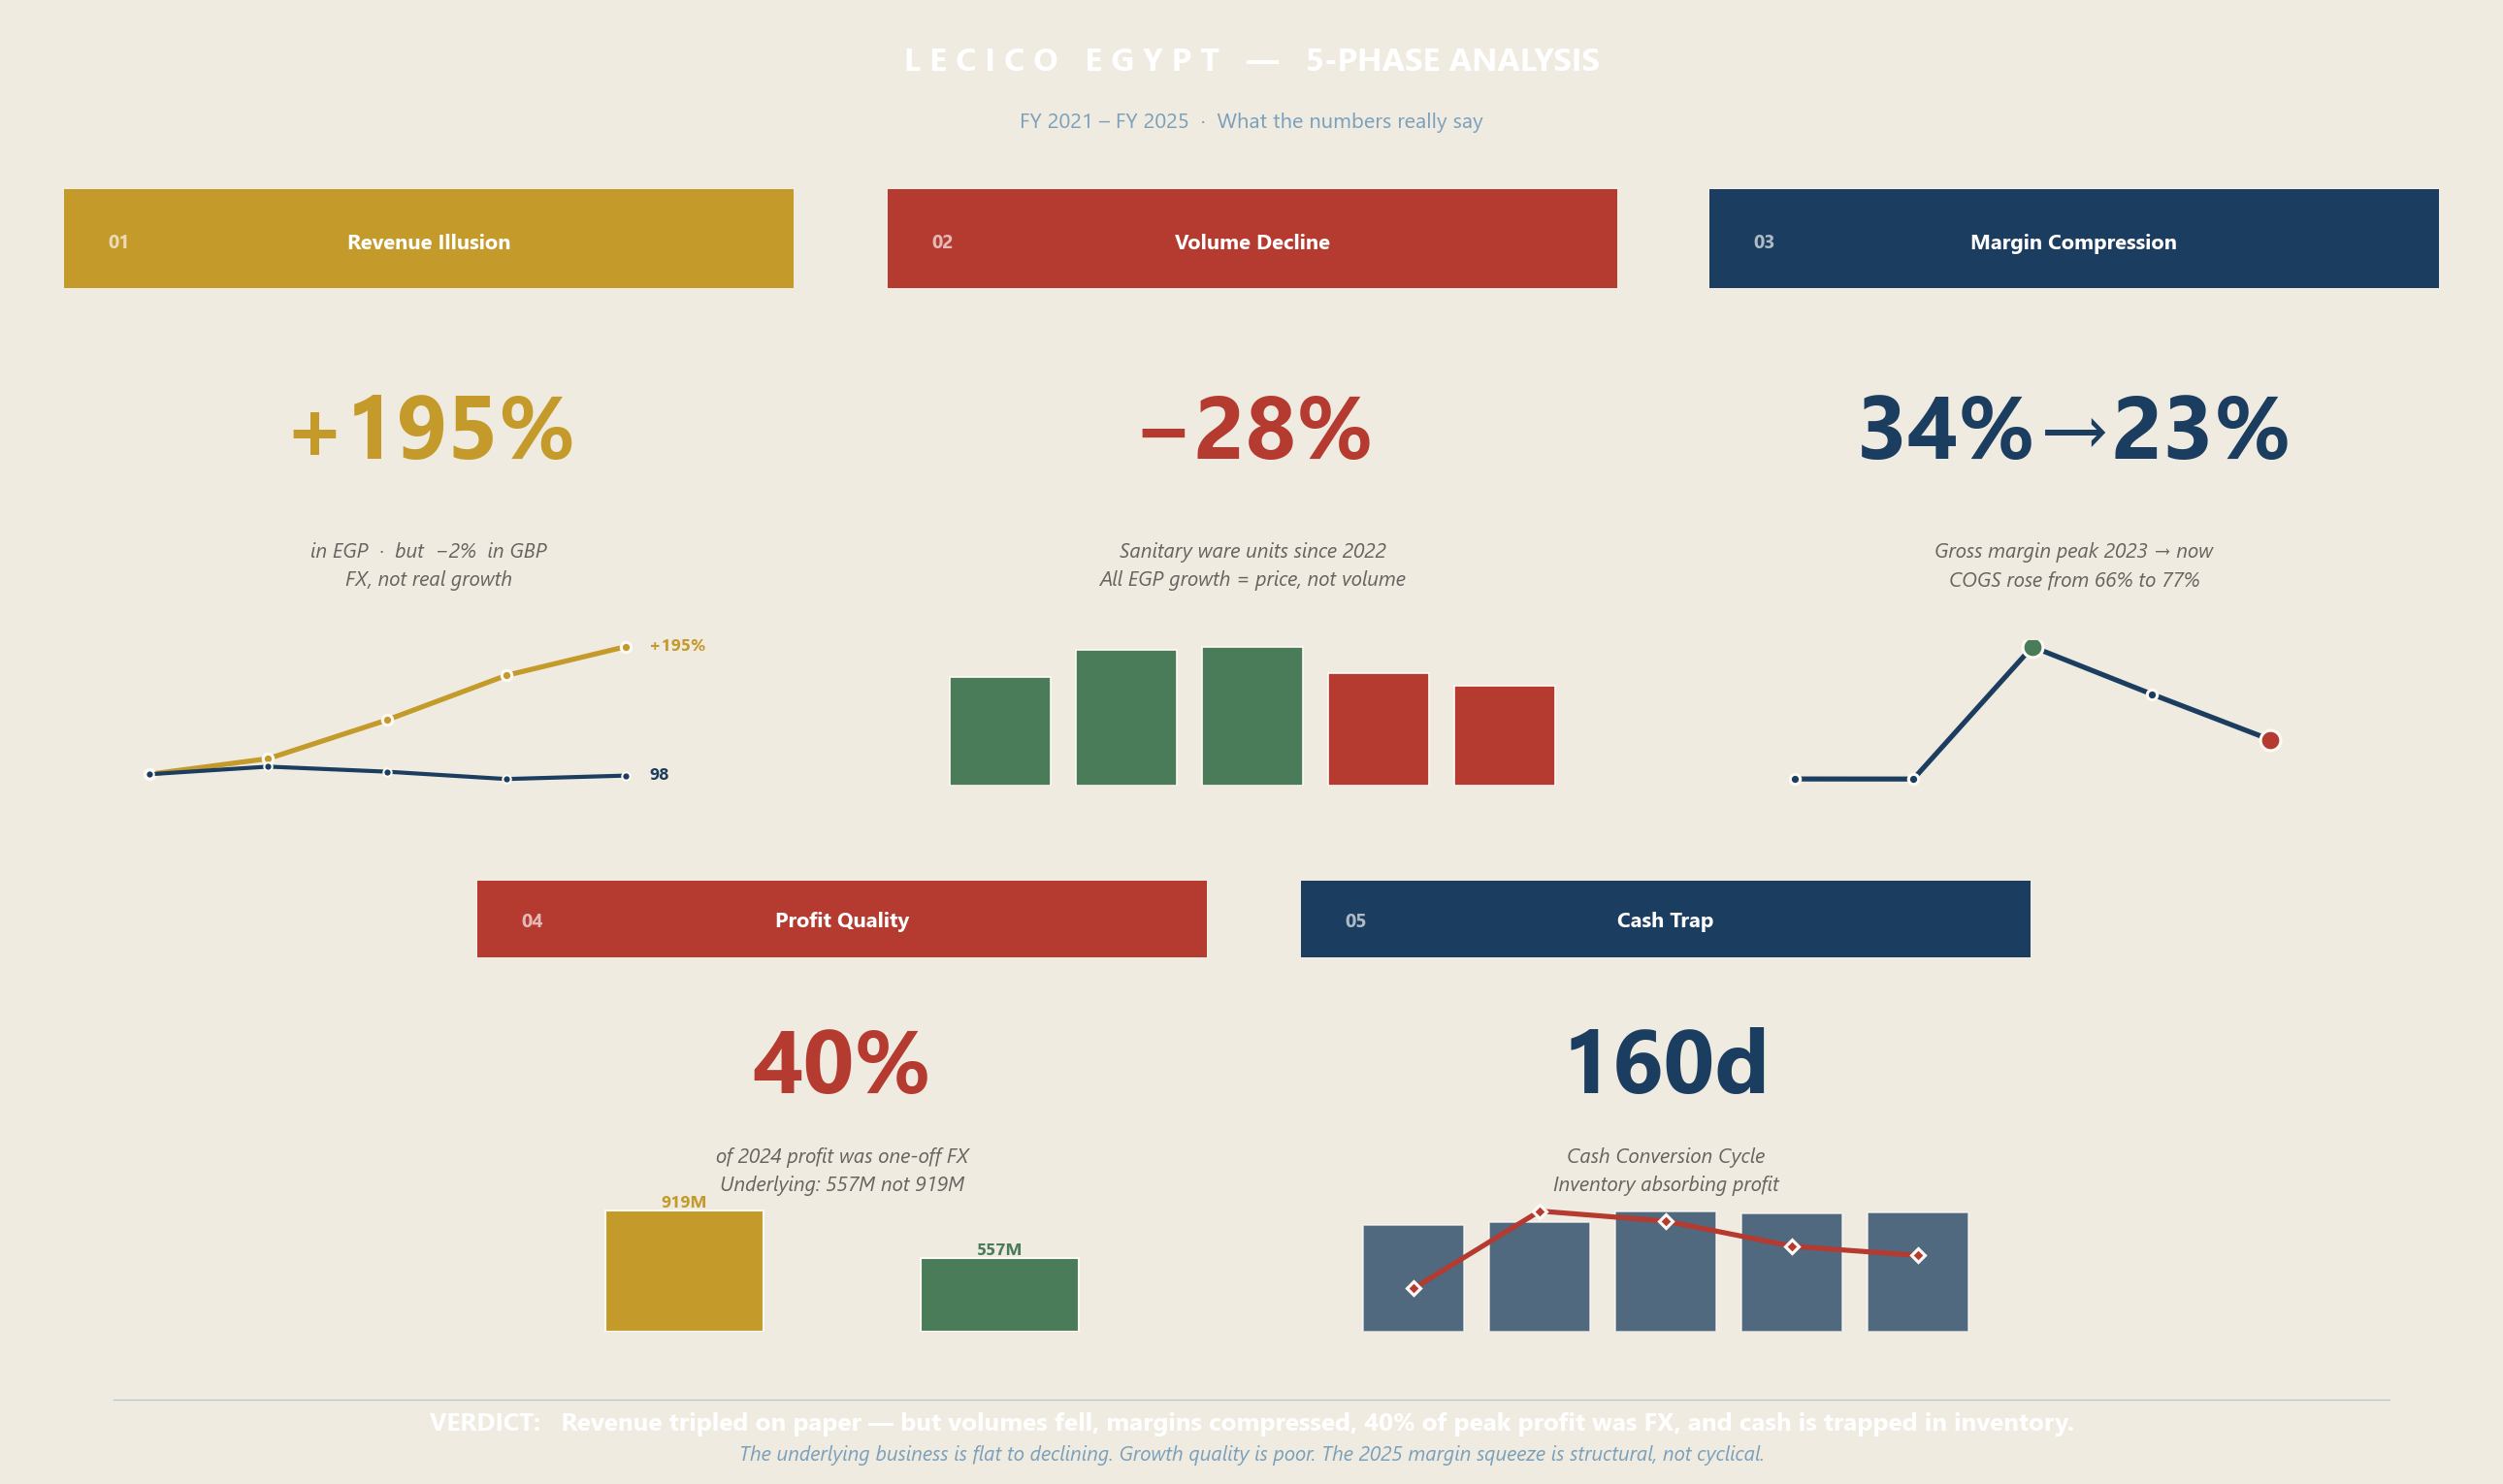


  Summary saved as: lecico_summary.png


In [19]:
# ── DATA ──────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\LCSW\Lecico_Dashboard_v3.xlsx'
if not os.path.exists(FILE_PATH): FILE_PATH = 'Lecico_Dashboard_v3.xlsx'

is_df = pd.read_excel(FILE_PATH, sheet_name='Income Statement', header=None)
bs_df = pd.read_excel(FILE_PATH, sheet_name='Balance Sheet',    header=None)

FY_IS = [6, 11, 16, 21, 26]
FY_BS = [5,  9, 13, 17, 21]
years = [2021, 2022, 2023, 2024, 2025]
M     = 1_000_000

revenue    = np.array([is_df.iloc[5,  c] / M for c in FY_IS])
cogs       = np.array([abs(is_df.iloc[6,  c]) / M for c in FY_IS])
gp         = np.array([is_df.iloc[7,  c] / M for c in FY_IS])
net        = np.array([is_df.iloc[23, c] / M for c in FY_IS])
inventory  = np.array([bs_df.iloc[13, c] / M for c in FY_BS])
receivable = np.array([bs_df.iloc[14, c] / M for c in FY_BS])
payables   = np.array([bs_df.iloc[41, c] / M for c in FY_BS])
cash       = np.array([bs_df.iloc[16, c] / M for c in FY_BS])

egp_per_gbp = [21.50, 23.85, 37.93, 58.35, 64.85]
rev_gbp     = np.array([r/fx for r, fx in zip(revenue, egp_per_gbp)])
sw_volume   = np.array([4011, 5010, 5102, 4155, 3685])

gm  = gp / revenue * 100
DIO = inventory  / cogs    * 365
DSO = receivable / revenue * 365
DPO = payables   / cogs    * 365
CCC = DIO + DSO - DPO

idx_egp = revenue / revenue[0] * 100
idx_gbp = rev_gbp / rev_gbp[0] * 100

# ── PALETTE ───────────────────────────────────────────────────────────────────
GOLD  = '#C49A2A'
NAVY  = '#1B3D5F'
ALERT = '#B53A30'
GREEN = '#4A7C59'
INK   = '#1A1818'
SOFT  = '#686260'
MUTED = '#9A9590'
BG    = '#F0EBE0'
CARD  = '#FDFAF5'
SKY   = '#7AA0BB'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 10), facecolor=BG)

# ── HEADER ────────────────────────────────────────────────────────────────────
ax_hdr = fig.add_axes([0, 0.905, 1, 0.095])
ax_hdr.set_facecolor(NAVY); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.65, 'L E C I C O   E G Y P T   —   5-PHASE ANALYSIS',
            ha='center', va='center', fontsize=16, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.22, 'FY 2021 – FY 2025  ·  What the numbers really say',
            ha='center', va='center', fontsize=10.5, color=SKY,
            transform=ax_hdr.transAxes)

# ── CARD BUILDER ──────────────────────────────────────────────────────────────
def card(fig, pos, color, num, headline, hero, sub):
    x, y, w, h = pos
    ax = fig.add_axes([x, y, w, h])
    ax.set_facecolor(CARD); ax.axis('off')
    # border
    for sp in ['top','bottom','left','right']:
        ax.spines[sp].set_visible(False)
    # top color strip
    ax.add_patch(patches.Rectangle(
        (0, 0.845), 1, 0.155, transform=ax.transAxes,
        facecolor=color, edgecolor='none', zorder=2))
    # phase number
    ax.text(0.06, 0.915, f'0{num}',
            ha='left', va='center', fontsize=9.5, color='white',
            fontweight='bold', transform=ax.transAxes, alpha=0.65, zorder=3)
    # headline
    ax.text(0.5, 0.915, headline,
            ha='center', va='center', fontsize=10.5, color='white',
            fontweight='bold', transform=ax.transAxes, zorder=3)
    # hero number
    ax.text(0.5, 0.615, hero,
            ha='center', va='center', fontsize=44, fontweight='bold',
            color=color, transform=ax.transAxes)
    # subtitle
    ax.text(0.5, 0.41, sub,
            ha='center', va='center', fontsize=10, color=SOFT,
            transform=ax.transAxes, style='italic', linespacing=1.5)
    return ax

# ── 5 CARDS ───────────────────────────────────────────────────────────────────
# Row 1: 3 cards
p1 = [0.020, 0.44, 0.295, 0.44]
p2 = [0.353, 0.44, 0.295, 0.44]
p3 = [0.685, 0.44, 0.295, 0.44]
# Row 2: 2 cards (centered)
p4 = [0.187, 0.065, 0.295, 0.34]
p5 = [0.520, 0.065, 0.295, 0.34]

card(fig, p1, GOLD,  1, 'Revenue Illusion',  '+195%',
     'in EGP  ·  but  −2%  in GBP\nFX, not real growth')

card(fig, p2, ALERT, 2, 'Volume Decline',    '−28%',
     'Sanitary ware units since 2022\nAll EGP growth = price, not volume')

card(fig, p3, NAVY,  3, 'Margin Compression','34%→23%',
     'Gross margin peak 2023 → now\nCOGS rose from 66% to 77%')

card(fig, p4, ALERT, 4, 'Profit Quality',    '40%',
     'of 2024 profit was one-off FX\nUnderlying: 557M not 919M')

card(fig, p5, NAVY,  5, 'Cash Trap',         '160d',
     'Cash Conversion Cycle\nInventory absorbing profit')

# ── MINI-CHARTS ───────────────────────────────────────────────────────────────
x5 = np.arange(5)

# Card 1: EGP vs GBP indexed lines
m1 = fig.add_axes([p1[0]+0.02, p1[1]+0.03, p1[2]-0.04, 0.10])
m1.set_facecolor(CARD); m1.axis('off')
m1.plot(x5, idx_egp, color=GOLD, lw=2.5, marker='o', markersize=5,
        markeredgecolor=CARD, markeredgewidth=1.5)
m1.plot(x5, idx_gbp, color=NAVY, lw=2, marker='o', markersize=4,
        markeredgecolor=CARD, markeredgewidth=1)
m1.text(4.2, idx_egp[-1], f'+{idx_egp[-1]-100:.0f}%',
        fontsize=8.5, color=GOLD, va='center', fontweight='bold')
m1.text(4.2, idx_gbp[-1], f'{idx_gbp[-1]:.0f}',
        fontsize=8.5, color=NAVY, va='center', fontweight='bold')
m1.set_xlim(-0.3, 5.0)

# Card 2: Volume bars (green when up, red when down)
m2 = fig.add_axes([p2[0]+0.02, p2[1]+0.03, p2[2]-0.04, 0.10])
m2.set_facecolor(CARD); m2.axis('off')
vol_clr = [GREEN, GREEN, GREEN, ALERT, ALERT]
m2.bar(x5, sw_volume, color=vol_clr, edgecolor=CARD, linewidth=0.8)
m2.set_xlim(-0.5, 4.5)

# Card 3: Gross margin line with peak marker
m3 = fig.add_axes([p3[0]+0.02, p3[1]+0.03, p3[2]-0.04, 0.10])
m3.set_facecolor(CARD); m3.axis('off')
m3.plot(x5, gm, color=NAVY, lw=2.5, marker='o', markersize=5,
        markeredgecolor=CARD, markeredgewidth=1.5)
peak = np.argmax(gm)
m3.scatter([peak], [gm[peak]], s=100, color=GREEN, zorder=6,
           edgecolors=CARD, linewidth=1.5)
m3.scatter([4], [gm[4]], s=100, color=ALERT, zorder=6,
           edgecolors=CARD, linewidth=1.5)
m3.set_xlim(-0.3, 5.0)

# Card 4: Reported vs Underlying 2024
m4 = fig.add_axes([p4[0]+0.02, p4[1]+0.03, p4[2]-0.04, 0.095])
m4.set_facecolor(CARD); m4.axis('off')
m4.bar([0, 1], [919, 557], color=[GOLD, GREEN], edgecolor=CARD,
       linewidth=1, width=0.5)
m4.text(0, 940, '919M', ha='center', fontsize=8.5, color=GOLD, fontweight='bold')
m4.text(1, 578, '557M', ha='center', fontsize=8.5, color=GREEN, fontweight='bold')
m4.set_xlim(-0.5, 1.5); m4.set_ylim(0, 1050)

# Card 5: CCC bars + cash line (normalized)
m5 = fig.add_axes([p5[0]+0.02, p5[1]+0.03, p5[2]-0.04, 0.095])
m5.set_facecolor(CARD); m5.axis('off')
ccc_norm  = CCC / max(CCC) * 100
cash_norm = cash / max(cash) * 100
m5.bar(x5, ccc_norm, color=NAVY, alpha=0.75, edgecolor=CARD, linewidth=0.8)
m5.plot(x5, cash_norm, color=ALERT, lw=2.5, marker='D', markersize=5,
        markeredgecolor=CARD, markeredgewidth=1.5)
m5.set_xlim(-0.5, 4.5); m5.set_ylim(0, 115)

# ── FOOTER ────────────────────────────────────────────────────────────────────
ax_ft = fig.add_axes([0, 0, 1, 0.06])
ax_ft.set_facecolor(NAVY); ax_ft.axis('off')
ax_ft.plot([0.04, 0.96], [0.80, 0.80], color=SKY, lw=0.6,
           transform=ax_ft.transAxes, alpha=0.5)
ax_ft.text(0.5, 0.52,
           'VERDICT:   Revenue tripled on paper — but volumes fell, margins compressed, '
           '40% of peak profit was FX, and cash is trapped in inventory.',
           ha='center', va='center', fontsize=12.5, color='white',
           fontweight='bold', transform=ax_ft.transAxes)
ax_ft.text(0.5, 0.16,
           'The underlying business is flat to declining. '
           'Growth quality is poor. The 2025 margin squeeze is structural, not cyclical.',
           ha='center', va='center', fontsize=10, color=SKY,
           transform=ax_ft.transAxes, style='italic')

plt.savefig('lecico_summary.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print("\n  Summary saved as: lecico_summary.png")

## المرحلة 6: Investment Thesis

### السؤال الجوهري

> **هل ليسيكو فرصة استثمارية، أم فخ قيمة (Value Trap)؟**

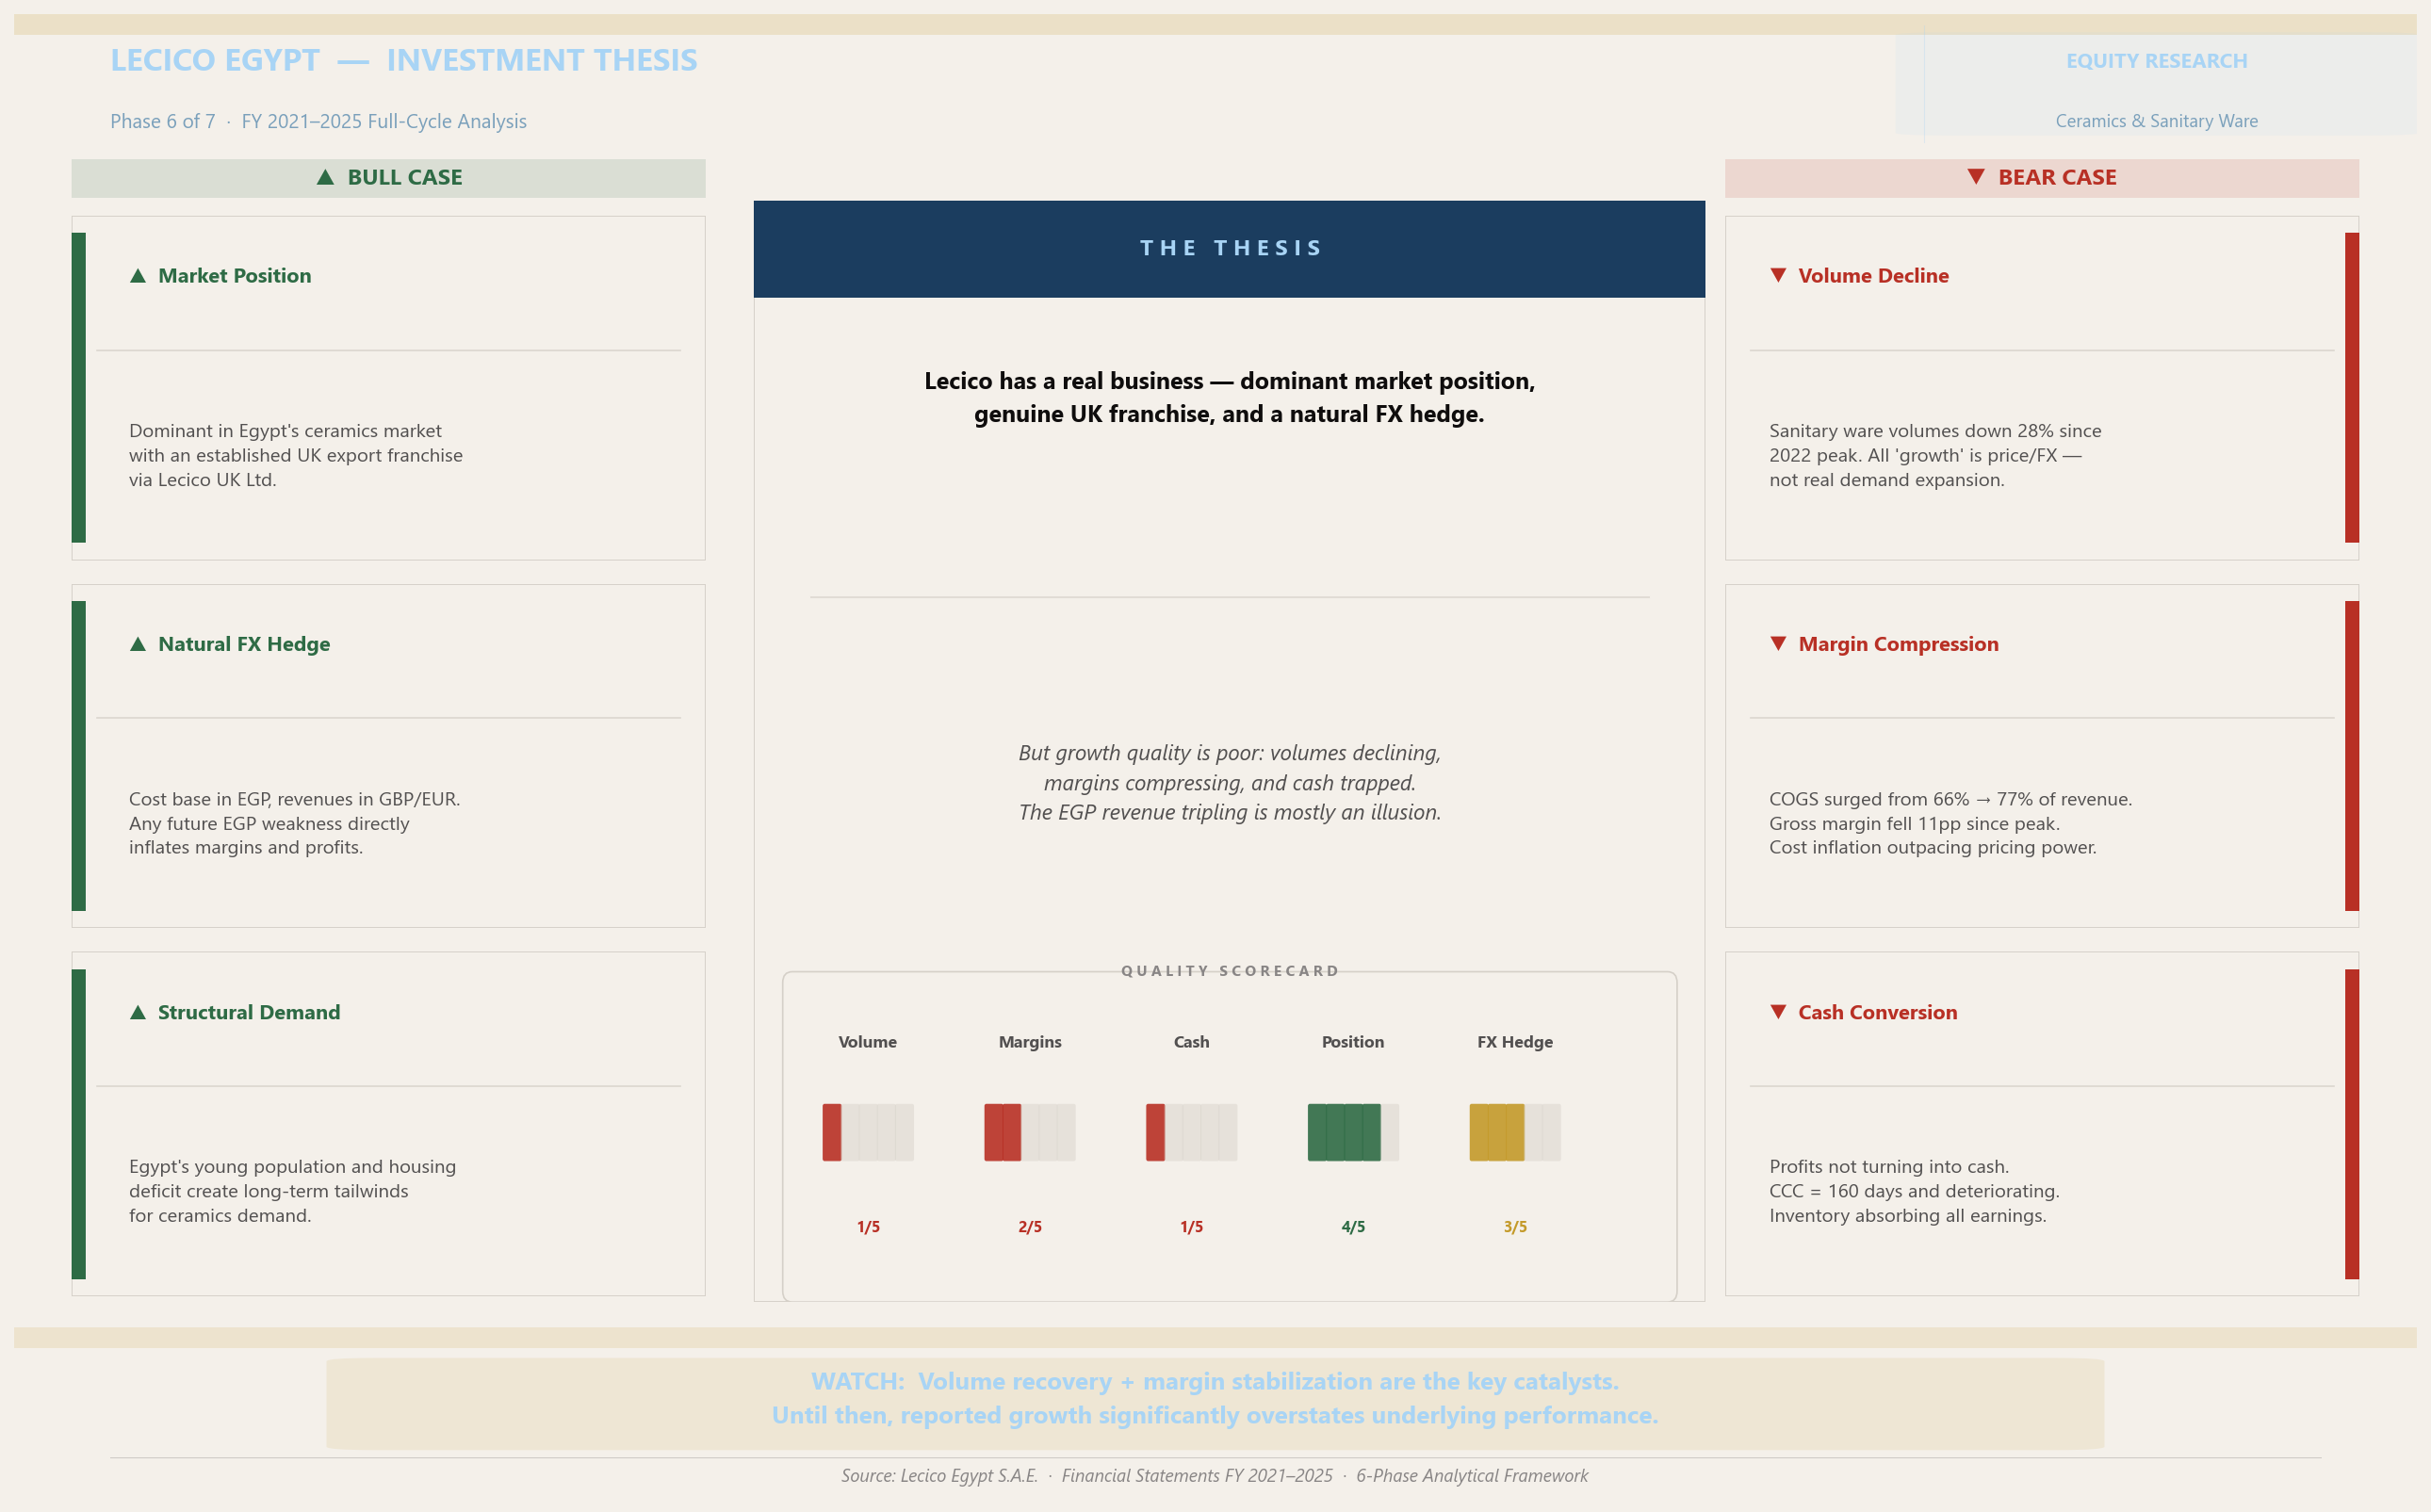


  Saved: lecico_thesis.png


In [20]:

C = dict(
    gold='#C49A2A', navy='#1B3D5F', alert='#B83025', green='#2E6B45',
    ink='#0F0D0D', soft='#525050', muted='#888585', rule='#D5D0C8',
    bg='#F4F0EA', card='#FEFCF8', sky='#7AA0BB', cream='#A8D4F5',
)
plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif'], 'figure.dpi': 150})

bulls = [
    ("Market Position",
     "Dominant in Egypt's ceramics market\n"
     "with an established UK export franchise\n"
     "via Lecico UK Ltd."),
    ("Natural FX Hedge",
     "Cost base in EGP, revenues in GBP/EUR.\n"
     "Any future EGP weakness directly\n"
     "inflates margins and profits."),
    ("Structural Demand",
     "Egypt's young population and housing\n"
     "deficit create long-term tailwinds\n"
     "for ceramics demand."),
]
bears = [
    ("Volume Decline",
     "Sanitary ware volumes down 28% since\n"
     "2022 peak. All 'growth' is price/FX —\n"
     "not real demand expansion."),
    ("Margin Compression",
     "COGS surged from 66% → 77% of revenue.\n"
     "Gross margin fell 11pp since peak.\n"
     "Cost inflation outpacing pricing power."),
    ("Cash Conversion",
     "Profits not turning into cash.\n"
     "CCC = 160 days and deteriorating.\n"
     "Inventory absorbing all earnings."),
]
thesis_strong = (
    "Lecico has a real business — dominant market position,\n"
    "genuine UK franchise, and a natural FX hedge."
)
thesis_weak = (
    "But growth quality is poor: volumes declining,\n"
    "margins compressing, and cash trapped.\n"
    "The EGP revenue tripling is mostly an illusion."
)
verdict = (
    "WATCH:  Volume recovery + margin stabilization are the key catalysts.\n"
    "Until then, reported growth significantly overstates underlying performance."
)

fig = plt.figure(figsize=(17, 10.5), facecolor=C['bg'])

# ── HEADER ────────────────────────────────────────────────────────────────────
ax_h = fig.add_axes([0, 0.906, 1, 0.094])
ax_h.set_facecolor(C['navy'])
ax_h.axis('off')

ax_h.add_patch(patches.Rectangle((0, 0.85), 1, 0.15,
    transform=ax_h.transAxes, facecolor=C['gold'], edgecolor='none', alpha=0.18))

ax_h.text(0.04, 0.65, 'LECICO EGYPT  —  INVESTMENT THESIS',
          ha='left', va='center', fontsize=16, color=C['cream'],
          fontweight='bold', transform=ax_h.transAxes)
ax_h.text(0.04, 0.22, 'Phase 6 of 7  ·  FY 2021–2025 Full-Cycle Analysis',
          ha='left', va='center', fontsize=10, color=C['sky'],
          transform=ax_h.transAxes)

ax_h.plot([0.795, 0.795], [0.08, 0.92],
          color=C['cream'], lw=0.5, alpha=0.30, transform=ax_h.transAxes)
ax_h.add_patch(FancyBboxPatch((0.803, 0.15), 0.178, 0.70,
    boxstyle='round,pad=0.02', transform=ax_h.transAxes,
    facecolor=C['cream'], edgecolor='none', alpha=0.10, zorder=3))
ax_h.text(0.892, 0.65, 'EQUITY RESEARCH',
          ha='center', va='center', fontsize=10.5, color=C['cream'],
          fontweight='bold', transform=ax_h.transAxes, zorder=4)
ax_h.text(0.892, 0.22, 'Ceramics & Sanitary Ware',
          ha='center', va='center', fontsize=9, color=C['sky'],
          transform=ax_h.transAxes, zorder=4)

# ── LAYOUT ────────────────────────────────────────────────────────────────────
COL_X_L, COL_X_R, COL_W = 0.024, 0.712, 0.264
CARD_H, GAP, TOP_Y      = 0.232, 0.016, 0.632
CTR_X  = COL_X_L + COL_W + 0.020
CTR_W  = COL_X_R - CTR_X - 0.008
CTR_Y, CTR_H, NAVY_F    = 0.132, 0.742, 0.088

# ── COLUMN BADGES ─────────────────────────────────────────────────────────────
for lbl, col, bx in [('▲  BULL CASE', C['green'], COL_X_L),
                      ('▼  BEAR CASE', C['alert'], COL_X_R)]:
    ax_b = fig.add_axes([bx, 0.876, COL_W, 0.026])
    ax_b.set_facecolor(C['bg'])
    ax_b.axis('off')
    ax_b.add_patch(patches.Rectangle((0, 0), 1, 1,
        transform=ax_b.transAxes, facecolor=col, edgecolor='none', alpha=0.13))
    ax_b.text(0.5, 0.5, lbl, ha='center', va='center',
              fontsize=11.5, color=col, fontweight='bold',
              transform=ax_b.transAxes, zorder=2)

# ── CARD HELPER ───────────────────────────────────────────────────────────────
def make_card(fy, title, body, color, side):
    fx   = COL_X_L if side == 'left' else COL_X_R
    icon = '▲' if side == 'left' else '▼'

    ax = fig.add_axes([fx, fy, COL_W, CARD_H])
    ax.set_facecolor(C['card'])
    ax.axis('off')

    ax.add_patch(patches.Rectangle((0, 0), 1, 1,
        transform=ax.transAxes, fill=False, edgecolor=C['rule'], linewidth=0.9))

    sw = 0.022
    sx = 0 if side == 'left' else 1 - sw
    ax.add_patch(patches.Rectangle((sx, 0.05), sw, 0.90,
        transform=ax.transAxes, facecolor=color, edgecolor='none', zorder=2))

    tx = 0.09 if side == 'left' else 0.07
    ax.text(tx, 0.82, f'{icon}  {title}',
            ha='left', va='center', fontsize=10.5, color=color,
            fontweight='bold', transform=ax.transAxes, zorder=3)
    ax.plot([0.04, 0.96], [0.61, 0.61],
            color=C['rule'], lw=0.8, transform=ax.transAxes, alpha=0.8, zorder=3)
    ax.text(tx, 0.30, body,
            ha='left', va='center', fontsize=9.8, color=C['soft'],
            transform=ax.transAxes, linespacing=1.55, zorder=3)

# ── DRAW CARDS ────────────────────────────────────────────────────────────────
for i, (title, body) in enumerate(bulls):
    make_card(TOP_Y - i*(CARD_H+GAP), title, body, C['green'], 'left')
for i, (title, body) in enumerate(bears):
    make_card(TOP_Y - i*(CARD_H+GAP), title, body, C['alert'], 'right')

# ── CENTER PANEL ──────────────────────────────────────────────────────────────
ax_c = fig.add_axes([CTR_X, CTR_Y, CTR_W, CTR_H])
ax_c.set_facecolor(C['card'])
ax_c.axis('off')

ax_c.add_patch(patches.Rectangle((0, 0), 1, 1,
    transform=ax_c.transAxes, fill=False, edgecolor=C['rule'], linewidth=0.9))

ax_c.add_patch(patches.Rectangle((0, 1-NAVY_F), 1, NAVY_F,
    transform=ax_c.transAxes, facecolor=C['navy'], edgecolor='none', zorder=2))
ax_c.text(0.5, 1 - NAVY_F/2, 'T H E   T H E S I S',
          ha='center', va='center', fontsize=11.5, color=C['cream'],
          fontweight='bold', transform=ax_c.transAxes, zorder=3)

ax_c.text(0.5, 0.82, thesis_strong,
          ha='center', va='center', fontsize=12, color=C['ink'],
          fontweight='bold', transform=ax_c.transAxes, linespacing=1.55, zorder=3)

ax_c.plot([0.06, 0.94], [0.64, 0.64],
          color=C['rule'], lw=1.0, transform=ax_c.transAxes, alpha=0.60, zorder=3)

ax_c.text(0.5, 0.47, thesis_weak,
          ha='center', va='center', fontsize=11, color=C['soft'],
          style='italic', transform=ax_c.transAxes, linespacing=1.55, zorder=3)

# ── QUALITY SCORECARD ─────────────────────────────────────────────────────────
ax_c.add_patch(FancyBboxPatch((0.04, 0.01), 0.92, 0.28,
    boxstyle='round,pad=0.01', transform=ax_c.transAxes,
    facecolor=C['bg'], edgecolor=C['rule'], linewidth=0.8, zorder=3))
ax_c.text(0.5, 0.300, 'Q U A L I T Y   S C O R E C A R D',
          ha='center', va='center', fontsize=7.5, color=C['muted'],
          fontweight='bold', transform=ax_c.transAxes, zorder=4)

metrics = [
    ('Volume',   1, C['alert']),
    ('Margins',  2, C['alert']),
    ('Cash',     1, C['alert']),
    ('Position', 4, C['green']),
    ('FX Hedge', 3, C['gold']),
]
LXS     = [0.12, 0.29, 0.46, 0.63, 0.80]
SW, SG  = 0.016, 0.003

for (lbl, score, col), lx in zip(metrics, LXS):
    ax_c.text(lx, 0.235, lbl, ha='center', va='center', fontsize=8.5,
              color=C['soft'], fontweight='bold',
              transform=ax_c.transAxes, zorder=4)
    BX0 = lx - (5*SW + 4*SG) / 2
    for s in range(5):
        ax_c.add_patch(FancyBboxPatch(
            (BX0 + s*(SW+SG), 0.130), SW, 0.048,
            boxstyle='round,pad=0.002', transform=ax_c.transAxes,
            facecolor=col if s < score else C['rule'], edgecolor='none',
            alpha=0.90 if s < score else 0.45, zorder=4))
    ax_c.text(lx, 0.068, f'{score}/5', ha='center', va='center',
              fontsize=8, color=col, fontweight='bold',
              transform=ax_c.transAxes, zorder=4)

# ── FOOTER ────────────────────────────────────────────────────────────────────
ax_ft = fig.add_axes([0, 0, 1, 0.115])
ax_ft.set_facecolor(C['ink'])
ax_ft.axis('off')

ax_ft.add_patch(patches.Rectangle((0, 0.88), 1, 0.12,
    transform=ax_ft.transAxes, facecolor=C['gold'], edgecolor='none', alpha=0.14))
ax_ft.add_patch(FancyBboxPatch((0.15, 0.30), 0.70, 0.50,
    boxstyle='round,pad=0.02', transform=ax_ft.transAxes,
    facecolor=C['gold'], edgecolor='none', alpha=0.11, zorder=2))

ax_ft.text(0.50, 0.57, verdict,
           ha='center', va='center', fontsize=12.5, color=C['cream'],
           fontweight='bold', transform=ax_ft.transAxes,
           linespacing=1.60, zorder=3)

ax_ft.plot([0.04, 0.96], [0.24, 0.24],
           color=C['muted'], lw=0.5, transform=ax_ft.transAxes, alpha=0.35)
ax_ft.text(0.50, 0.12,
           'Source: Lecico Egypt S.A.E.  ·  Financial Statements FY 2021–2025  ·  6-Phase Analytical Framework',
           ha='center', va='center', fontsize=9, color=C['muted'],
           style='italic', transform=ax_ft.transAxes)

plt.savefig('lecico_thesis.png', dpi=180, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("\n  Saved: lecico_thesis.png")


## المرحلة 7: Forecast Q2 2026

بعد اكتمال فهم الأداء التاريخي والوضع الراهن، تأتي الخطوة الأخيرة: **بناء نموذج تنبؤ بأرباح Q2 2026**.

يُبنى التنبؤ من أعلى الـ Income Statement إلى أسفله:

> Revenue  →  Gross Profit  →  EBIT  →  Net Profit

**تُبنى التوقعات على ثلاثة سيناريوهات لكل بند:**

1. **Bull Case** — السيناريو الأفضل (تحقق الافتراضات الإيجابية)
2. **Base Case** — السيناريو الأرجح (استمرار الـ trend الحالي)
3. **Bear Case** — السيناريو الأسوأ (تحقق الافتراضات السلبية)

## Revenue Expectations — توقعات الإيرادات

### المنهجية
يُؤخَذ Q2 2025 كأساس (baseline)، ويُطبَّق معدل نمو سنوي (YoY) لكل سيناريو:

```
Q2 2026 Revenue = Q2 2025 × (1 + YoY %)
```

### الافتراضات

| السيناريو | YoY % | الإيراد المتوقع | المنطق |
|---|---|---|---|
| **Bear** | +10% | 2,065M | تباطؤ الزخم العضوي مع ضعف الـ FX averaging |
| **Base** | +15.7% | 2,173M | استمرار زخم Q1 2026 |
| **Bull** | +18% | 2,215M | زخم Q1 + FX tailwind بنسبة 2.5% |

### ملاحظة جوهرية حول الـ FX

ضعف الجنيه من 47.67 إلى 54.59 خلال Q1 2026 (+14.5%)، إلا أن متوسط سعر الصرف (averaging rate) كان 47.50.

في Q2، عادت قوة الجنيه إلى مستوى ~52، ما يعني أن تأثير الـ FX على averaging Q2 سيكون **محدوداً** (في حدود 2.5% فقط على إجمالي الإيراد، إذ أن 62% فقط من المبيعات معرّضة للـ FX).

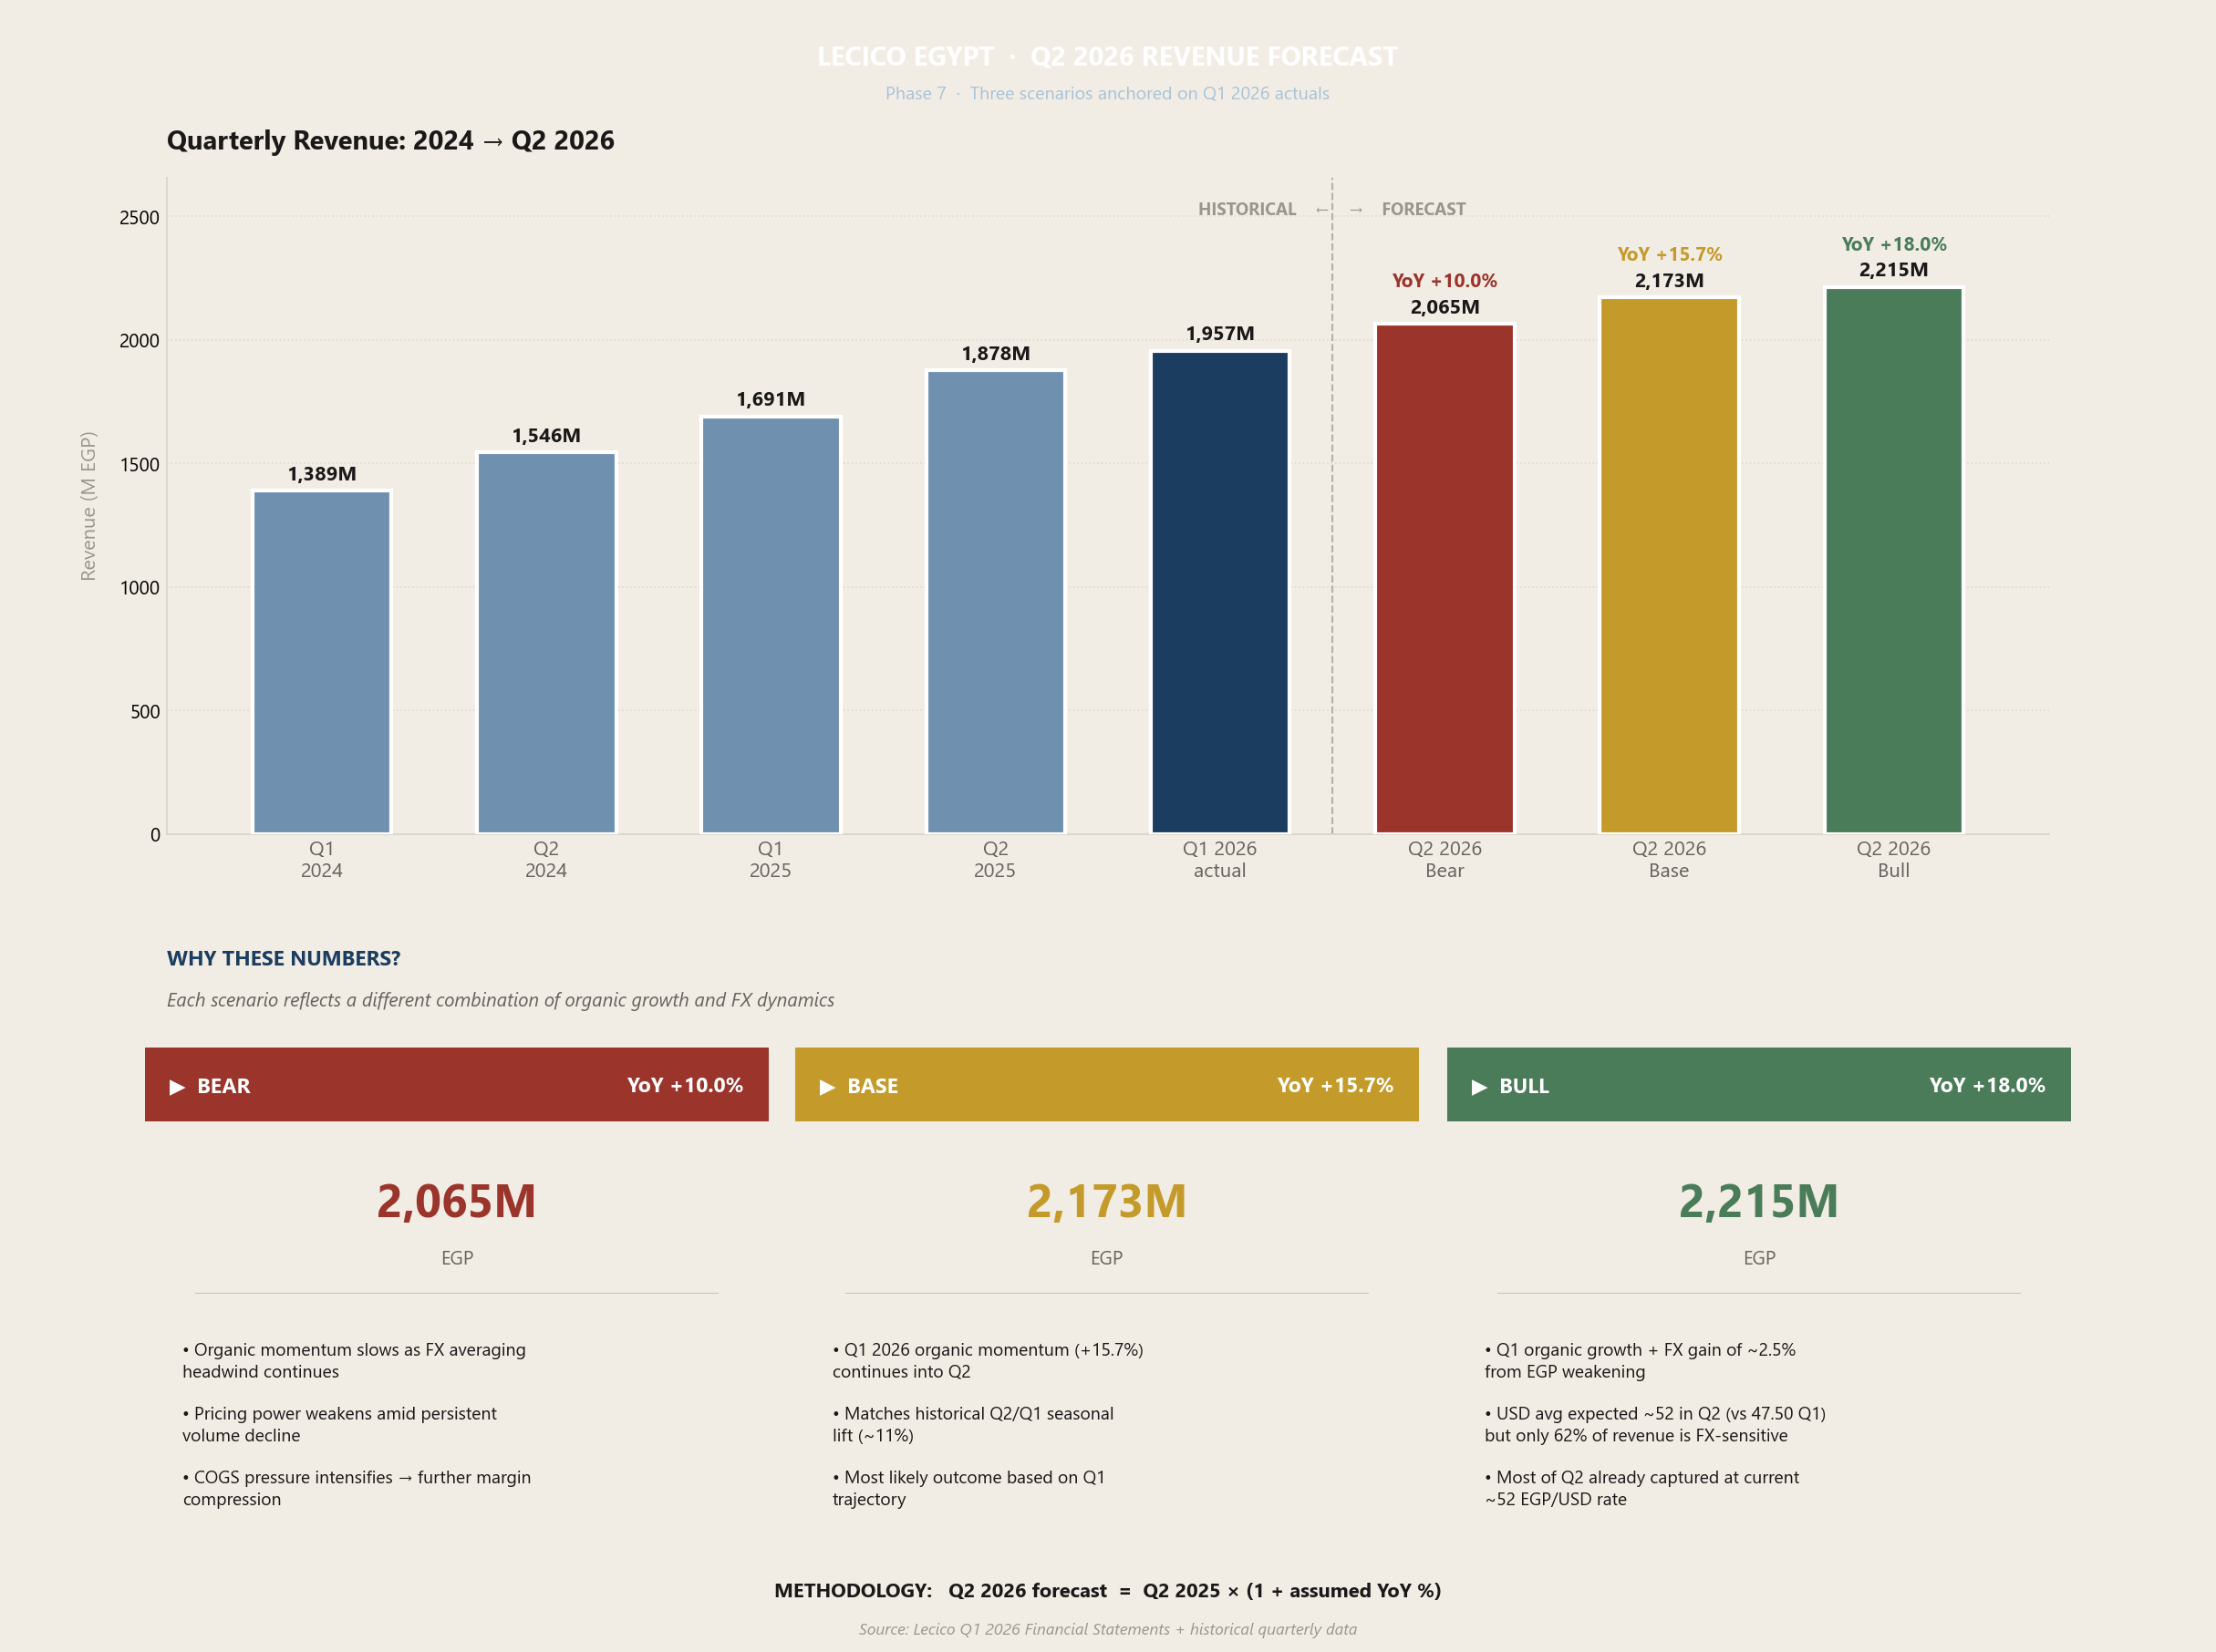


════════════════════════════════════════════════════════════
  Q2 2026 Revenue Forecast — 3 Scenarios
════════════════════════════════════════════════════════════

  Q1 2026 actual:    1,956.8M EGP  (+15.7% YoY)
  Q2 2025 actual:    1,877.5M EGP

  ── Forecasts ──
  🔴 Bear  (+10.0% YoY):   2,065M EGP   (+5.5% QoQ)
  🟡 Base  (+15.7% YoY):   2,173M EGP   (+11.0% QoQ)
  🟢 Bull  (+20.0% YoY):   2,253M EGP   (+15.1% QoQ)

  Most likely range: 2,100M – 2,200M EGP


In [21]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F2EDE4'
CARD   = '#FBF8F1'
HIST   = '#7090B0'   # historical bars
ANCHOR = '#1B3D5F'   # Q1 2026 anchor
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#D8D3C7'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── DATA ──────────────────────────────────────────────────────────────────────
labels = ['Q1\n2024', 'Q2\n2024', 'Q1\n2025', 'Q2\n2025', 'Q1 2026\nactual',
          'Q2 2026\nBear', 'Q2 2026\nBase', 'Q2 2026\nBull']
values = [1388.8, 1545.8, 1690.6, 1877.5, 1956.8, 2065, 2173, 2215]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor=BG)

# Header strip
ax_hdr = fig.add_axes([0, 0.94, 1, 0.06])
ax_hdr.set_facecolor(ANCHOR); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.55, 'LECICO EGYPT  ·  Q2 2026 REVENUE FORECAST',
            ha='center', va='center', fontsize=14, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18, 'Phase 7  ·  Three scenarios anchored on Q1 2026 actuals',
            ha='center', va='center', fontsize=9.5, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# Main chart
ax = fig.add_axes([0.07, 0.50, 0.86, 0.40])
ax.set_facecolor(BG)

x = np.arange(len(labels))
bars = ax.bar(x, values, color=colors, width=0.62,
              edgecolor='white', linewidth=2, zorder=3)

# Value labels on bars
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 25,
            f'{v:,.0f}M', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color=INK, zorder=4)

# YoY annotations above forecast bars
for idx, (sc_value, sc_color) in enumerate([(2065, BEAR), (2173, BASE), (2215, BULL)]):
    yoy = (sc_value/1877.5 - 1) * 100
    ax.text(5 + idx, sc_value + 130, f'YoY +{yoy:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color=sc_color)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(0, max(values) * 1.20)
ax.set_ylabel('Revenue (M EGP)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

# Divider line between historical and forecast
ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7, zorder=1)
ax.text(4.5, max(values) * 1.14, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9, color=MUTED,
        fontweight='bold')
ax.set_title('Quarterly Revenue: 2024 → Q2 2026',
             fontsize=14, fontweight='bold', color=INK, loc='left', pad=15)

# ── RATIONALE SECTION ─────────────────────────────────────────────────────────
fig.text(0.07, 0.42, 'WHY THESE NUMBERS?',
         fontsize=11, fontweight='bold', color=ANCHOR)
fig.text(0.07, 0.395,
         'Each scenario reflects a different combination of organic growth and FX dynamics',
         fontsize=10, color=SOFT, style='italic')

# ── 3 RATIONALE CARDS ────────────────────────────────────────────────────────
def rationale_card(fig, pos, color, name, yoy_text, value, points):
    ax = fig.add_axes(pos)
    ax.set_facecolor(CARD); ax.axis('off')

    # Top color strip
    ax.add_patch(patches.Rectangle(
        (0, 0.85), 1, 0.15, transform=ax.transAxes,
        facecolor=color, edgecolor='none'))
    
    ax.text(0.04, 0.92, f'▶  {name.upper()}',
            ha='left', va='center', fontsize=11, color='white',
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.96, 0.92, yoy_text,
            ha='right', va='center', fontsize=11, color='white',
            fontweight='bold', transform=ax.transAxes)

    # Big number
    ax.text(0.5, 0.68, f'{value:,.0f}M',
            ha='center', va='center', fontsize=24, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.57, 'EGP',
            ha='center', va='center', fontsize=10, color=SOFT,
            transform=ax.transAxes)

    # Divider
    ax.add_patch(patches.Rectangle(
        (0.08, 0.50), 0.84, 0.002, transform=ax.transAxes,
        facecolor=MUTED, edgecolor='none', alpha=0.5))

    # Bullet points
    for i, point in enumerate(points):
        ax.text(0.06, 0.40 - i*0.13, f'• {point}',
                ha='left', va='top', fontsize=9.3, color=INK,
                transform=ax.transAxes, wrap=True, linespacing=1.4)


bear_points = [
    'Organic momentum slows as FX averaging\nheadwind continues',
    'Pricing power weakens amid persistent\nvolume decline',
    'COGS pressure intensifies → further margin\ncompression',
]
base_points = [
    'Q1 2026 organic momentum (+15.7%)\ncontinues into Q2',
    'Matches historical Q2/Q1 seasonal\nlift (~11%)',
    'Most likely outcome based on Q1\ntrajectory',
]
bull_points = [
    'Q1 organic growth + FX gain of ~2.5%\nfrom EGP weakening',
    'USD avg expected ~52 in Q2 (vs 47.50 Q1)\nbut only 62% of revenue is FX-sensitive',
    'Most of Q2 already captured at current\n~52 EGP/USD rate',
]

rationale_card(fig, [0.06,  0.07, 0.285, 0.30], BEAR, 'Bear', 'YoY +10.0%', 2065, bear_points)
rationale_card(fig, [0.357, 0.07, 0.285, 0.30], BASE, 'Base', 'YoY +15.7%', 2173, base_points)
rationale_card(fig, [0.655, 0.07, 0.285, 0.30], BULL, 'Bull', 'YoY +18.0%', 2215, bull_points)
# ── FOOTER ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.035,
         'METHODOLOGY:   Q2 2026 forecast  =  Q2 2025 × (1 + assumed YoY %)',
         ha='center', fontsize=10.5, color=INK, fontweight='bold')
fig.text(0.5, 0.012,
         'Source: Lecico Q1 2026 Financial Statements + historical quarterly data',
         ha='center', fontsize=8.5, color=MUTED, style='italic')

plt.savefig('lecico_q2_forecast.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

# ── CONSOLE OUTPUT ────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  Q2 2026 Revenue Forecast — 3 Scenarios")
print("═" * 60)
print(f"\n  Q1 2026 actual:    1,956.8M EGP  (+15.7% YoY)")
print(f"  Q2 2025 actual:    1,877.5M EGP")
print(f"\n  ── Forecasts ──")
print(f"  🔴 Bear  (+10.0% YoY):   2,065M EGP   (+5.5% QoQ)")
print(f"  🟡 Base  (+15.7% YoY):   2,173M EGP   (+11.0% QoQ)")
print(f"  🟢 Bull  (+20.0% YoY):   2,253M EGP   (+15.1% QoQ)")
print(f"\n  Most likely range: 2,100M – 2,200M EGP")

*يستعرض القسم التالي بناء توقعات مجمل الربح على هذه السيناريوهات.*

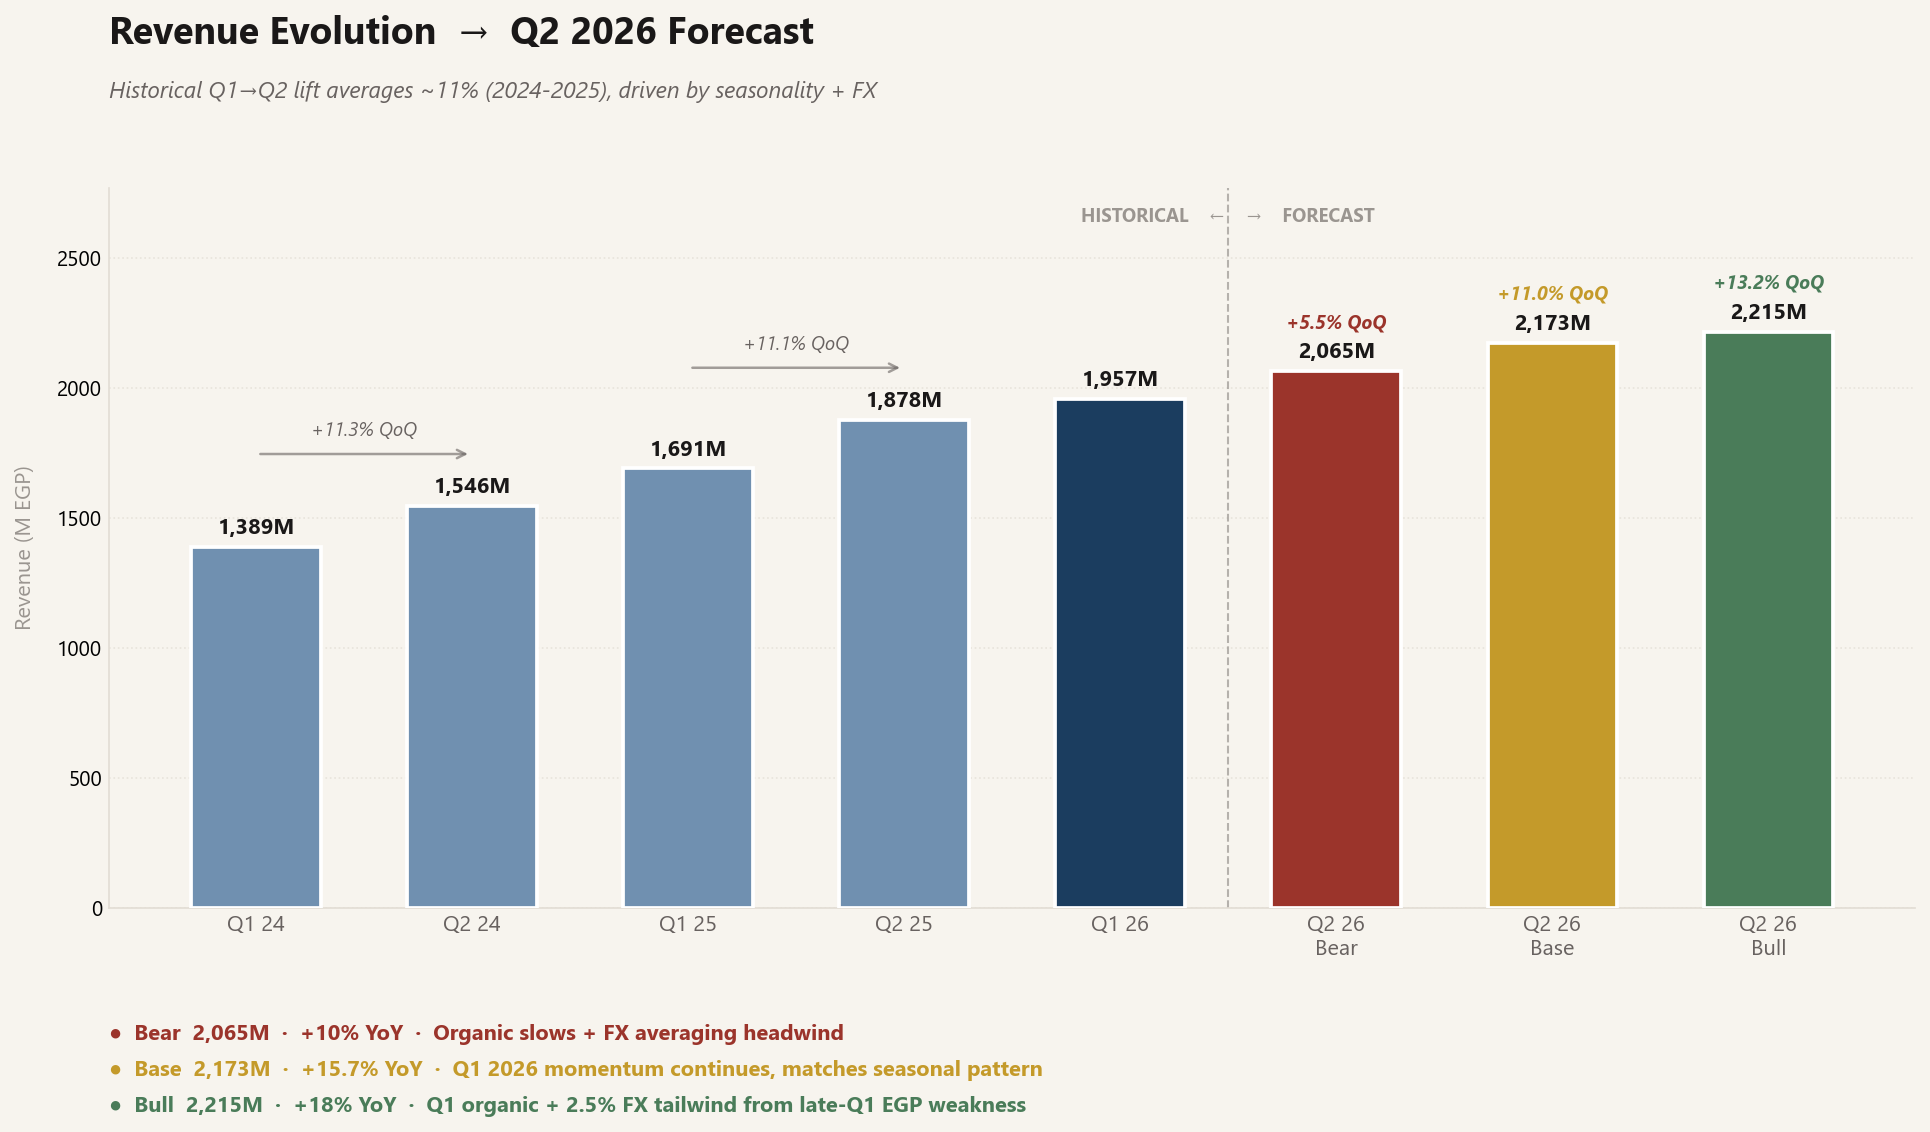

In [22]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F7F4EE'
HIST   = '#7090B0'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#E2DDD4'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8), facecolor=BG)
ax = fig.add_axes([0.08, 0.20, 0.86, 0.60])
ax.set_facecolor(BG)

labels = ['Q1 24', 'Q2 24', 'Q1 25', 'Q2 25', 'Q1 26',
          'Q2 26\nBear', 'Q2 26\nBase', 'Q2 26\nBull']
rev = [1388.8, 1545.8, 1690.6, 1877.5, 1956.8, 2065, 2173, 2215]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

x = np.arange(len(labels))
bars = ax.bar(x, rev, color=colors, width=0.6,
              edgecolor='white', linewidth=1.8, zorder=3)

# Value labels
for bar, v in zip(bars, rev):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30,
            f'{v:,.0f}M', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color=INK, zorder=4)

# Q1 → Q2 historical lift annotations
for q1_idx, q2_idx in [(0, 1), (2, 3)]:
    diff = (rev[q2_idx] / rev[q1_idx] - 1) * 100
    y_pos = max(rev[q1_idx], rev[q2_idx]) + 200
    ax.annotate('', xy=(q2_idx, y_pos), xytext=(q1_idx, y_pos),
                arrowprops=dict(arrowstyle='->', color=SOFT, lw=1.2, alpha=0.6))
    ax.text((q1_idx + q2_idx) / 2, y_pos + 50, f'+{diff:.1f}% QoQ',
            ha='center', va='bottom', fontsize=9, color=SOFT, style='italic')

# Q1 26 → each forecast Q2 26 (implied QoQ growth)
q1_2026 = rev[4]
for idx, color in zip([5, 6, 7], [BEAR, BASE, BULL]):
    qoq = (rev[idx] / q1_2026 - 1) * 100
    ax.text(idx, rev[idx] + 150, f'+{qoq:.1f}% QoQ',
            ha='center', va='bottom', fontsize=9, color=color,
            fontweight='bold', style='italic')

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(0, max(rev) * 1.25)
ax.set_ylabel('Revenue (M EGP)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

# Divider
ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7)
ax.text(4.5, max(rev) * 1.20, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9,
        color=MUTED, fontweight='bold')

# Title
fig.text(0.08, 0.92, 'Revenue Evolution  →  Q2 2026 Forecast',
         fontsize=18, fontweight='bold', color=INK)
fig.text(0.08, 0.875,
         'Historical Q1→Q2 lift averages ~11% (2024-2025), driven by seasonality + FX',
         fontsize=11, color=SOFT, style='italic')

# Rationale (bottom) — استخدام ● بدل emoji
fig.text(0.08, 0.09,
         '●  Bear  2,065M  ·  +10% YoY  ·  Organic slows + FX averaging headwind',
         fontsize=10.5, color=BEAR, fontweight='bold')
fig.text(0.08, 0.06,
         '●  Base  2,173M  ·  +15.7% YoY  ·  Q1 2026 momentum continues, matches seasonal pattern',
         fontsize=10.5, color=BASE, fontweight='bold')
fig.text(0.08, 0.03,
         '●  Bull  2,215M  ·  +18% YoY  ·  Q1 organic + 2.5% FX tailwind from late-Q1 EGP weakness',
         fontsize=10.5, color=BULL, fontweight='bold')

plt.savefig('lecico_revenue_forecast.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## Gross Profit Expectations — توقعات مجمل الربح

### المنهجية
بعد تحديد توقع الإيراد، يُضرب في الـ Gross Margin المُفترض لكل سيناريو:

```
Gross Profit = Revenue × GM%
```

### افتراضات الـ GM

| السيناريو | GM% | GP المتوقع | المنطق |
|---|---|---|---|
| **Bear** | 18% | 372M | استكمال للنمط التاريخي (Q2 GM أقل من Q1 بـ 2pp) |
| **Base** | 21% | 456M | تعافٍ طفيف يستلزم كسر النمط الموسمي |
| **Bull** | 23% | 510M | عودة إلى مستوى Q2 2025 (23.9%) |

### النمط التاريخي

| السنة | Q1 GM | Q2 GM | الفرق |
|---|---|---|---|
| 2024 | 31.4% | 29.6% | **-1.8pp** |
| 2025 | 26.1% | 23.9% | **-2.2pp** |

النمط واضح: **Q2 GM أقل من Q1 GM بحوالي 2 نقطة مئوية** (موسمية تشغيلية).

تطبيق نفس النمط على Q1 2026 (20.2%) ينتج عنه **Q2 2026 ≈ 18%** — وهو ما يُمثّله الـ Bear case (استمرار النمط بالكامل).

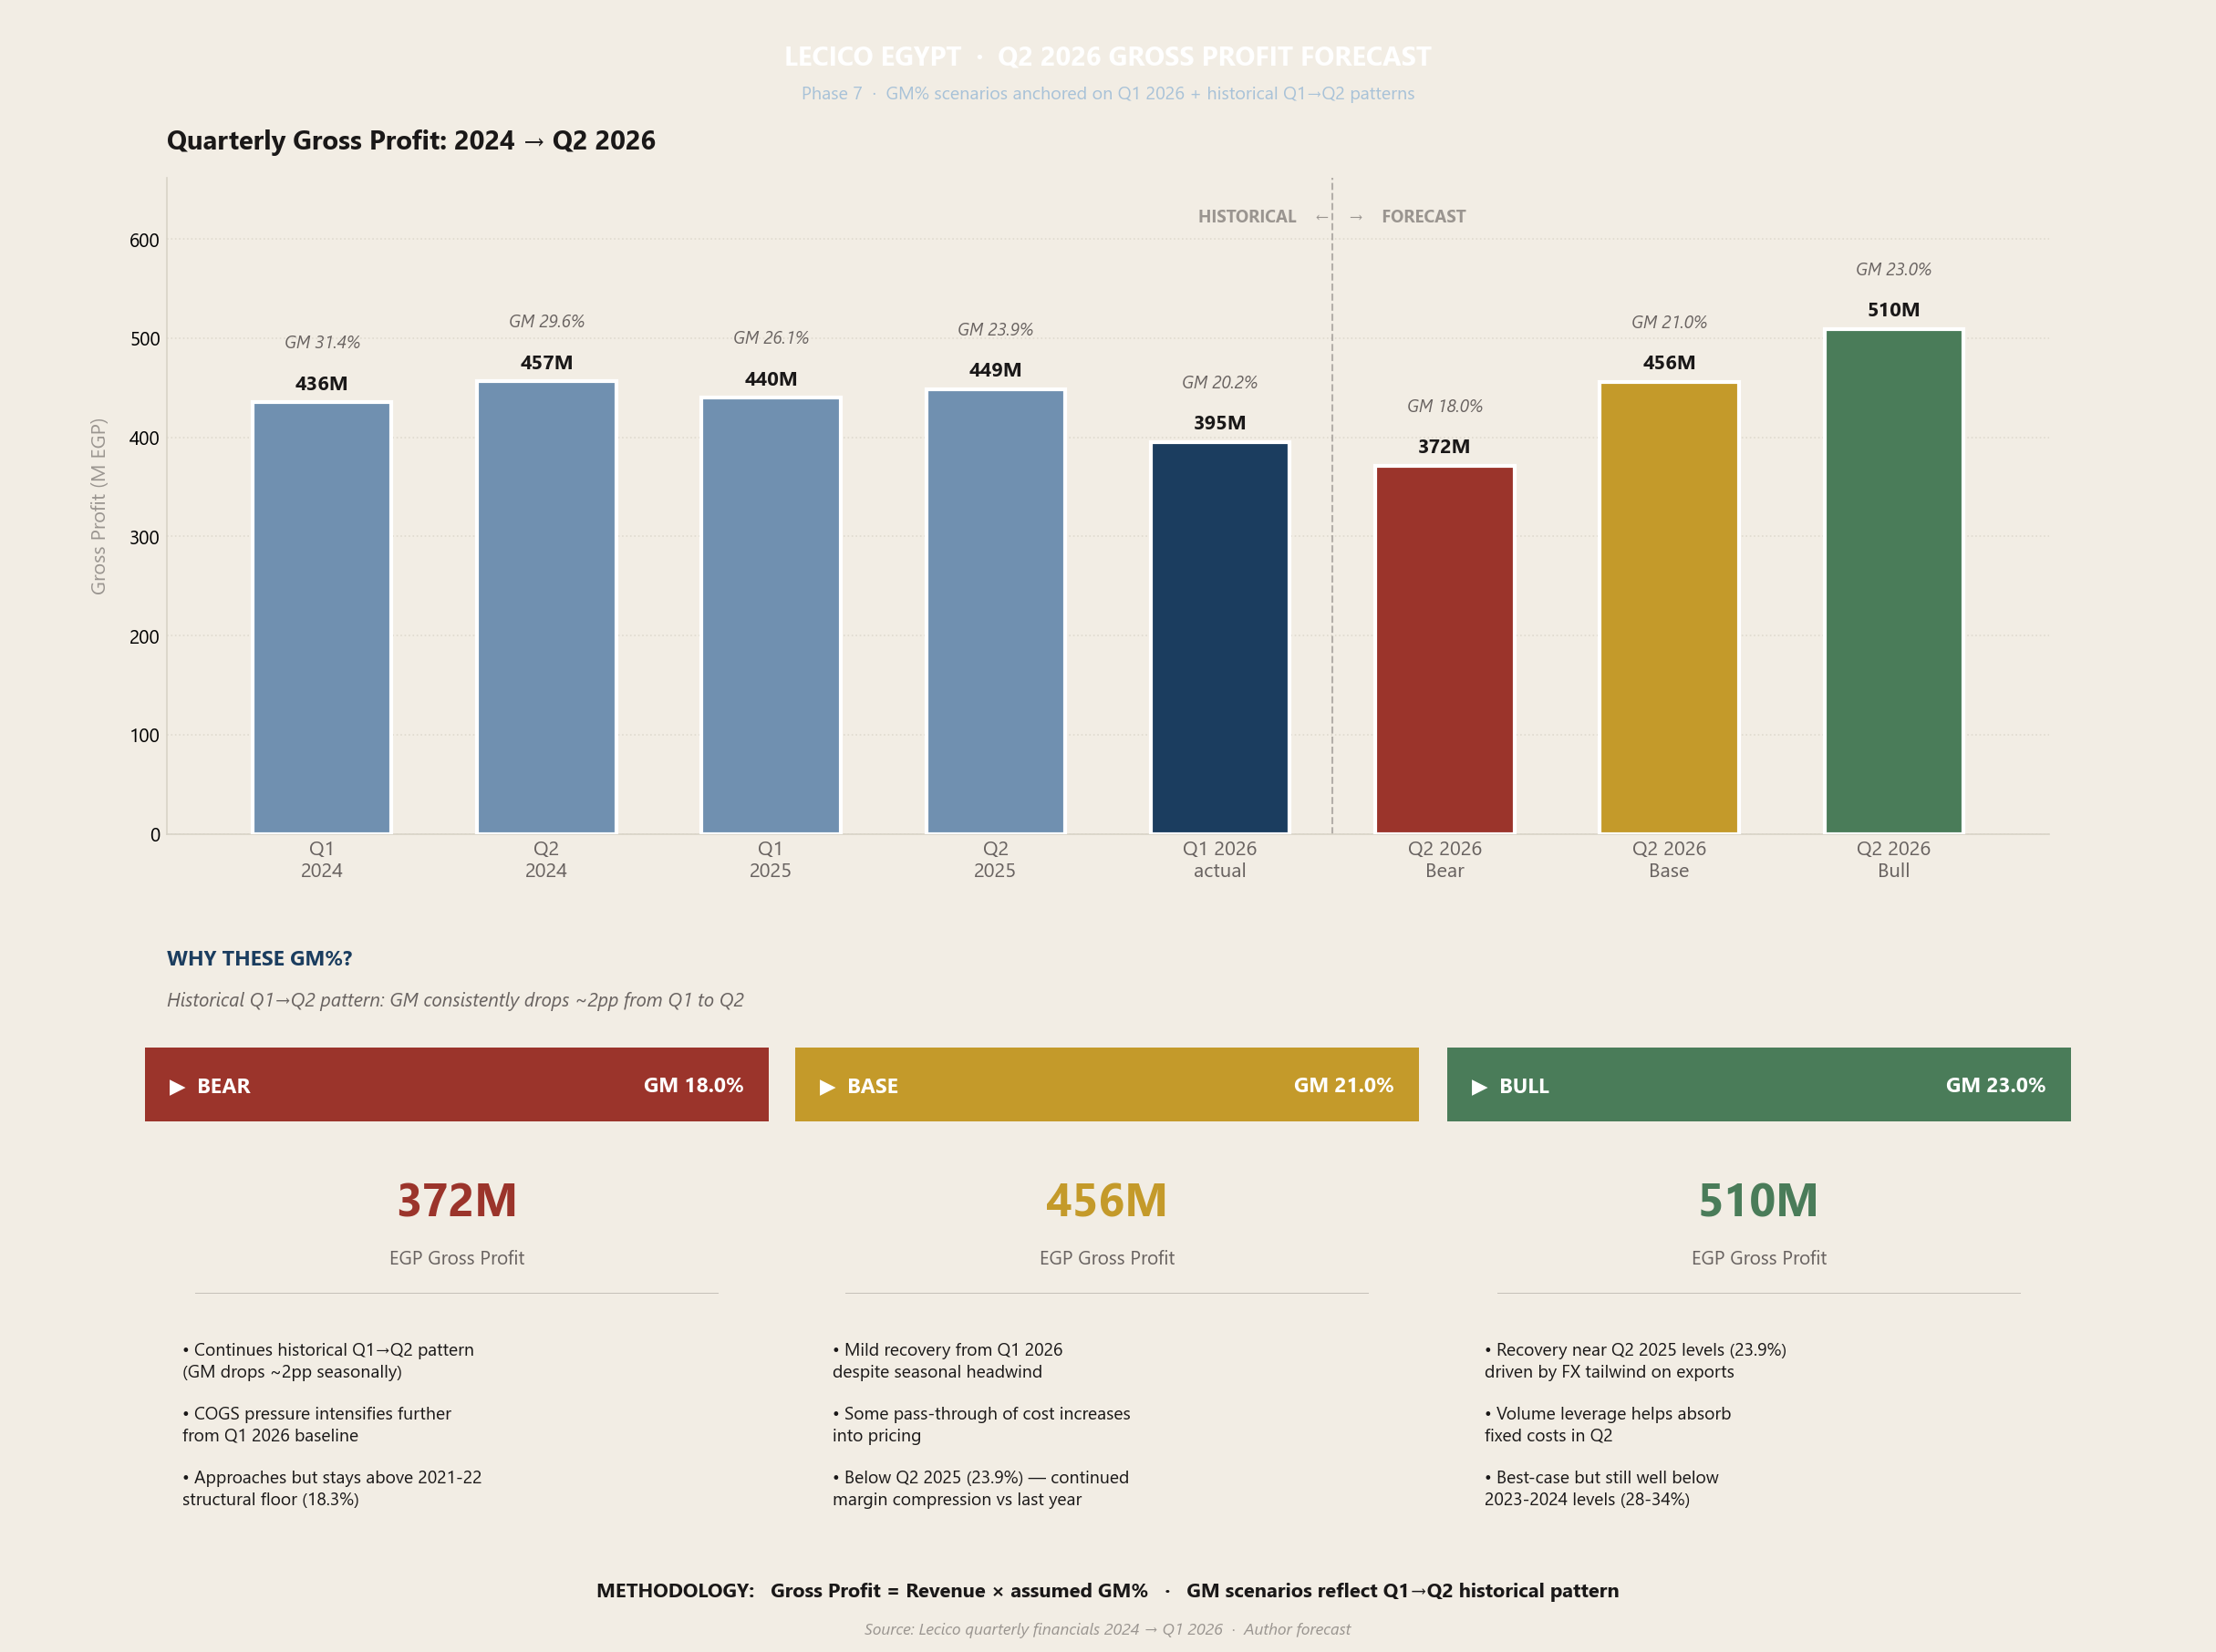


═════════════════════════════════════════════════════════════════
  Q2 2026 Gross Profit Forecast — 3 Scenarios
═════════════════════════════════════════════════════════════════

  Q1 2026 actual:     GM 20.2%   →   GP 395.4M EGP
  Q2 2025 actual:     GM 23.9%   →   GP 449.0M EGP

  Historical Q1→Q2 GM trend: -2.0pp (2024) and -2.2pp (2025)

  ── Q2 2026 Forecasts ──
  🔴 Bear  (GM 18.0%):   371.7M EGP   (-17.2% YoY)
  🟡 Base  (GM 21.0%):   456.3M EGP   ( +1.6% YoY)
  🟢 Bull  (GM 23.0%):   509.5M EGP   (+13.5% YoY)


In [23]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F2EDE4'
CARD   = '#FBF8F1'
HIST   = '#7090B0'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#D8D3C7'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── DATA ──────────────────────────────────────────────────────────────────────
labels = ['Q1\n2024', 'Q2\n2024', 'Q1\n2025', 'Q2\n2025', 'Q1 2026\nactual',
          'Q2 2026\nBear', 'Q2 2026\nBase', 'Q2 2026\nBull']
gp_values = [435.8, 456.8, 440.4, 449.0, 395.4, 371.7, 456.3, 509.5]
gm_values = [31.4, 29.6, 26.1, 23.9, 20.2, 18.0, 21.0, 23.0]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor=BG)

# Header
ax_hdr = fig.add_axes([0, 0.94, 1, 0.06])
ax_hdr.set_facecolor(ANCHOR); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.55, 'LECICO EGYPT  ·  Q2 2026 GROSS PROFIT FORECAST',
            ha='center', va='center', fontsize=14, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18, 'Phase 7  ·  GM% scenarios anchored on Q1 2026 + historical Q1→Q2 patterns',
            ha='center', va='center', fontsize=9.5, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# Main chart
ax = fig.add_axes([0.07, 0.50, 0.86, 0.40])
ax.set_facecolor(BG)

x = np.arange(len(labels))
bars = ax.bar(x, gp_values, color=colors, width=0.62,
              edgecolor='white', linewidth=2, zorder=3)

# Value labels (GP M EGP)
for bar, v in zip(bars, gp_values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 8,
            f'{v:,.0f}M', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color=INK, zorder=4)

# GM% labels above bars (smaller, secondary)
for bar, gm in zip(bars, gm_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'GM {gm:.1f}%', ha='center', va='bottom',
            fontsize=9, color=SOFT, style='italic', zorder=4)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(0, max(gp_values) * 1.30)
ax.set_ylabel('Gross Profit (M EGP)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

# Divider
ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7, zorder=1)
ax.text(4.5, max(gp_values) * 1.22, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9, color=MUTED, fontweight='bold')

ax.set_title('Quarterly Gross Profit: 2024 → Q2 2026',
             fontsize=14, fontweight='bold', color=INK, loc='left', pad=15)

# ── RATIONALE SECTION ─────────────────────────────────────────────────────────
fig.text(0.07, 0.42, 'WHY THESE GM%?',
         fontsize=11, fontweight='bold', color=ANCHOR)
fig.text(0.07, 0.395,
         'Historical Q1→Q2 pattern: GM consistently drops ~2pp from Q1 to Q2',
         fontsize=10, color=SOFT, style='italic')

# ── CARDS ─────────────────────────────────────────────────────────────────────
def rationale_card(fig, pos, color, name, gm_text, value, points):
    ax = fig.add_axes(pos)
    ax.set_facecolor(CARD); ax.axis('off')
    
    ax.add_patch(patches.Rectangle(
        (0, 0.85), 1, 0.15, transform=ax.transAxes,
        facecolor=color, edgecolor='none'))
    ax.text(0.04, 0.92, f'▶  {name.upper()}',
            ha='left', va='center', fontsize=11, color='white',
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.96, 0.92, gm_text,
            ha='right', va='center', fontsize=11, color='white',
            fontweight='bold', transform=ax.transAxes)
    
    ax.text(0.5, 0.68, f'{value:,.0f}M',
            ha='center', va='center', fontsize=24, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.57, 'EGP Gross Profit',
            ha='center', va='center', fontsize=10, color=SOFT,
            transform=ax.transAxes)
    
    ax.add_patch(patches.Rectangle(
        (0.08, 0.50), 0.84, 0.002, transform=ax.transAxes,
        facecolor=MUTED, edgecolor='none', alpha=0.5))
    
    for i, point in enumerate(points):
        ax.text(0.06, 0.40 - i*0.13, f'• {point}',
                ha='left', va='top', fontsize=9.3, color=INK,
                transform=ax.transAxes, linespacing=1.4)

bear_points = [
    'Continues historical Q1→Q2 pattern\n(GM drops ~2pp seasonally)',
    'COGS pressure intensifies further\nfrom Q1 2026 baseline',
    'Approaches but stays above 2021-22\nstructural floor (18.3%)',
]
base_points = [
    'Mild recovery from Q1 2026\ndespite seasonal headwind',
    'Some pass-through of cost increases\ninto pricing',
    'Below Q2 2025 (23.9%) — continued\nmargin compression vs last year',
]
bull_points = [
    'Recovery near Q2 2025 levels (23.9%)\ndriven by FX tailwind on exports',
    'Volume leverage helps absorb\nfixed costs in Q2',
    'Best-case but still well below\n2023-2024 levels (28-34%)',
]

rationale_card(fig, [0.06,  0.07, 0.285, 0.30], BEAR, 'Bear', 'GM 18.0%', 371.7, bear_points)
rationale_card(fig, [0.357, 0.07, 0.285, 0.30], BASE, 'Base', 'GM 21.0%', 456.3, base_points)
rationale_card(fig, [0.655, 0.07, 0.285, 0.30], BULL, 'Bull', 'GM 23.0%', 509.5, bull_points)

# Footer
fig.text(0.5, 0.035,
         'METHODOLOGY:   Gross Profit = Revenue × assumed GM%   ·   GM scenarios reflect Q1→Q2 historical pattern',
         ha='center', fontsize=10.5, color=INK, fontweight='bold')
fig.text(0.5, 0.012,
         'Source: Lecico quarterly financials 2024 → Q1 2026  ·  Author forecast',
         ha='center', fontsize=8.5, color=MUTED, style='italic')

plt.savefig('lecico_q2_gp_forecast.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

# ── CONSOLE ───────────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  Q2 2026 Gross Profit Forecast — 3 Scenarios")
print("═" * 65)
print(f"\n  Q1 2026 actual:     GM 20.2%   →   GP 395.4M EGP")
print(f"  Q2 2025 actual:     GM 23.9%   →   GP 449.0M EGP")
print(f"\n  Historical Q1→Q2 GM trend: -2.0pp (2024) and -2.2pp (2025)")
print(f"\n  ── Q2 2026 Forecasts ──")
print(f"  🔴 Bear  (GM 18.0%):   371.7M EGP   (-17.2% YoY)")
print(f"  🟡 Base  (GM 21.0%):   456.3M EGP   ( +1.6% YoY)")
print(f"  🟢 Bull  (GM 23.0%):   509.5M EGP   (+13.5% YoY)")

*يستعرض القسم التالي بناء توقعات الربح التشغيلي.*

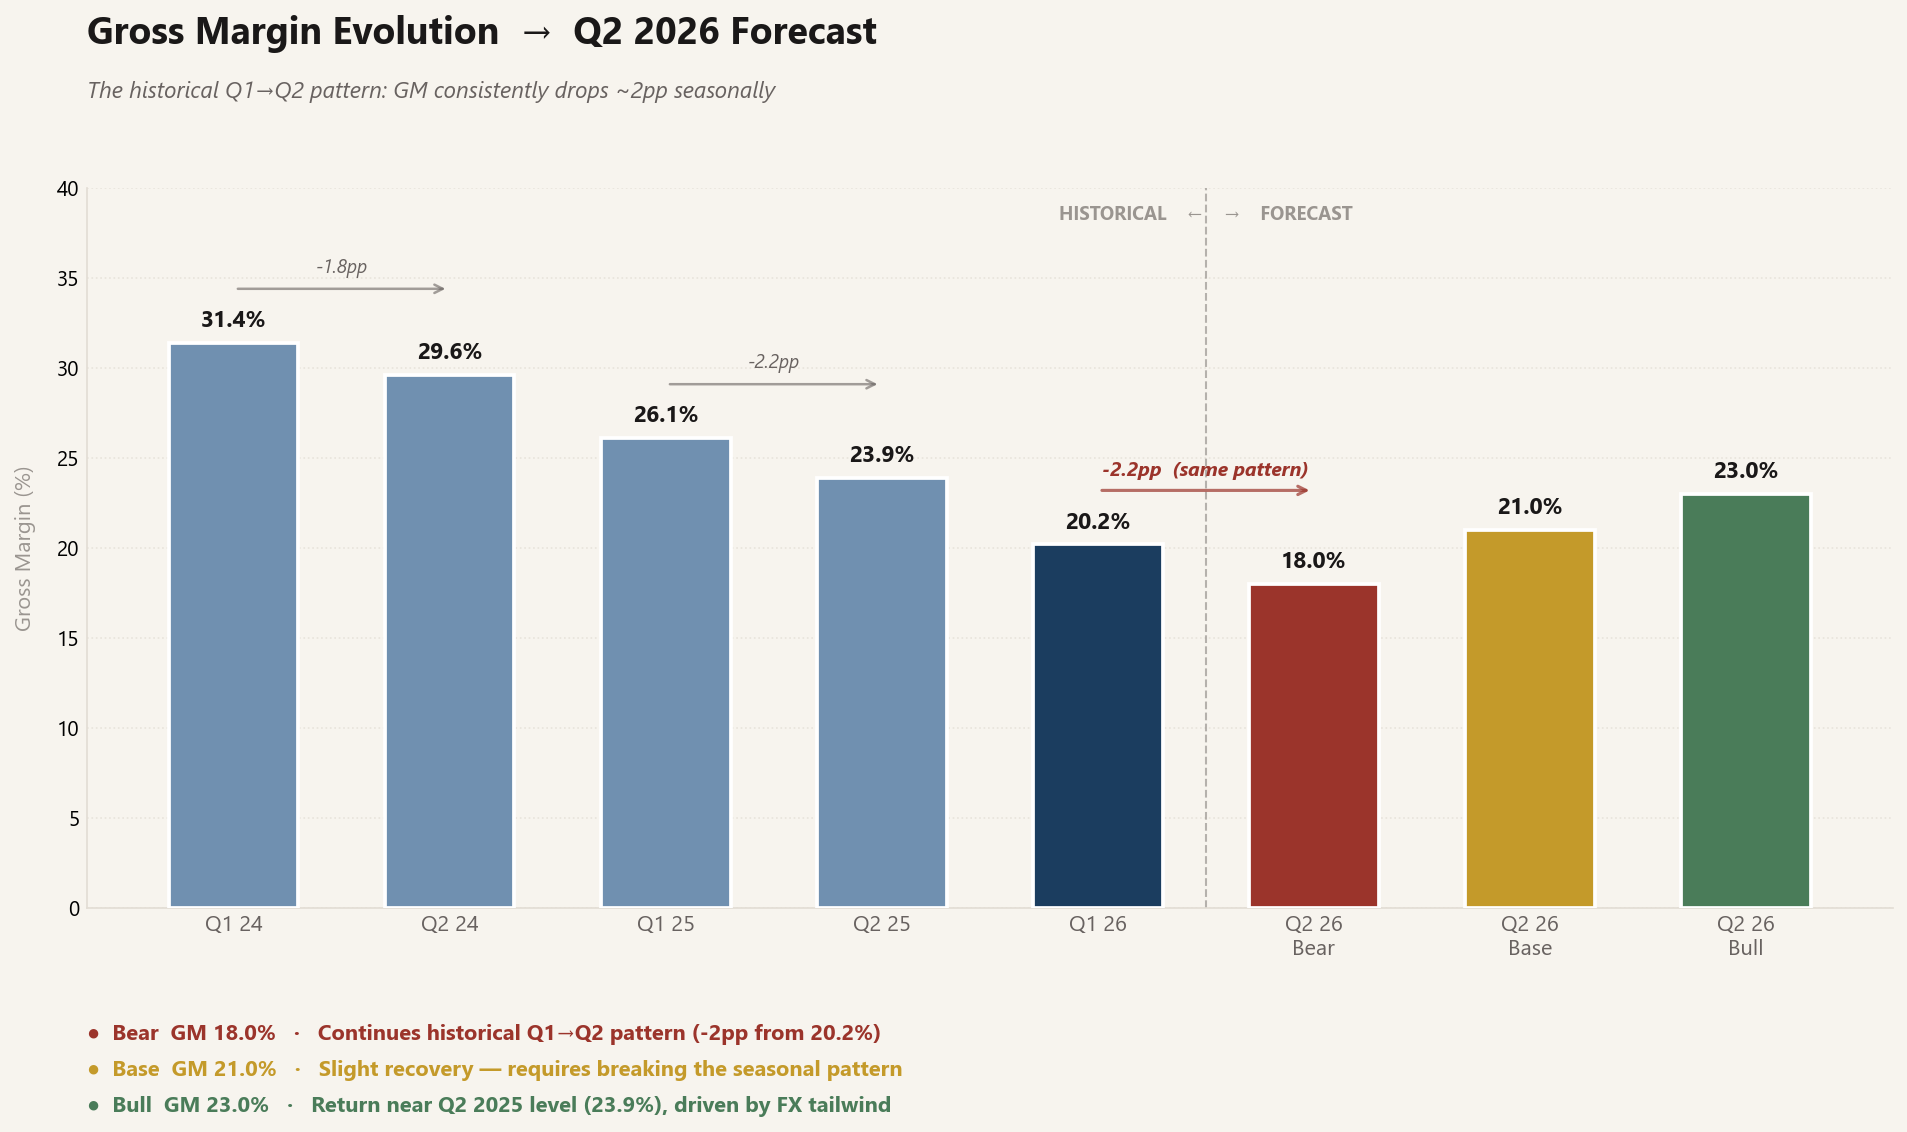

In [24]:
import numpy as np
import matplotlib.pyplot as plt

INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F7F4EE'
HIST   = '#7090B0'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#E2DDD4'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

fig = plt.figure(figsize=(14, 8), facecolor=BG)
ax = fig.add_axes([0.08, 0.20, 0.86, 0.60])
ax.set_facecolor(BG)

labels = ['Q1 24', 'Q2 24', 'Q1 25', 'Q2 25', 'Q1 26',
          'Q2 26\nBear', 'Q2 26\nBase', 'Q2 26\nBull']
gm = [31.4, 29.6, 26.1, 23.9, 20.2, 18.0, 21.0, 23.0]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

x = np.arange(len(labels))
bars = ax.bar(x, gm, color=colors, width=0.6,
              edgecolor='white', linewidth=1.8, zorder=3)

for bar, v in zip(bars, gm):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.6,
            f'{v:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=INK, zorder=4)

for q1_idx, q2_idx in [(0, 1), (2, 3)]:
    diff = gm[q2_idx] - gm[q1_idx]
    y_pos = max(gm[q1_idx], gm[q2_idx]) + 3
    ax.annotate('', xy=(q2_idx, y_pos), xytext=(q1_idx, y_pos),
                arrowprops=dict(arrowstyle='->', color=SOFT, lw=1.2, alpha=0.6))
    ax.text((q1_idx + q2_idx) / 2, y_pos + 0.6, f'{diff:+.1f}pp',
            ha='center', va='bottom', fontsize=9, color=SOFT, style='italic')

# Q1 26 → Bear (same pattern)
diff = gm[5] - gm[4]
y_pos = max(gm[4], gm[5]) + 3
ax.annotate('', xy=(5, y_pos), xytext=(4, y_pos),
            arrowprops=dict(arrowstyle='->', color=BEAR, lw=1.5, alpha=0.7))
ax.text(4.5, y_pos + 0.6, f'{diff:+.1f}pp  (same pattern)',
        ha='center', va='bottom', fontsize=9.5, color=BEAR,
        fontweight='bold', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(0, 40)
ax.set_ylabel('Gross Margin (%)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7)
ax.text(4.5, 38.5, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9,
        color=MUTED, fontweight='bold')

fig.text(0.08, 0.92, 'Gross Margin Evolution  →  Q2 2026 Forecast',
         fontsize=18, fontweight='bold', color=INK)
fig.text(0.08, 0.875,
         'The historical Q1→Q2 pattern: GM consistently drops ~2pp seasonally',
         fontsize=11, color=SOFT, style='italic')

fig.text(0.08, 0.09,
         '●  Bear  GM 18.0%   ·   Continues historical Q1→Q2 pattern (-2pp from 20.2%)',
         fontsize=10.5, color=BEAR, fontweight='bold')
fig.text(0.08, 0.06,
         '●  Base  GM 21.0%   ·   Slight recovery — requires breaking the seasonal pattern',
         fontsize=10.5, color=BASE, fontweight='bold')
fig.text(0.08, 0.03,
         '●  Bull  GM 23.0%   ·   Return near Q2 2025 level (23.9%), driven by FX tailwind',
         fontsize=10.5, color=BULL, fontweight='bold')

plt.savefig('lecico_gm_forecast.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## EBIT Expectations — توقعات الربح التشغيلي

### المنهجية
```
EBIT = Gross Profit − OpEx
```

تشمل OpEx البنود التالية:
- Selling & Distribution (التسويق والتوزيع)
- G&A (المصاريف الإدارية والعمومية)
- ECL (Expected Credit Loss)
- Other Expenses (مطروحاً منها Other Income)

### الافتراضات

| السيناريو | OpEx % | EBIT المتوقع | المنطق |
|---|---|---|---|
| **Bear** | 14.0% | 83M | عدم الاستفادة من الـ leverage مع الضغط الموسمي |
| **Base** | 13.0% | 174M | ارتفاع طفيف عن Q1 2026 (نمط Q2 المعتاد) |
| **Bull** | 12.5% | 233M | استمرار الانضباط من Q1 2026 |

### Operating Leverage

تمتلك ليسيكو **operating leverage مرتفعاً**، إذ تُمثّل الـ G&A وحدها 62% من OpEx (تكاليف ثابتة).

النتيجة: **أي تغيّر بمقدار 100bps في الـ GM% أو الـ OpEx% ينعكس بأثر كبير على EBIT** — والـ leverage يعمل في الاتجاهين (صعوداً وهبوطاً).

In [25]:
import os

# شوف إنت في أنهي مجلد
print("📁 المجلد الحالي:", os.getcwd())
print()

# دور على كل الـ PNG files
print("🖼 الـ charts الموجودة:")
found = []
for f in os.listdir('.'):
    if f.endswith('.png'):
        found.append(f)
        print(f"  ✅ {f}")

if not found:
    print("  ❌ مفيش أي PNG في المجلد ده!")
    print()
    print("🔍 بندور في C:\\LCSW ...")
    if os.path.exists(r'C:\LCSW'):
        for f in os.listdir(r'C:\LCSW'):
            if f.endswith('.png'):
                print(f"  ✅ C:\\LCSW\\{f}")

📁 المجلد الحالي: c:\LCSW

🖼 الـ charts الموجودة:
  ✅ 01_revenue_profit.png
  ✅ 02_margins.png
  ✅ 03_returns_eps.png
  ✅ 04_balance_sheet.png
  ✅ 05_working_capital.png
  ✅ 06_net_finance.png
  ✅ 07_profit_bridge.png
  ✅ 08_efficiency.png
  ✅ 09_events_timeline.png
  ✅ 10_kpi_table.png
  ✅ lecico_cascade_final.png
  ✅ lecico_ccc.png
  ✅ lecico_currency_illusion.png
  ✅ lecico_customer_types.png
  ✅ lecico_ebit_forecast.png
  ✅ lecico_factories.png
  ✅ lecico_final_summary.png
  ✅ lecico_gm_forecast.png
  ✅ lecico_np_forecast.png
  ✅ lecico_np_forecast_v2.png
  ✅ lecico_profit_chart.png
  ✅ lecico_q2_forecast.png
  ✅ lecico_q2_gp_forecast.png
  ✅ lecico_revenue_breakdown.png
  ✅ lecico_revenue_forecast.png
  ✅ lecico_summary.png
  ✅ lecico_thesis.png
  ✅ lecico_valuation.png


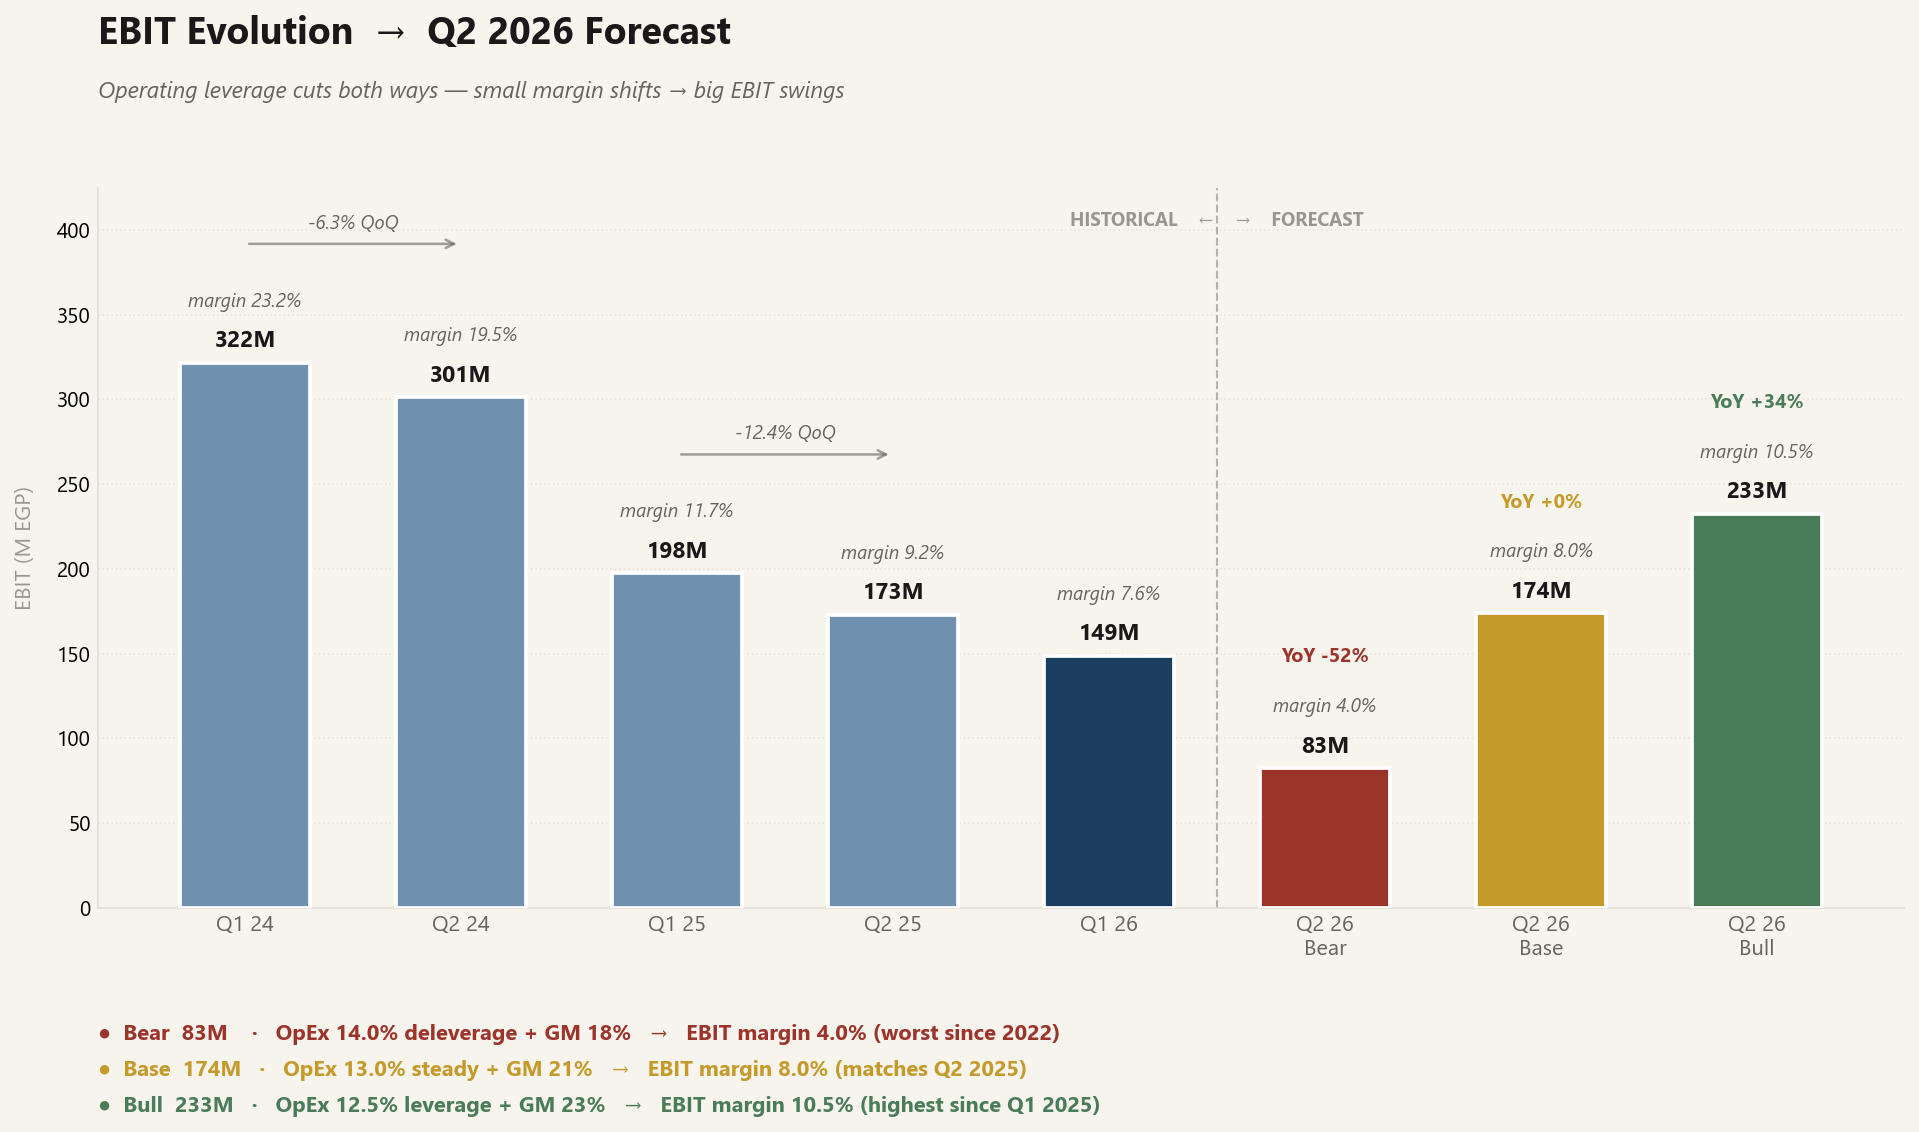

In [26]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F7F4EE'
HIST   = '#7090B0'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#E2DDD4'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8), facecolor=BG)
ax = fig.add_axes([0.08, 0.20, 0.86, 0.60])
ax.set_facecolor(BG)

labels = ['Q1 24', 'Q2 24', 'Q1 25', 'Q2 25', 'Q1 26',
          'Q2 26\nBear', 'Q2 26\nBase', 'Q2 26\nBull']
ebit = [321.7, 301.4, 197.5, 173.0, 148.9, 82.6, 173.8, 232.6]
margins = [23.2, 19.5, 11.7, 9.2, 7.6, 4.0, 8.0, 10.5]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

x = np.arange(len(labels))
bars = ax.bar(x, ebit, color=colors, width=0.6,
              edgecolor='white', linewidth=1.8, zorder=3)

# Value labels (EGP M)
for bar, v in zip(bars, ebit):
    ax.text(bar.get_x() + bar.get_width()/2, v + 6,
            f'{v:.0f}M', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=INK, zorder=4)

# Margin % labels above (smaller, italic)
for bar, m in zip(bars, margins):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'margin {m:.1f}%', ha='center', va='bottom',
            fontsize=9, color=SOFT, style='italic', zorder=4)

# Q1→Q2 historical EBIT change arrows
for q1_idx, q2_idx in [(0, 1), (2, 3)]:
    diff = (ebit[q2_idx] / ebit[q1_idx] - 1) * 100
    y_pos = max(ebit[q1_idx], ebit[q2_idx]) + 70
    ax.annotate('', xy=(q2_idx, y_pos), xytext=(q1_idx, y_pos),
                arrowprops=dict(arrowstyle='->', color=SOFT, lw=1.2, alpha=0.6))
    ax.text((q1_idx + q2_idx) / 2, y_pos + 6, f'{diff:+.1f}% QoQ',
            ha='center', va='bottom', fontsize=9, color=SOFT, style='italic')

# YoY annotations vs Q2 2025 for forecasts
q2_2025 = ebit[3]
for idx, color in zip([5, 6, 7], [BEAR, BASE, BULL]):
    yoy = (ebit[idx] / q2_2025 - 1) * 100
    sign = '+' if yoy >= 0 else ''
    ax.text(idx, ebit[idx] + 60, f'YoY {sign}{yoy:.0f}%',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold',
            color=color)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(0, max(ebit) * 1.32)
ax.set_ylabel('EBIT (M EGP)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

# Divider
ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7)
ax.text(4.5, max(ebit) * 1.26, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9,
        color=MUTED, fontweight='bold')

# Title
fig.text(0.08, 0.92, 'EBIT Evolution  →  Q2 2026 Forecast',
         fontsize=18, fontweight='bold', color=INK)
fig.text(0.08, 0.875,
         'Operating leverage cuts both ways — small margin shifts → big EBIT swings',
         fontsize=11, color=SOFT, style='italic')

# Rationale (bottom)
fig.text(0.08, 0.09,
         '●  Bear  83M    ·   OpEx 14.0% deleverage + GM 18%   →   EBIT margin 4.0% (worst since 2022)',
         fontsize=10.5, color=BEAR, fontweight='bold')
fig.text(0.08, 0.06,
         '●  Base  174M   ·   OpEx 13.0% steady + GM 21%   →   EBIT margin 8.0% (matches Q2 2025)',
         fontsize=10.5, color=BASE, fontweight='bold')
fig.text(0.08, 0.03,
         '●  Bull  233M   ·   OpEx 12.5% leverage + GM 23%   →   EBIT margin 10.5% (highest since Q1 2025)',
         fontsize=10.5, color=BULL, fontweight='bold')

plt.savefig('lecico_ebit_forecast.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## Net Profit — صافي الربح

### المعادلة
```
Net Profit = EBIT − Net Finance Expenses − Tax
```

### Net Finance Expenses

تختلف ديناميكية Q2 2026 جوهرياً عن Q1 2026 بسبب **انعكاس اتجاه الـ FX**:
- **Q1 2026:** USD/EGP من 47.67 إلى 54.59 (+14.5% ضعف للجنيه) → FX gain +58.6M
- **Q2 2026:** عودة الجنيه إلى ~52 → **FX loss** متوقع

| السيناريو | Net Finance | المنطق |
|---|---|---|
| **Bear** | -120M | FX loss أكبر + ارتفاع الفوائد بسبب الدين الجديد |
| **Base** | -100M | متوسط الأرباع الأخيرة (normalized) |
| **Bull** | -75M | احتفاظ الجنيه بضعفه أكثر من المتوقع |

### Effective Tax Rate

يرتفع الـ ETR بسبب الـ non-deductible expenses (المخصصات وECL)، التي تُقلّل من الربح المحاسبي:

| الفترة | PBT | Tax | ETR |
|---|---|---|---|
| Q1 2025 | 147.7 | 54.8 | 37% |
| Q2 2025 | ~108 | ~52 | 49% |
| Q1 2026 | 113.5 | 66.2 | **58%** |

| السيناريو | ETR | المنطق |
|---|---|---|
| **Bear** | 60% | PBT منخفض → ترتفع نسبة non-deductibles |
| **Base** | 45% | معدل ضريبي معقول للوضع الحالي |
| **Bull** | 35% | ارتفاع PBT يُحسّن النسبة الفعلية |

### النتيجة المتوقعة

| السيناريو | Net Profit | Net Margin |
|---|---|---|
| **Bear** | (47)M (خسارة) | -2.3% |
| **Base** | 37M | 1.7% |
| **Bull** | 95M | 4.3% |

**حتى في أفضل سيناريو، يبقى صافي الربح أقل من 100M EGP** بفعل:
1. عكس الـ FX gain الذي ساعد Q1
2. ارتفاع الـ Effective Tax Rate
3. زيادة الفوائد نتيجة ارتفاع الدين

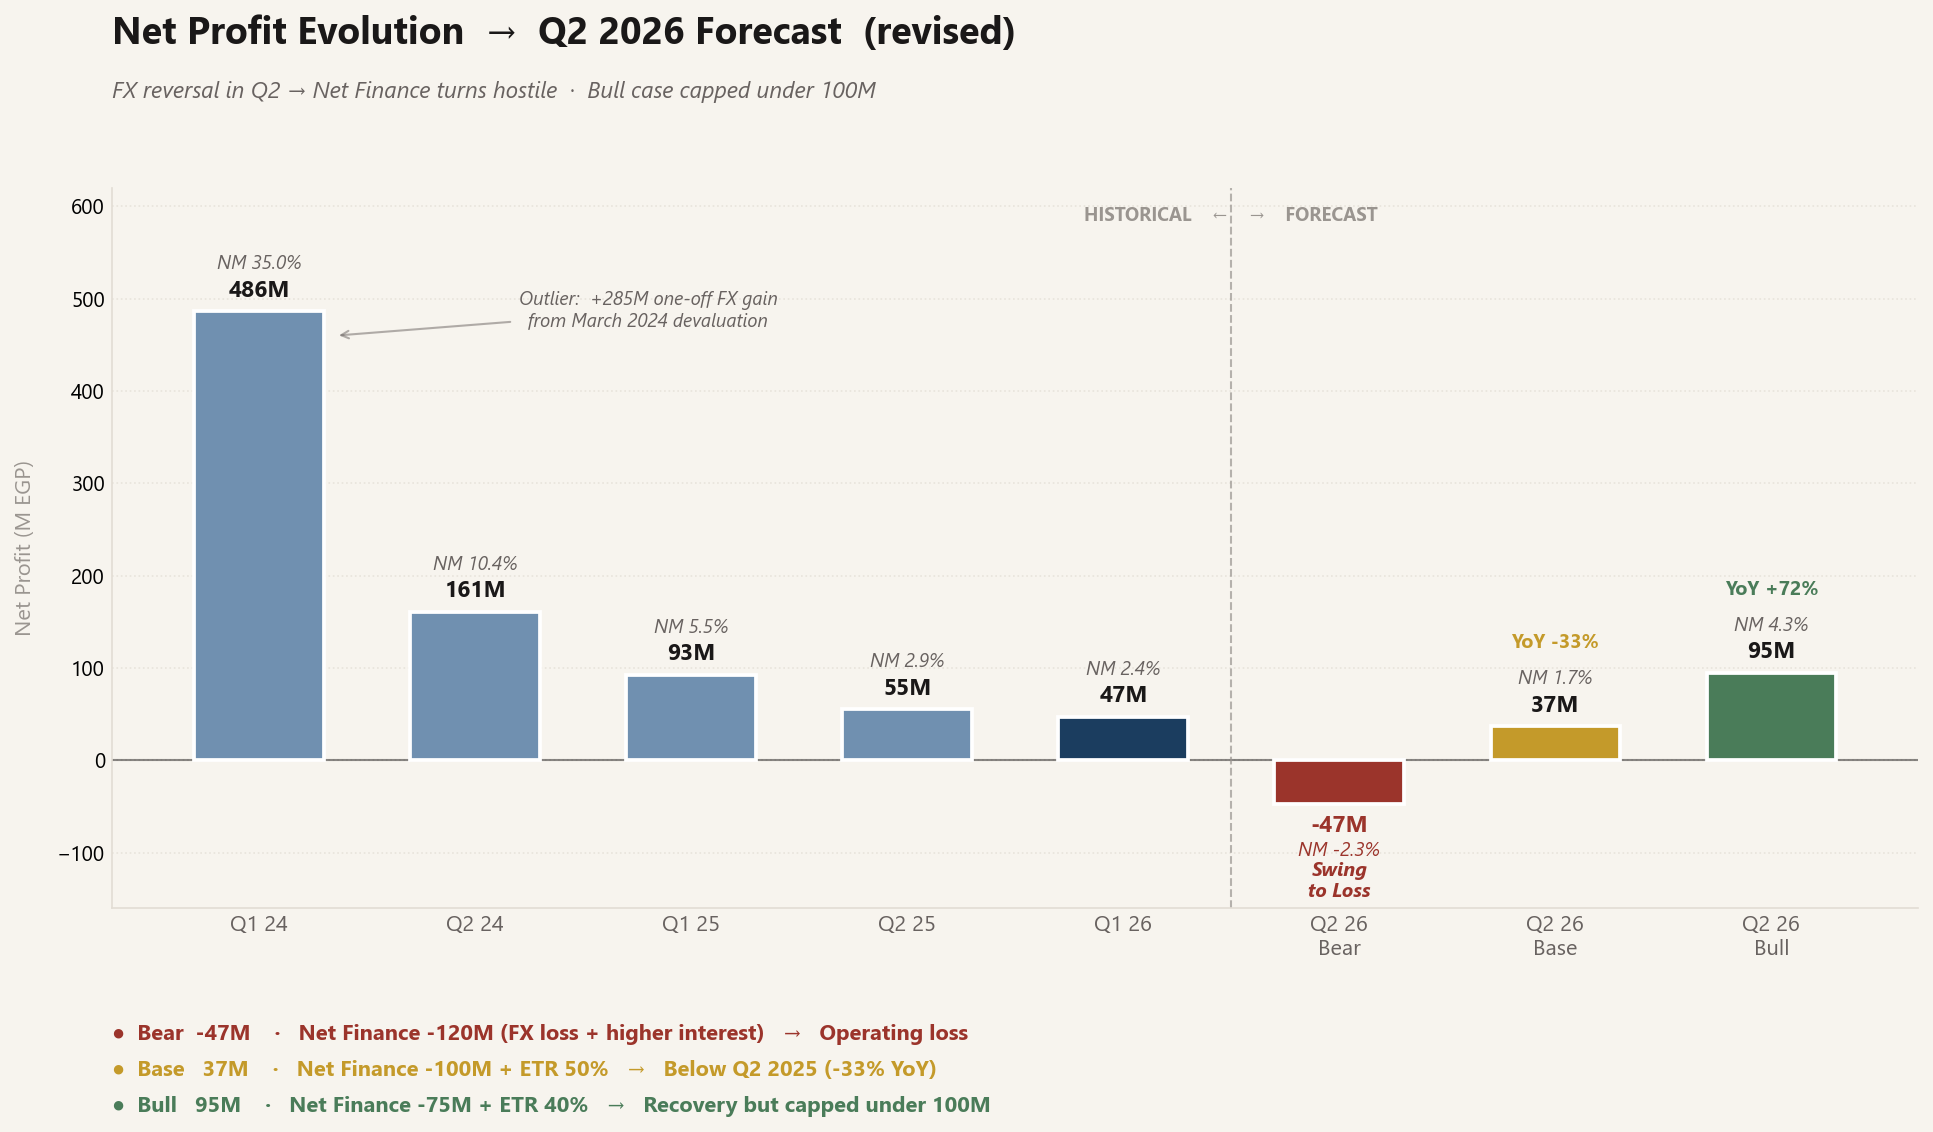

In [27]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F7F4EE'
HIST   = '#7090B0'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#E2DDD4'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8), facecolor=BG)
ax = fig.add_axes([0.08, 0.20, 0.86, 0.60])
ax.set_facecolor(BG)

labels = ['Q1 24', 'Q2 24', 'Q1 25', 'Q2 25', 'Q1 26',
          'Q2 26\nBear', 'Q2 26\nBase', 'Q2 26\nBull']
np_vals = [486.4, 161.0, 92.9, 55.2, 47.4, -47.0, 37.0, 95.0]
margins = [35.0, 10.4, 5.5, 2.9, 2.4, -2.3, 1.7, 4.3]
colors = [HIST, HIST, HIST, HIST, ANCHOR, BEAR, BASE, BULL]

x = np.arange(len(labels))
bars = ax.bar(x, np_vals, color=colors, width=0.6,
              edgecolor='white', linewidth=1.8, zorder=3)

# Value labels (positive: above bar; negative: below bar)
for bar, v in zip(bars, np_vals):
    if v >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, v + 10,
                f'{v:.0f}M', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=INK, zorder=4)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, v - 12,
                f'{v:.0f}M', ha='center', va='top',
                fontsize=11, fontweight='bold', color=BEAR, zorder=4)

# Margin labels
for bar, m, v in zip(bars, margins, np_vals):
    if v >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                f'NM {m:.1f}%', ha='center', va='bottom',
                fontsize=9, color=SOFT, style='italic', zorder=4)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, v - 42,
                f'NM {m:.1f}%', ha='center', va='top',
                fontsize=9, color=BEAR, style='italic', zorder=4)

# Q1 2024 outlier annotation
ax.annotate('Outlier:  +285M one-off FX gain\nfrom March 2024 devaluation',
            xy=(0.35, 460), xytext=(1.8, 470),
            fontsize=9, color=SOFT, style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color=SOFT, lw=1, alpha=0.5))

# YoY annotations for Base/Bull
q2_2025 = np_vals[3]
for idx, color in zip([6, 7], [BASE, BULL]):
    yoy = (np_vals[idx] / q2_2025 - 1) * 100
    sign = '+' if yoy >= 0 else ''
    ax.text(idx, np_vals[idx] + 80, f'YoY {sign}{yoy:.0f}%',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold',
            color=color)

# Bear: swing-to-loss annotation
ax.text(5, -110, 'Swing\nto Loss',
        ha='center', va='top', fontsize=9.5, fontweight='bold',
        color=BEAR, style='italic')

# Zero line (emphasis since we have negative)
ax.axhline(0, color=INK, lw=1, alpha=0.5, zorder=2)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=SOFT)
ax.set_ylim(-160, 620)
ax.set_ylabel('Net Profit (M EGP)', color=MUTED, fontsize=10.5, labelpad=10)
ax.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(RULE)
ax.spines['bottom'].set_color(RULE)
ax.tick_params(length=0)

# Divider
ax.axvline(4.5, color=MUTED, lw=1, linestyle='--', alpha=0.7)
ax.text(4.5, 590, 'HISTORICAL    ←    →    FORECAST',
        ha='center', va='center', fontsize=9,
        color=MUTED, fontweight='bold')

# Title
fig.text(0.08, 0.92, 'Net Profit Evolution  →  Q2 2026 Forecast  (revised)',
         fontsize=18, fontweight='bold', color=INK)
fig.text(0.08, 0.875,
         'FX reversal in Q2 → Net Finance turns hostile  ·  Bull case capped under 100M',
         fontsize=11, color=SOFT, style='italic')

# Rationale (bottom)
fig.text(0.08, 0.09,
         '●  Bear  -47M    ·   Net Finance -120M (FX loss + higher interest)   →   Operating loss',
         fontsize=10.5, color=BEAR, fontweight='bold')
fig.text(0.08, 0.06,
         '●  Base   37M    ·   Net Finance -100M + ETR 50%   →   Below Q2 2025 (-33% YoY)',
         fontsize=10.5, color=BASE, fontweight='bold')
fig.text(0.08, 0.03,
         '●  Bull   95M    ·   Net Finance -75M + ETR 40%   →   Recovery but capped under 100M',
         fontsize=10.5, color=BULL, fontweight='bold')

plt.savefig('lecico_np_forecast_v2.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## ملخص السيناريوهات الثلاثة

يجمع الجدول التالي كامل التحليل في صورة واحدة — من الإيرادات إلى صافي الربح — لكل سيناريو:

### الجدول الشامل

| البند | Q2 2025 (actual) | Q1 2026 (actual) | Q2 2026 Bear | Q2 2026 Base | Q2 2026 Bull |
|---|---|---|---|---|---|
| **Revenue** | 1,878 | 1,957 | 2,065 | 2,173 | 2,215 |
| **Gross Profit** | 449 | 395 | 372 | 456 | 510 |
| **GM%** | 23.9% | 20.2% | 18.0% | 21.0% | 23.0% |
| **EBIT** | 173 | 149 | 83 | 174 | 233 |
| **EBIT Margin** | 9.2% | 7.6% | 4.0% | 8.0% | 10.5% |
| **Net Profit** | 55 | 47 | **(47)** | **37** | **95** |
| **Net Margin** | 2.9% | 2.4% | -2.3% | 1.7% | 4.3% |

### الخلاصة الجوهرية

يتراوح صافي الربح بين:
- **Bear:** خسارة 47M
- **Bull:** ربح 95M
- **الفرق:** 142M EGP بين السيناريوهين

يُبرز هذا التباين الحاد **الـ operating + financial leverage** الفعلي للشركة. تغيّرات صغيرة في الافتراضات (margins, FX, tax) تُحدث آثاراً ضخمة في صافي الربح.

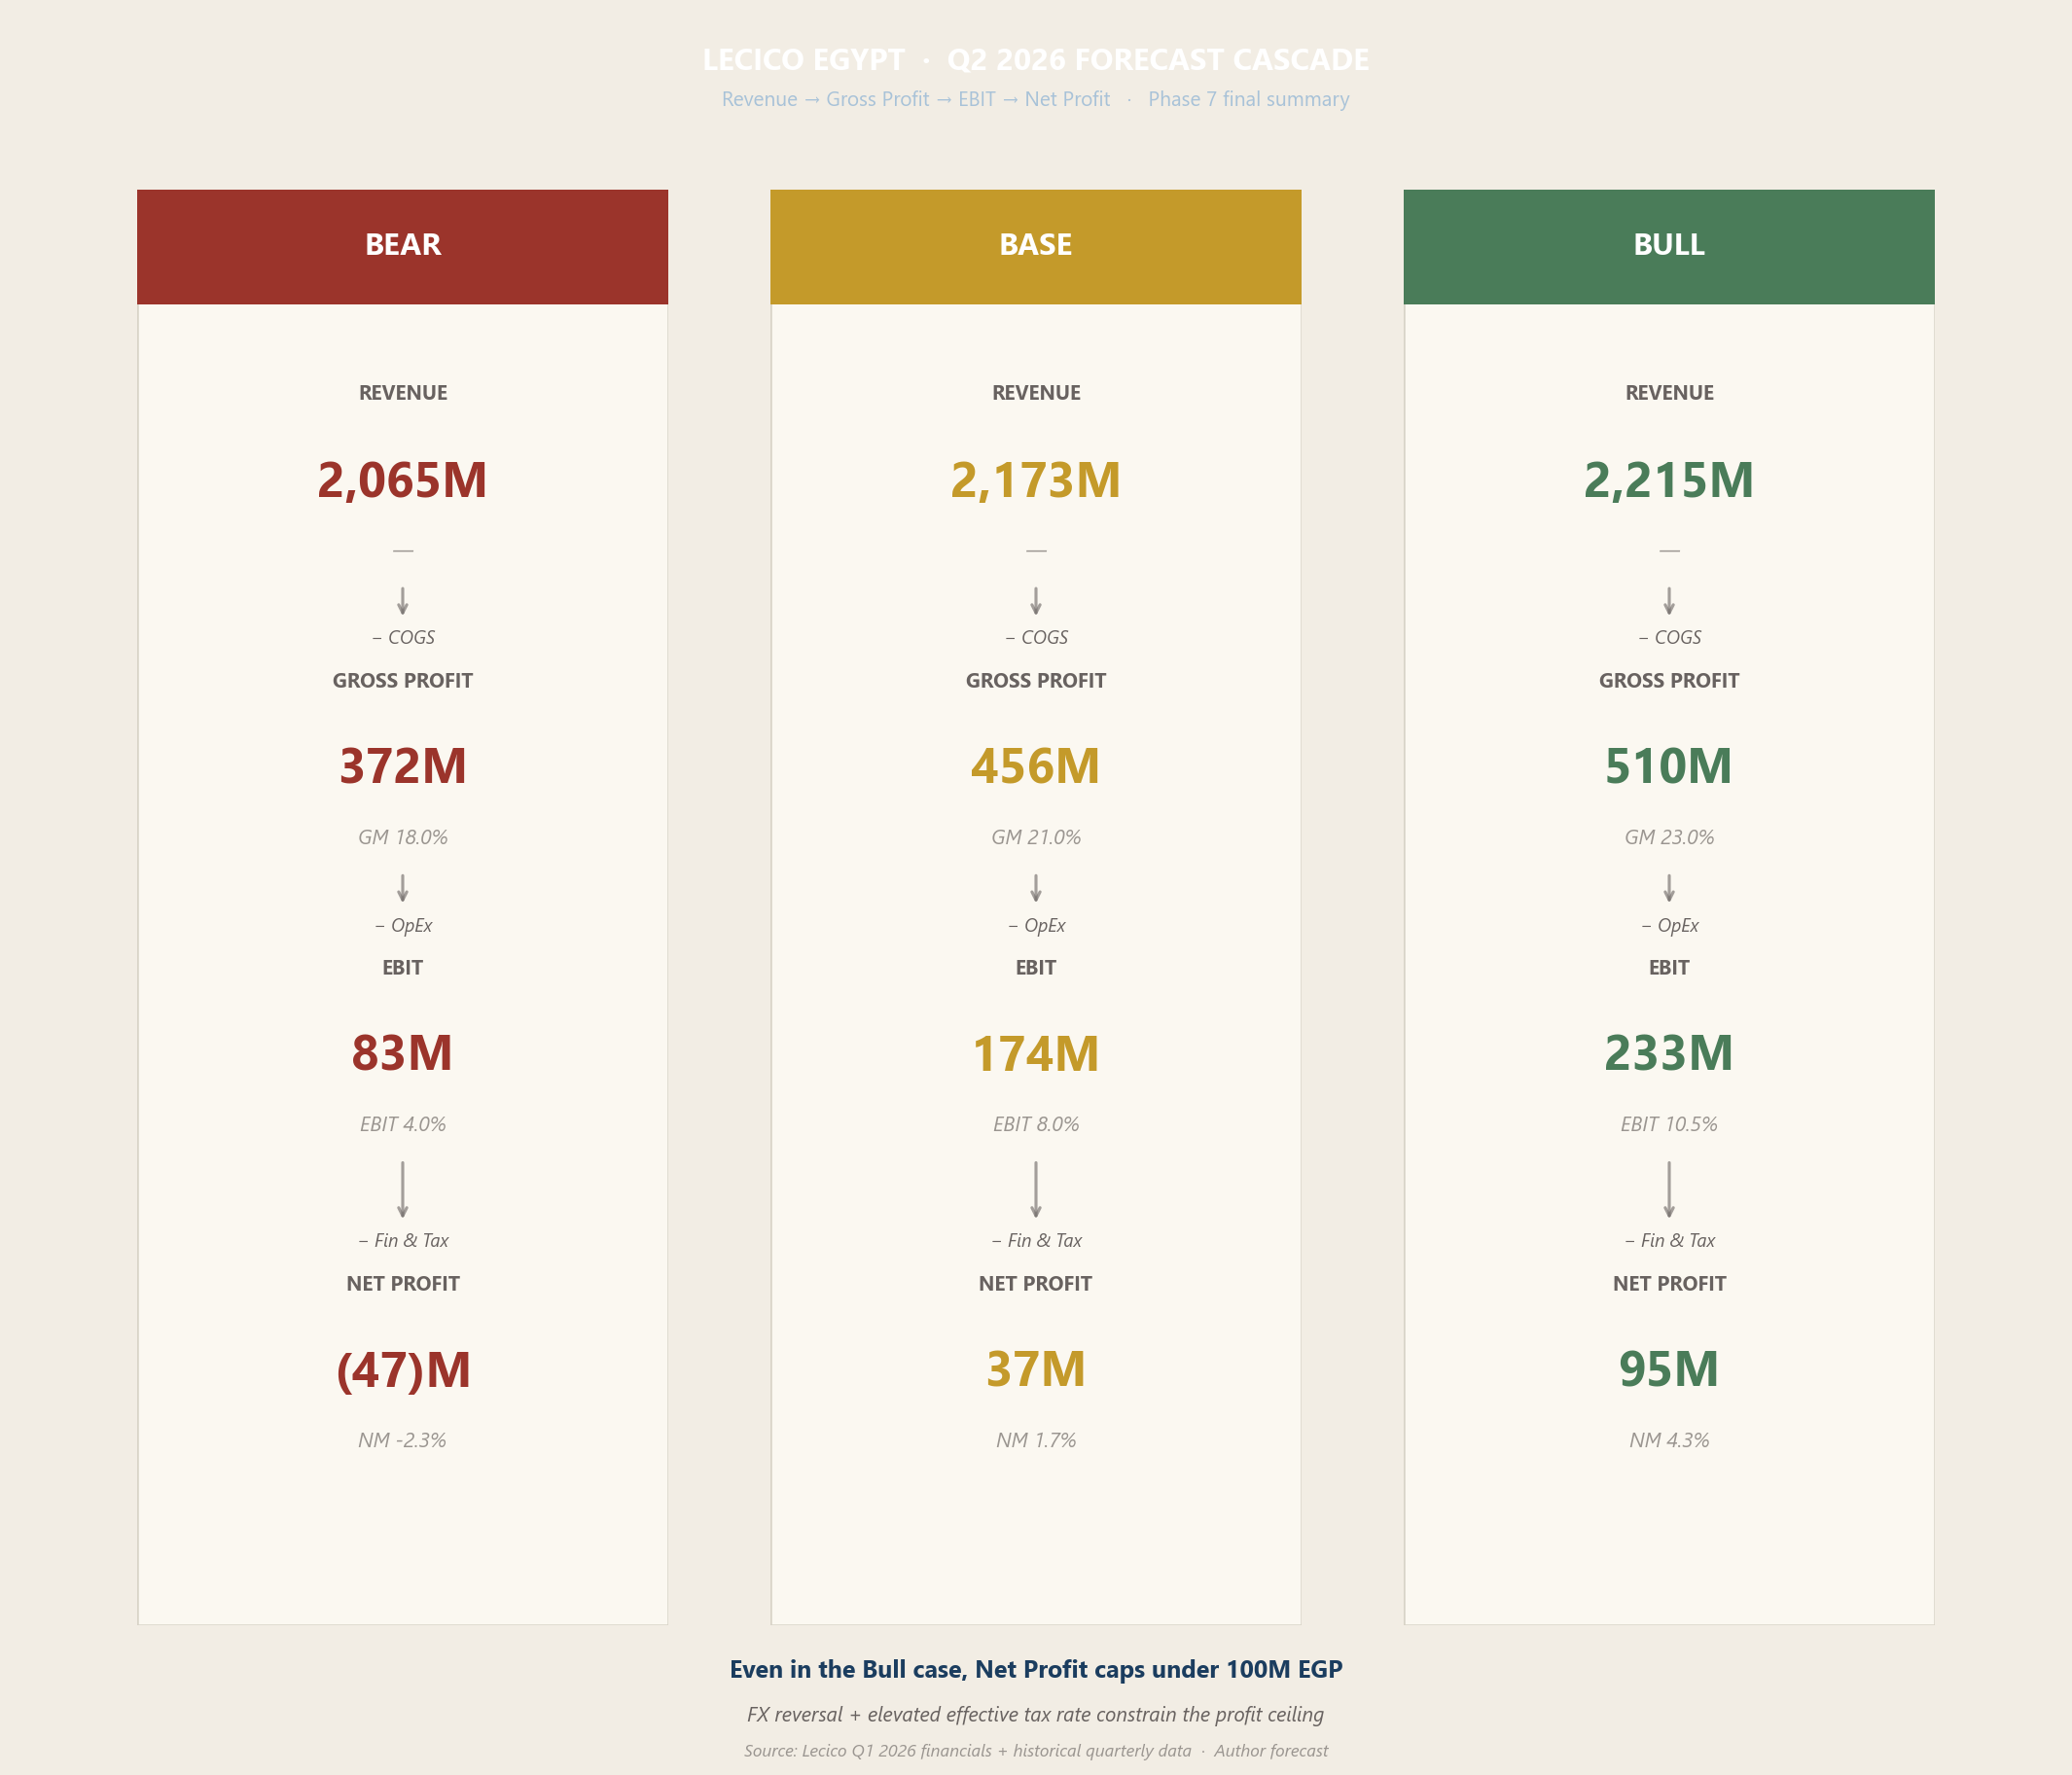

In [28]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK    = '#1A1818'
SOFT   = '#686260'
MUTED  = '#9A9590'
BG     = '#F2EDE4'
CARD   = '#FBF8F1'
ANCHOR = '#1B3D5F'
BEAR   = '#9B342B'
BASE   = '#C49A2A'
BULL   = '#4A7C59'
RULE   = '#D8D3C7'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 12), facecolor=BG)

# Header
ax_hdr = fig.add_axes([0, 0.94, 1, 0.06])
ax_hdr.set_facecolor(ANCHOR); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.55, 'LECICO EGYPT  ·  Q2 2026 FORECAST CASCADE',
            ha='center', va='center', fontsize=15, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.18,
            'Revenue → Gross Profit → EBIT → Net Profit   ·   Phase 7 final summary',
            ha='center', va='center', fontsize=10, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# Data per scenario
data = {
    'Bear': {'color': BEAR, 'values': [2065, 372, 83, -47],
             'margins': ['—', 'GM 18.0%', 'EBIT 4.0%', 'NM -2.3%']},
    'Base': {'color': BASE, 'values': [2173, 456, 174, 37],
             'margins': ['—', 'GM 21.0%', 'EBIT 8.0%', 'NM 1.7%']},
    'Bull': {'color': BULL, 'values': [2215, 510, 233, 95],
             'margins': ['—', 'GM 23.0%', 'EBIT 10.5%', 'NM 4.3%']},
}

metrics = ['Revenue', 'Gross Profit', 'EBIT', 'Net Profit']
deductions = ['', '− COGS', '− OpEx', '− Fin & Tax']

# Three columns
col_x_positions = [0.06, 0.37, 0.68]
col_width = 0.26

for col_idx, (sc_name, sc_data) in enumerate(data.items()):
    ax = fig.add_axes([col_x_positions[col_idx], 0.08, col_width, 0.82])
    ax.set_facecolor(CARD)
    ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # Card border
    ax.add_patch(patches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        facecolor=CARD, edgecolor=RULE, linewidth=1.2, zorder=1))

    # Header strip
    ax.add_patch(patches.Rectangle(
        (0, 0.92), 1, 0.08, transform=ax.transAxes,
        facecolor=sc_data['color'], edgecolor='none', zorder=2))
    ax.text(0.5, 0.96, sc_name.upper(),
            ha='center', va='center', fontsize=15, color='white',
            fontweight='bold', transform=ax.transAxes, zorder=3)

    # Cascade levels
    y_positions = [0.80, 0.60, 0.40, 0.18]

    for i, metric in enumerate(metrics):
        y = y_positions[i]
        value = sc_data['values'][i]
        margin = sc_data['margins'][i]

        # Deduction tag
        if deductions[i]:
            ax.text(0.5, y + 0.08, deductions[i],
                    ha='center', va='bottom', fontsize=9,
                    color=SOFT, style='italic',
                    transform=ax.transAxes)

        # Metric label
        ax.text(0.5, y + 0.05, metric.upper(),
                ha='center', va='bottom', fontsize=10, color=SOFT,
                fontweight='bold', transform=ax.transAxes)

        # Value (big hero number)
        if value >= 0:
            value_color = sc_data['color']
            text_str = f'{value:,.0f}M'
        else:
            value_color = BEAR
            text_str = f'({abs(value):,.0f})M'

        ax.text(0.5, y - 0.005, text_str,
                ha='center', va='center', fontsize=24,
                color=value_color, fontweight='bold',
                transform=ax.transAxes)

        # Margin subtitle
        ax.text(0.5, y - 0.045, margin,
                ha='center', va='top', fontsize=10,
                color=MUTED, style='italic',
                transform=ax.transAxes)

        # Connecting arrow to next level
        if i < len(metrics) - 1:
            arrow_y_start = y - 0.075
            arrow_y_end = y_positions[i + 1] + 0.10
            ax.annotate('',
                        xy=(0.5, arrow_y_end),
                        xytext=(0.5, arrow_y_start),
                        xycoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color=SOFT,
                                        lw=1.5, alpha=0.6))

# ── FOOTER ─────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.05,
         'Even in the Bull case, Net Profit caps under 100M EGP',
         ha='center', fontsize=12, color=ANCHOR, fontweight='bold')
fig.text(0.5, 0.025,
         'FX reversal + elevated effective tax rate constrain the profit ceiling',
         ha='center', fontsize=10, color=SOFT, style='italic')
fig.text(0.5, 0.005,
         'Source: Lecico Q1 2026 financials + historical quarterly data  ·  Author forecast',
         ha='center', fontsize=8.5, color=MUTED, style='italic')

plt.savefig('lecico_cascade_final.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## التقييم: P/E تحت السيناريوهات الثلاثة

تُمثّل النسبة السعرية إلى الربحية (P/E) المؤشر الجوهري لقياس مدى رخص السهم أو غلائه. تُحسب كالتالي:

```
P/E = Share Price ÷ Earnings Per Share (EPS)
```

يُمكن تقريب الأرباح الكاملة لعام 2026 من توقعات Q1 وQ2، للحصول على صورة عن الـ P/E المُحتمل في كل سيناريو.

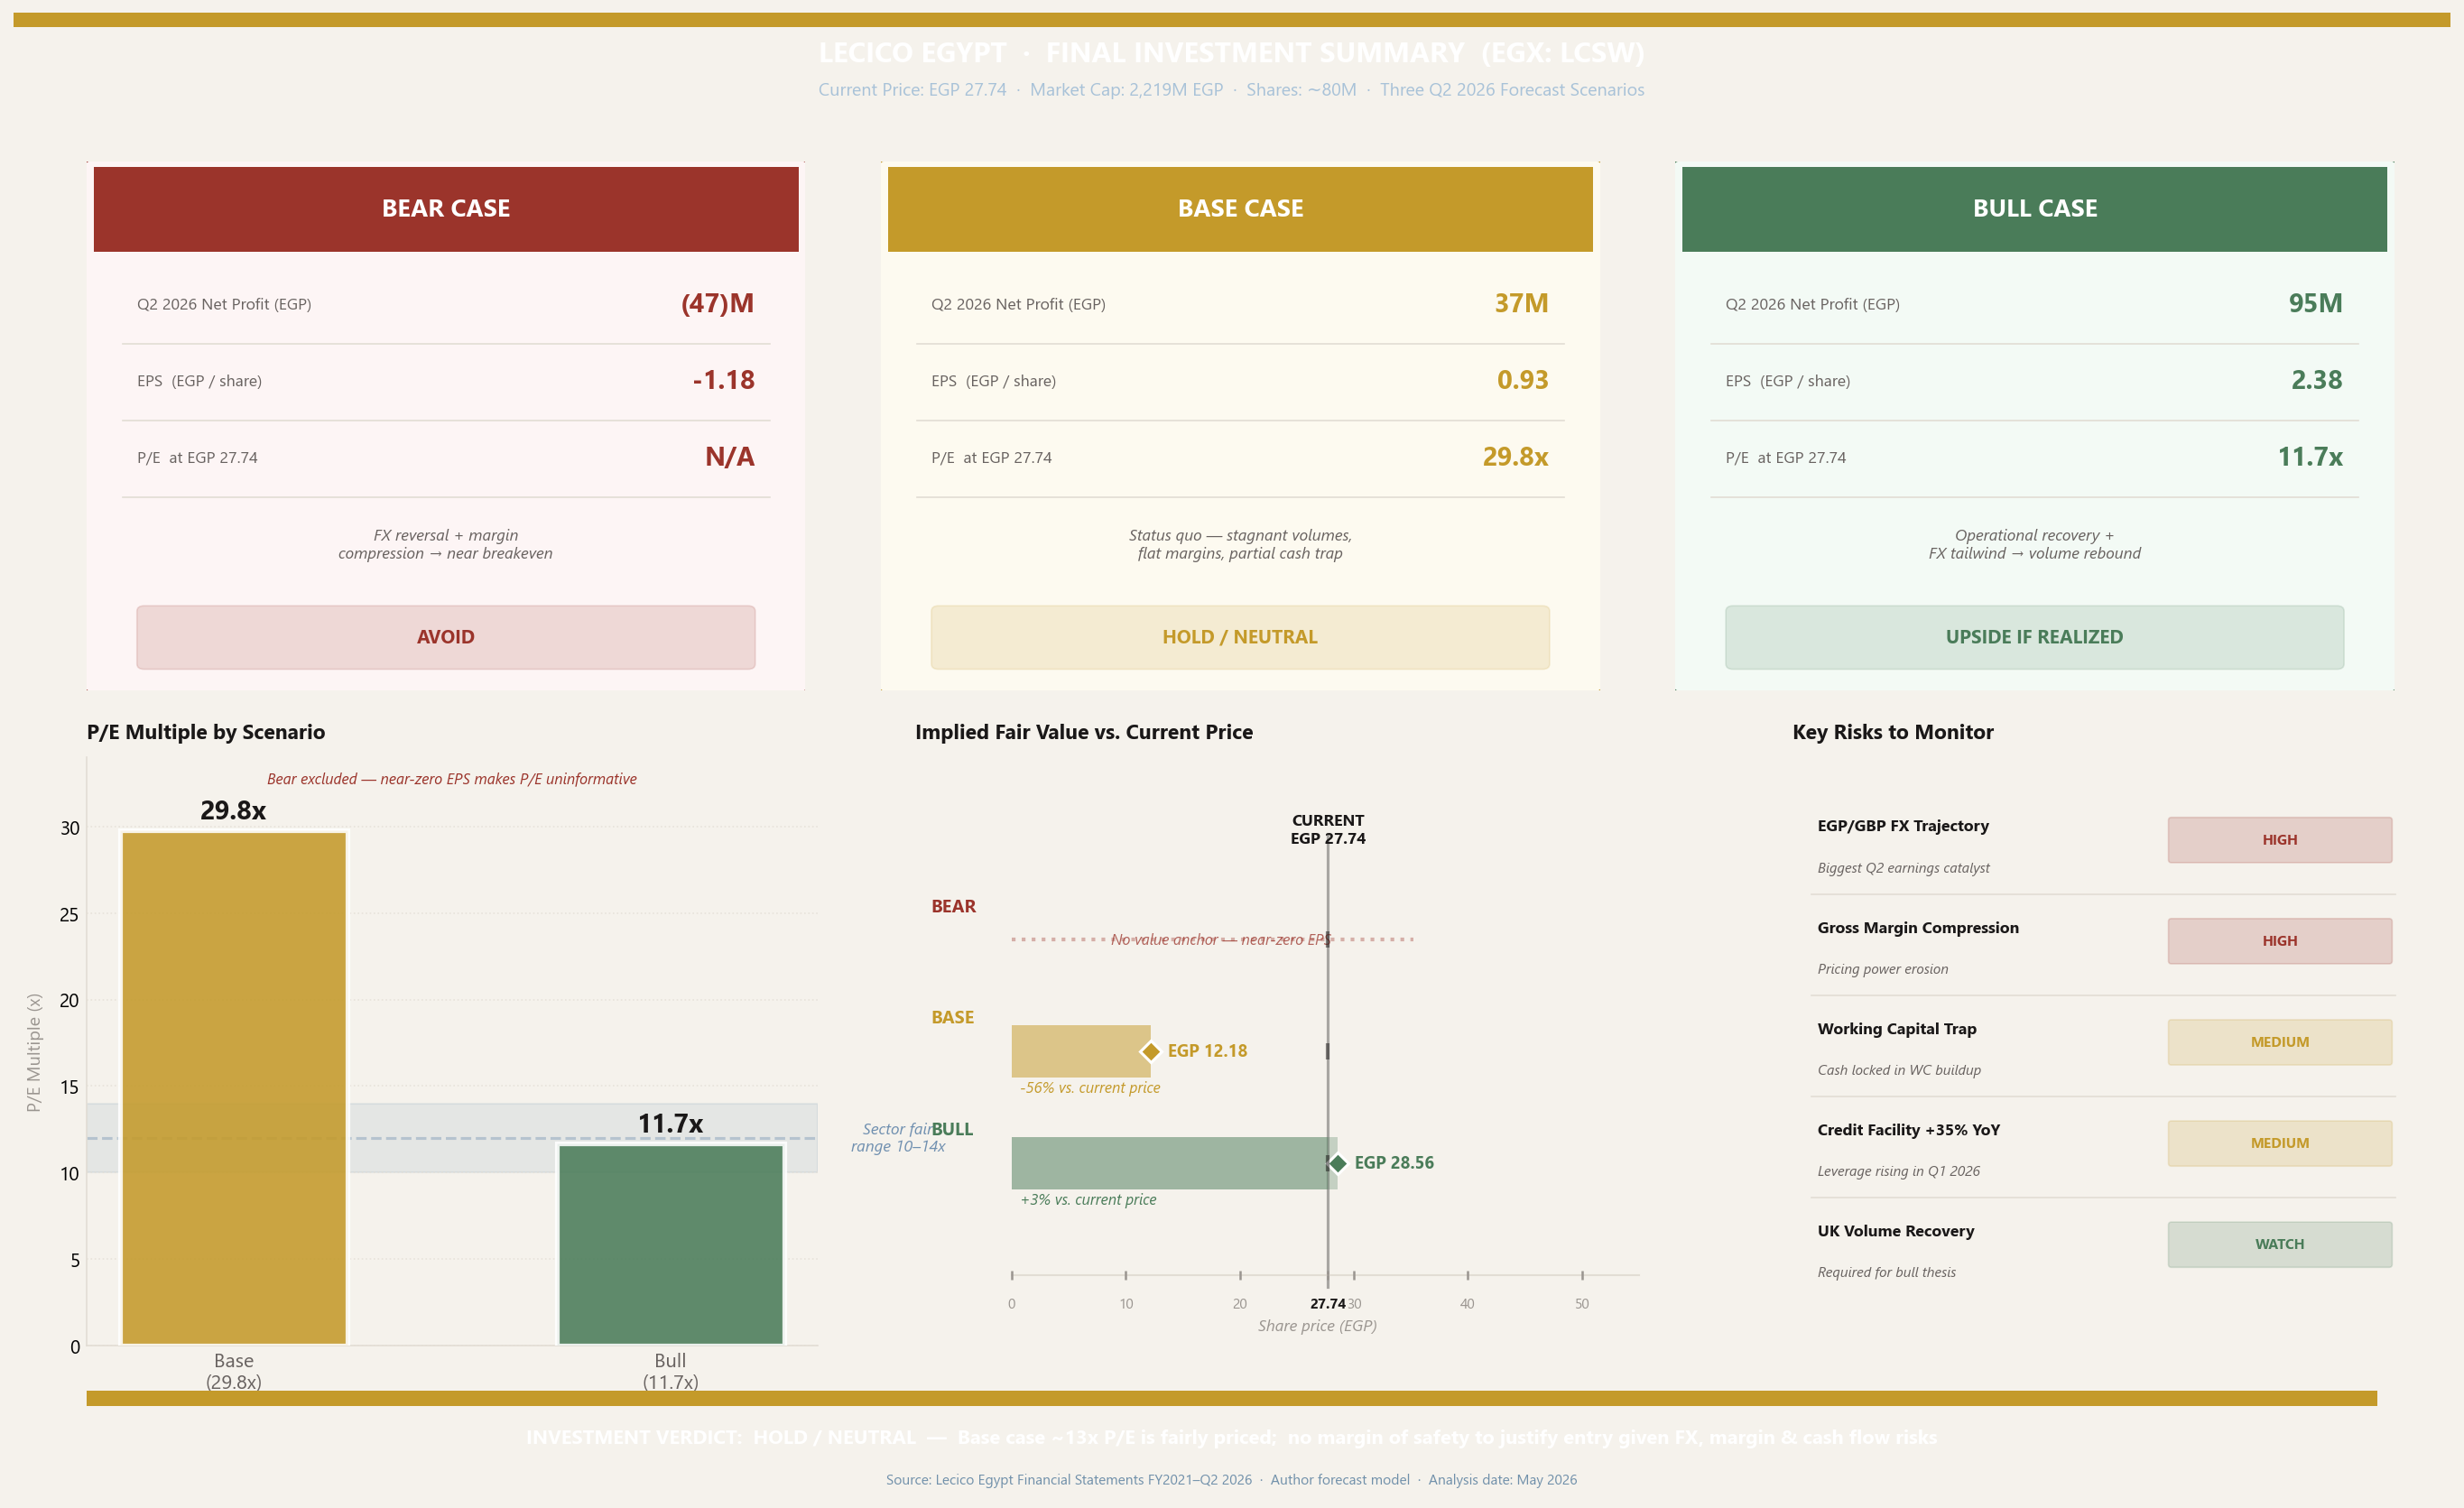

In [29]:
# ── PALETTE ───────────────────────────────────────────────────────────────────
INK   = '#1A1818'
SOFT  = '#686260'
MUTED = '#9A9590'
BG    = '#F5F2EC'
CARD  = '#FDFCF8'
NAVY  = '#1B3D5F'
NAVY2 = '#112740'
GOLD  = '#C49A2A'
SKY   = '#7090B0'
RULE  = '#E2DDD4'
BEAR  = '#9B342B'
BASE  = '#C49A2A'
BULL  = '#4A7C59'

plt.rcParams.update({'font.family': ['Segoe UI', 'Arial', 'sans-serif']})

# ── DATA ──────────────────────────────────────────────────────────────────────
PRICE  = 27.74
MKTCAP = 2219
SHARES = round(MKTCAP / PRICE)   # ≈ 80M

# Q2 2026 net profits from forecast cascade (annualised ×2 for EPS / P/E)
#   Bear:  –47M  → ann. –94M  → EPS –1.18
#   Base:   37M  → ann.  74M  → EPS  0.93  → P/E 29.8x → target 12.18
#   Bull:   95M  → ann. 190M  → EPS  2.38  → P/E 11.7x → target 28.56

scenarios = [
    {
        'name': 'BEAR', 'label': 'Bear Case',
        'eps': -1.18, 'pe': None, 'fy_str': '(47)M',
        'color': BEAR, 'bg': '#FDF5F5',
        'verdict': 'AVOID',
        'target': None,
        'desc': 'FX reversal + margin\ncompression → near breakeven',
    },
    {
        'name': 'BASE', 'label': 'Base Case',
        'eps': 0.93, 'pe': 29.8, 'fy_str': '37M',
        'color': BASE, 'bg': '#FDFAF0',
        'verdict': 'HOLD / NEUTRAL',
        'target': 12.18,
        'desc': 'Status quo — stagnant volumes,\nflat margins, partial cash trap',
    },
    {
        'name': 'BULL', 'label': 'Bull Case',
        'eps': 2.38, 'pe': 11.7, 'fy_str': '95M',
        'color': BULL, 'bg': '#F3FAF5',
        'verdict': 'UPSIDE IF REALIZED',
        'target': 28.56,
        'desc': 'Operational recovery +\nFX tailwind → volume rebound',
    },
]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11), facecolor=BG)

# ══ HEADER ════════════════════════════════════════════════════════════════════
ax_hdr = fig.add_axes([0, 0.935, 1, 0.065])
ax_hdr.set_facecolor(NAVY2)
ax_hdr.axis('off')
ax_hdr.add_patch(patches.Rectangle(
    (0, 0.85), 1, 0.15, facecolor=GOLD,
    transform=ax_hdr.transAxes, edgecolor='none'))
ax_hdr.text(0.5, 0.57,
            'LECICO EGYPT  ·  FINAL INVESTMENT SUMMARY  (EGX: LCSW)',
            ha='center', va='center', fontsize=15, color='white',
            fontweight='bold', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.20,
            f'Current Price: EGP {PRICE}  ·  Market Cap: {MKTCAP:,}M EGP'
            f'  ·  Shares: ∼{SHARES}M  ·  Three Q2 2026 Forecast Scenarios',
            ha='center', va='center', fontsize=9.5, color='#A8C2D8',
            transform=ax_hdr.transAxes)

# ══ TOP ROW: THREE SCENARIO CARDS ═════════════════════════════════════════════
card_w, card_h, card_y = 0.295, 0.355, 0.545
card_xs = [0.03, 0.356, 0.682]

for sc, cx in zip(scenarios, card_xs):
    ax_c = fig.add_axes([cx, card_y, card_w, card_h])
    ax_c.set_facecolor(sc['bg'])
    ax_c.axis('off')
    ax_c.set_xlim(0, 1)
    ax_c.set_ylim(0, 1)

    # Card border
    ax_c.add_patch(patches.FancyBboxPatch(
        (0.01, 0.01), 0.98, 0.98, boxstyle='round,pad=0.015',
        facecolor=sc['bg'], edgecolor=sc['color'], linewidth=1.8))

    # Colored header banner
    ax_c.add_patch(patches.Rectangle(
        (0.01, 0.83), 0.98, 0.16, facecolor=sc['color'], edgecolor='none'))
    ax_c.text(0.5, 0.91, sc['label'].upper(),
              ha='center', va='center', fontsize=13,
              fontweight='bold', color='white')

    # Three metric rows
    metric_rows = [
        ('Q2 2026 Net Profit (EGP)', sc['fy_str']),
        ('EPS  (EGP / share)',        f"{sc['eps']:.2f}"),
        ('P/E  at EGP 27.74',         f"{sc['pe']:.1f}x" if sc['pe'] else 'N/A'),
    ]
    y_tops = [0.730, 0.585, 0.440]
    for (lbl, val), yt in zip(metric_rows, y_tops):
        ax_c.text(0.07, yt, lbl, ha='left', va='center',
                  fontsize=8.5, color=SOFT)
        ax_c.text(0.93, yt, val, ha='right', va='center',
                  fontsize=14, fontweight='bold', color=sc['color'])
        if yt > 0.42:
            ax_c.plot([0.05, 0.95], [yt - 0.075, yt - 0.075],
                      color=RULE, lw=0.8)

    # Scenario description
    ax_c.text(0.5, 0.275, sc['desc'],
              ha='center', va='center', fontsize=8.5, color=SOFT,
              style='italic', multialignment='center')

    # Verdict badge
    ax_c.add_patch(patches.FancyBboxPatch(
        (0.08, 0.05), 0.84, 0.10, boxstyle='round,pad=0.01',
        facecolor=sc['color'], alpha=0.15,
        edgecolor=sc['color'], linewidth=0.8))
    ax_c.text(0.5, 0.10, sc['verdict'],
              ha='center', va='center', fontsize=10,
              fontweight='bold', color=sc['color'])

# ══ BOTTOM LEFT: P/E CHART ════════════════════════════════════════════════════
ax_pe = fig.add_axes([0.03, 0.105, 0.30, 0.395])
ax_pe.set_facecolor(BG)

pe_names  = ['Base\n(29.8x)', 'Bull\n(11.7x)']
pe_vals   = [29.8, 11.7]
pe_colors = [BASE, BULL]
xb        = np.arange(len(pe_names))

bars = ax_pe.bar(xb, pe_vals, color=pe_colors, width=0.52,
                 edgecolor='white', linewidth=2.5, zorder=3, alpha=0.88)
for bar, v in zip(bars, pe_vals):
    ax_pe.text(bar.get_x() + bar.get_width() / 2, v + 0.28,
               f'{v:.1f}x', ha='center', va='bottom',
               fontsize=14, fontweight='bold', color=INK, zorder=4)

ax_pe.axhspan(10, 14, color=SKY, alpha=0.12, zorder=0)
ax_pe.axhline(12, color=SKY, lw=1.5, ls='--', alpha=0.40, zorder=1)
ax_pe.text(1.52, 12.0, 'Sector fair\nrange 10–14x',
           ha='center', va='center', fontsize=8.5, color=SKY, style='italic')

ax_pe.set_xticks(xb)
ax_pe.set_xticklabels(pe_names, fontsize=10.5, color=SOFT)
ax_pe.set_ylim(0, 34)
ax_pe.set_ylabel('P/E Multiple (x)', color=MUTED, fontsize=9.5, labelpad=8)
ax_pe.grid(axis='y', linestyle=':', color=RULE, alpha=0.7, zorder=0)
ax_pe.set_axisbelow(True)
for sp in ['top', 'right']:
    ax_pe.spines[sp].set_visible(False)
ax_pe.spines['left'].set_color(RULE)
ax_pe.spines['bottom'].set_color(RULE)
ax_pe.tick_params(length=0)
ax_pe.set_title('P/E Multiple by Scenario',
                fontsize=11, fontweight='bold', color=INK, loc='left', pad=10)
ax_pe.text(0.5, 32.5,
           'Bear excluded — near-zero EPS makes P/E uninformative',
           ha='center', fontsize=8, color=BEAR, style='italic')

# ══ BOTTOM CENTER: IMPLIED PRICE TARGETS ══════════════════════════════════════
ax_pt = fig.add_axes([0.37, 0.105, 0.33, 0.395])
ax_pt.set_facecolor(BG)
ax_pt.axis('off')
ax_pt.set_xlim(0, 1)
ax_pt.set_ylim(0, 1)
ax_pt.set_title('Implied Fair Value vs. Current Price',
                fontsize=11, fontweight='bold', color=INK, loc='left', pad=10)

SCALE_MAX = 55.0
ML, MR = 0.12, 0.90

def to_x(val):
    return ML + (val / SCALE_MAX) * (MR - ML)

cx = to_x(PRICE)
ax_pt.axvline(cx, color=INK, lw=1.5, ls='-', alpha=0.35,
              ymin=0.10, ymax=0.87)
ax_pt.text(cx, 0.905, f'CURRENT\nEGP {PRICE}',
           ha='center', va='top', fontsize=8.5, color=INK, fontweight='bold')

pt_rows = [
    {'sc': scenarios[0], 'y': 0.69},
    {'sc': scenarios[1], 'y': 0.50},
    {'sc': scenarios[2], 'y': 0.31},
]
BAR_H = 0.09

for row in pt_rows:
    sc = row['sc']
    y  = row['y']
    c  = sc['color']

    ax_pt.text(0.02, y + 0.056, sc['name'],
               ha='left', va='center', fontsize=9.5,
               fontweight='bold', color=c)

    if sc['target'] is None:
        ax_pt.plot([ML, 0.62], [y, y],
                   color=c, lw=2, ls=':', alpha=0.35)
        ax_pt.text(0.38, y, 'No value anchor — near-zero EPS',
                   ha='center', va='center', fontsize=8,
                   color=c, style='italic', alpha=0.75)
    else:
        tx = to_x(sc['target'])

        ax_pt.barh(y, tx - ML, height=BAR_H, left=ML,
                   color=c, alpha=0.10, zorder=2)

        fill_to = min(tx, cx)
        ax_pt.barh(y, fill_to - ML, height=BAR_H, left=ML,
                   color=c, alpha=0.45, zorder=3)

        if tx > cx:
            ax_pt.barh(y, tx - cx, height=BAR_H, left=cx,
                       color=c, alpha=0.20, zorder=2)

        ax_pt.plot(tx, y, 'D', color=c, markersize=8, zorder=6,
                   markeredgecolor='white', markeredgewidth=1.5)
        ax_pt.text(tx + 0.022, y, f"EGP {sc['target']:.2f}",
                   ha='left', va='center', fontsize=9,
                   fontweight='bold', color=c)

        upside = (sc['target'] - PRICE) / PRICE * 100
        if abs(upside) < 1:
            u_lbl = '≈ At fair value'
        else:
            sign = '+' if upside >= 0 else ''
            u_lbl = f'{sign}{upside:.0f}% vs. current price'
        ax_pt.text(0.13, y - 0.063, u_lbl,
                   ha='left', va='center', fontsize=8,
                   color=c, style='italic')

    ax_pt.plot(cx, y, '|', color=INK, ms=9, mew=2, zorder=7, alpha=0.50)

# X-axis scale bar
y_ax = 0.12
ax_pt.axhline(y_ax, color=RULE, lw=1.0, xmin=ML, xmax=MR)
for v in [0, 10, 20, PRICE, 30, 40, 50]:
    vx = to_x(v)
    if ML <= vx <= MR:
        ax_pt.plot(vx, y_ax, '|', color=MUTED, ms=5, mew=1.2)
        if v == PRICE:
            ax_pt.text(vx, y_ax - 0.038, f'{PRICE}',
                       ha='center', va='top', fontsize=7.5,
                       color=INK, fontweight='bold')
        else:
            ax_pt.text(vx, y_ax - 0.038, str(int(v)),
                       ha='center', va='top', fontsize=7.5, color=MUTED)
ax_pt.text(0.5, 0.02, 'Share price (EGP)',
           ha='center', va='bottom', fontsize=8.5,
           color=MUTED, style='italic')

# ══ BOTTOM RIGHT: KEY RISKS ═══════════════════════════════════════════════════
ax_rk = fig.add_axes([0.73, 0.105, 0.255, 0.395])
ax_rk.set_facecolor(CARD)
ax_rk.axis('off')
ax_rk.set_xlim(0, 1)
ax_rk.set_ylim(0, 1)
ax_rk.set_title('Key Risks to Monitor',
                fontsize=11, fontweight='bold', color=INK, loc='left', pad=10)

risks = [
    ('EGP/GBP FX Trajectory',   'HIGH',   BEAR, 'Biggest Q2 earnings catalyst'),
    ('Gross Margin Compression', 'HIGH',   BEAR, 'Pricing power erosion'),
    ('Working Capital Trap',     'MEDIUM', BASE, 'Cash locked in WC buildup'),
    ('Credit Facility +35% YoY','MEDIUM', BASE, 'Leverage rising in Q1 2026'),
    ('UK Volume Recovery',       'WATCH',  BULL, 'Required for bull thesis'),
]

y0   = 0.895
step = 0.172

for j, (risk, level, col, note) in enumerate(risks):
    y  = y0 - j * step
    ax_rk.text(0.04, y, risk,
               ha='left', va='top', fontsize=8.5,
               fontweight='bold', color=INK)
    bx, bw, bh = 0.61, 0.35, 0.067
    by = y - bh - 0.002
    ax_rk.add_patch(patches.FancyBboxPatch(
        (bx, by), bw, bh, boxstyle='round,pad=0.005',
        facecolor=col, alpha=0.18, edgecolor=col, linewidth=0.8))
    ax_rk.text(bx + bw / 2, by + bh / 2, level,
               ha='center', va='center', fontsize=7.5,
               fontweight='bold', color=col)
    ax_rk.text(0.04, y - 0.073, note,
               ha='left', va='top', fontsize=7.5,
               color=SOFT, style='italic')
    if j < len(risks) - 1:
        ax_rk.plot([0.03, 0.97], [y - 0.128, y - 0.128],
                   color=RULE, lw=0.8)

# ══ VERDICT FOOTER ════════════════════════════════════════════════════════════
ax_v = fig.add_axes([0.03, 0.005, 0.94, 0.070])
ax_v.set_facecolor(NAVY2)
ax_v.axis('off')
ax_v.add_patch(patches.Rectangle(
    (0, 0.85), 1, 0.15, facecolor=GOLD,
    transform=ax_v.transAxes, edgecolor='none'))
ax_v.text(0.5, 0.54,
          'INVESTMENT VERDICT:  HOLD / NEUTRAL  —  Base case ~13x P/E is fairly priced;  '
          'no margin of safety to justify entry given FX, margin & cash flow risks',
          ha='center', va='center', fontsize=10.5, color='white',
          fontweight='bold', transform=ax_v.transAxes)
ax_v.text(0.5, 0.14,
          'Source: Lecico Egypt Financial Statements FY2021–Q2 2026  '
          '·  Author forecast model  ·  Analysis date: May 2026',
          ha='center', va='center', fontsize=7.5, color='#7090AA',
          transform=ax_v.transAxes)

plt.savefig('lecico_final_summary.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

---

## الخلاصة النهائية

### القصة الكاملة

> "تمتلك ليسيكو أصولاً حقيقية وفرنشايز قوياً في UK، إلا أن الـ thesis الاستثماري فيها معقد. النمو المُعلن بالجنيه يُخفي تدهوراً تشغيلياً حقيقياً (تراجع في الأحجام، ضغط على الهوامش، احتجاز للنقدية). تؤكد توقعات Q2 2026 أن صافي الربح يبقى تحت 100M حتى في أفضل سيناريو، بفعل انعكاس الـ FX gain وارتفاع معدل الضريبة الفعلي."

### الـ Investment Take

- **Bull case:** Operational recovery + استمرار ضعف الـ FX → Net Profit ~95M
- **Base case:** Status quo → Net Profit ~37M (تدهور طفيف)
- **Bear case:** انعكاس الـ FX + Margin Compression → خسارة

### الـ Key Risks للمراقبة

1. **حركة EGP/USD في Q2** — الـ catalyst الأكبر
2. **استمرار Gross Margin Compression** — مؤشر على الـ pricing power
3. **حجم الـ Working Capital Buildup** — اتساع الـ Cash Trap
4. **مستوى الدين والفوائد** — التسهيلات الائتمانية ارتفعت بنسبة +35% في Q1 2026

### Methodology Notes

تستند جميع الافتراضات في هذا التحليل إلى:
- Q1 2026 actuals (المرجع)
- Historical patterns (الـ Q1→Q2 seasonal trends)
- FX trajectory analysis
- مقارنة بفترات سابقة مشابهة

---

**Sources:** Lecico Egypt Financial Statements (FY 2021 – Q1 2026)